# Simulation

This notebook runs the NYP Women's Health Screening digital twin — from a full multi-decade population simulation through to individual patient journeys.

| Section | What you'll see |
|---|---|
| **Multi-Decade Longitudinal Simulation** | How the full patient population moves through the screening program over a generation |
| **Single Patient Trace** | One patient's complete screening journey from entry to end of life |
| **Longitudinal Visualizations** | Trends in screening volume, clinical rates, and revenue across a full lifetime |
| **1-Year Simulation** | A quick single-year snapshot of daily throughput and outcomes |
| **Step-by-Step Breakdown** | Technical detail on the daily simulation engine — for debugging and development |

---

## Clinical Pathways

The simulation models two cancer screening pathways. Each pathway has two layers:

- **USPSTF** — determines *who* gets screened and *how often*. **This is the primary focus of the model.**
- **ACR / ASCCP** — determines what happens *after* a result comes back. These downstream pathways are modeled but are secondary — the main question we are answering is uptake, not outcomes.

---

### Cervical Cancer Pathway

**Who gets screened (USPSTF)**

| Age | Test | Frequency | USPSTF Recommendation |
|---|---|---|---|
| 21–29 | Cytology (Pap smear) | Every 3 years | Grade A |
| 30–65 | Cytology every 3 years **or** hrHPV alone every 5 years | 3 or 5 years | Grade A |
| < 21 or > 65 | No routine screening | — | Grade D / C |

**What "cytology" and "hrHPV" mean:**
- **Cytology (Pap smear)** — cells from the cervix are examined under a microscope. Results: Normal, ASCUS, LSIL, ASC-H, or HSIL.
- **hrHPV alone** — a molecular test for high-risk strains of human papillomavirus. Results: HPV-Negative or HPV-Positive.

**After an abnormal result (ASCCP — secondary)**

An abnormal Pap or positive HPV leads to colposcopy (a closer look at the cervix). If abnormal tissue is found (CIN2/CIN3), a LEEP procedure removes it. These are tracked in the model but are not the primary metric.

---

### Lung Cancer Pathway

**Who gets screened (USPSTF)**

| Criteria | Requirement | USPSTF Recommendation |
|---|---|---|
| Age | 50–80 years | Grade B |
| Smoking history | ≥ 20 pack-years | Grade B |
| Smoking status | Currently smoking **or** quit within last 15 years | Grade B |

All three criteria must be met. A patient who smoked 30 pack-years but quit 20 years ago is **not** eligible under USPSTF.

**The test: Low-Dose CT (LDCT)**
An annual low-dose CT scan of the chest looks for lung nodules. It is a quick, non-invasive scan — no lab test, no procedure. The result is scored using **Lung-RADS** (1–4), but this scoring is secondary; what matters for USPSTF compliance is whether the eligible patient **received the scan**.

**After a suspicious result (ACR Lung-RADS — secondary)**
RADS 3 or 4 results trigger follow-up imaging or biopsy. Tracked in the model but secondary to uptake.

---

> **Key distinction**: RADS categories and CIN grades are *clinical classification systems* used by radiologists and pathologists after a test is done. They are **not** USPSTF guidelines — USPSTF only specifies who gets the test and how often.


In [1]:
%matplotlib inline

import sys, random, time
sys.path.insert(0, '../src')

import config as cfg
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

from patient import Patient
from population import sample_patient, draw_death_day
from screening import get_eligible_screenings, run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening, compute_rates, compute_revenue, print_revenue_summary
from runner import SimulationRunner
from db import SimulationDB

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


### How to Use This Notebook

Run each cell from top to bottom by pressing **Shift + Enter**. You do not need to understand the code — the charts and printed summaries are the outputs to focus on.

The cell immediately below loads the simulation engine and supporting libraries. Run it once at the start of each session before anything else.

---

## 70-Year Longitudinal Simulation

The full simulation models a stable population of patients cycling through NYP's screening program over a 70-year horizon. New patients enter continuously as others age out or die, keeping the active pool roughly constant — the way a real hospital system actually operates over decades.

**Primary question:** Of all patients in the system, how many receive their USPSTF-recommended screenings (Pap cytology, hrHPV, lung LDCT) — and at what rate?


In [2]:
import sys, time, pickle, os, importlib
from collections import defaultdict
sys.path.insert(0, '../src')

# ── Output directory for all visualizations ────────────────────────────────
VIZ_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'notebooks', 'Base Visualizations')
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Auto-indexing for visualization filenames ────────────────────────────────
# Each viz cell calls viz_path("name") which auto-increments the index.
# Reordering cells automatically reindexes the output files.
_viz_counter = 0
def viz_path(name):
    global _viz_counter
    _viz_counter += 1
    return os.path.join(VIZ_DIR, f"{_viz_counter:02d}_{name}.png")

# ── Warmup period filter ─────────────────────────────────────────────────────
# Years 0 through cfg.WARMUP_YEARS-1 are warmup. All analysis and
# visualizations start at year cfg.WARMUP_YEARS.
WARMUP_YR = cfg.WARMUP_YEARS

def post_warmup(years_arr, *data_arrs):
    """Filter parallel arrays to keep only years >= WARMUP_YR.
    Returns (filtered_years, filtered_data1, filtered_data2, ...).
    If years_arr is a numpy array, returns numpy arrays; otherwise lists."""
    import numpy as _np
    ya = _np.asarray(years_arr)
    mask = ya >= WARMUP_YR
    result = [ya[mask]]
    for d in data_arrs:
        da = _np.asarray(d)
        # Handle case where data is 1 shorter than years (annual diffs)
        if len(da) == len(ya) - 1:
            result.append(da[mask[1:]])
        elif len(da) == len(ya):
            result.append(da[mask])
        else:
            result.append(da)  # can't filter, return as-is
    return tuple(result) if len(result) > 1 else result[0]

def post_warmup_checkpoints(ckpts):
    """Filter year_checkpoints list to years >= WARMUP_YR."""
    return [cp for cp in ckpts if cp.get("year", 0) >= WARMUP_YR]



# Always reload src modules so changes to .py files are picked up
# without restarting the kernel.
import config as cfg;      importlib.reload(cfg)
import runner as _runner;  importlib.reload(_runner)
from runner import SimulationRunner

# ─────────────────────────────────────────────────────────────────────────────
# FORCE_RERUN: set to True to bypass the cache and run the full {cfg.SIM_YEARS}-year
# simulation from scratch (~1 min with SKIP_WEEKENDS=True).
# Set back to False after the run so the cache loads instantly next time.
# ─────────────────────────────────────────────────────────────────────────────
FORCE_RERUN = True   # ← change to True to run the full {cfg.SIM_YEARS}-year simulation

CACHE_FILE = "metrics_70yr_cache.pkl"

def _to_plain(obj):
    """
    Recursively convert defaultdicts → plain dicts so pickle can serialize
    them. Lambda default-factories (e.g. cervical_by_age_stratum) are not
    picklable; plain dicts are. Lists and scalars pass through unchanged.
    """
    if isinstance(obj, dict):           # covers defaultdict too
        return {k: _to_plain(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_plain(v) for v in obj]
    return obj

def _load_cache(path):
    """Load pickle cache. Returns the cache dict, or None if missing/corrupt."""
    if not os.path.exists(path):
        return None
    try:
        with open(path, "rb") as _f:
            cache = pickle.load(_f)
        if not isinstance(cache, dict) or "metrics" not in cache:
            raise ValueError("Cache missing 'metrics' key")
        return cache
    except Exception as e:
        print(f"[Cache] Could not load '{path}': {type(e).__name__}: {e}")
        print("[Cache] Deleting corrupt file and re-running simulation...")
        try:
            os.remove(path)
        except OSError:
            pass
        return None

_cache = None if FORCE_RERUN else _load_cache(CACHE_FILE)

if _cache is not None:
    # ── Load from cache (fast — no re-run needed) ─────────────────────────
    metrics_70yr = _cache["metrics"]
    print(f"Loaded cached {cfg.SIM_YEARS}-year metrics from {CACHE_FILE}.")
    print(f"  Cervical screens : {metrics_70yr['n_screened']['cervical']:,}")
    print(f"  Year checkpoints : {len(metrics_70yr['year_checkpoints'])}")
    print()
    # Re-create a summary-only runner for revenue / db_summary calls
    sim_70yr = SimulationRunner.__new__(SimulationRunner)
    sim_70yr.metrics = metrics_70yr
    sim_70yr.n_days  = cfg.SIM_DAYS
    sim_70yr.use_stable_population = True
    sim_70yr._db     = None
    sim_70yr.db_path = None
else:
    # ── Full run (FORCE_RERUN=True, or first time / cache deleted) ────────
    if FORCE_RERUN:
        print(f"FORCE_RERUN=True — bypassing cache, running full {cfg.SIM_YEARS}-year simulation...")
    else:
        print(f"No cache found — running full {cfg.SIM_YEARS}-year simulation...")
    print(f"  Pool size   : {cfg.INITIAL_POOL_SIZE:,} established patients")
    print(f"  Horizon     : {cfg.SIM_YEARS} years ({cfg.SIM_DAYS:,} days)")
    print(f"  Scale factor: 1 sim patient = {cfg.POPULATION_SCALE_FACTOR} NYC women")
    print(f"  Weekends skipped: {cfg.SKIP_WEEKENDS}  (~{cfg.SIM_DAYS * 5 // 7:,} effective simulation days)")
    print()

    t0 = time.time()
    sim_70yr = SimulationRunner(
        n_days                = cfg.SIM_DAYS,
        seed                  = cfg.RANDOM_SEED,
        use_stable_population = True,
        db_path               = "nyp_70yr.db",
        reset_db              = True,
    )
    metrics_70yr = sim_70yr.run()
    elapsed = time.time() - t0
    print(f"Simulation complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print()
    sim_70yr.summary()

    # ── Save to cache (atomic write — avoids corrupt file on interrupt) ────
    # Strip defaultdicts → plain dicts before pickling (lambda factories
    # are not serializable, e.g. cervical_by_age_stratum uses a nested lambda).
    _tmp = CACHE_FILE + ".tmp"
    with open(_tmp, "wb") as _f:
        pickle.dump({"metrics": _to_plain(metrics_70yr)}, _f)
    os.replace(_tmp, CACHE_FILE)   # atomic on POSIX; near-atomic on Windows
    print(f"[Cached → {CACHE_FILE}]")


FORCE_RERUN=True — bypassing cache, running full 80-year simulation...
  Pool size   : 1,500 established patients
  Horizon     : 80 years (29,200 days)
  Scale factor: 1 sim patient = 100 NYC women
  Weekends skipped: True  (~20,857 effective simulation days)

[INIT] Stable population: 1,500 established patients scheduled across 1825 warmup days.


  Year   5/80  |  pool  3,166  |  mortality     0  |     0.3s elapsed


  Year  10/80  |  pool  4,478  |  mortality     0  |     0.7s elapsed


  Year  15/80  |  pool  5,552  |  mortality   141  |     1.3s elapsed


  Year  20/80  |  pool  6,397  |  mortality   310  |     2.1s elapsed


...

  Year  60/80  |  pool 10,003  |  mortality 2,715  |    11.5s elapsed


  Year  65/80  |  pool 10,394  |  mortality 3,066  |    14.0s elapsed


  Year  70/80  |  pool 10,691  |  mortality 3,448  |    16.3s elapsed


  Year  75/80  |  pool 11,026  |  mortality 3,800  |    17.9s elapsed


Simulation complete in 19.3s (0.3 min)

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                       197,664
Eligible for ≥1 screening:                180,059
Unscreened (declined / no-show):           17,605  (8.9%)
  ↳ agreed to reschedule:                     429  (2.4% of unscreened)

Screenings completed by cancer type:
  cervical                 73,524
  lung                     21,507

Cervical result distribution  (n=73,524):
  ASC-H                             976  (1.3%)
  ASCUS                           2,486  (3.4%)
  CIN1                            1,239  (1.7%)
  CIN2                               59  (0.1%)
  CIN3                              100  (0.1%)
  HPV_NEGATIVE                    5,990  (8.1%)
  HPV_POSITIVE                      837  (1.1%)
  HSIL                              735  (1.0%)
  LSIL                            2,170  (3.0%)
  NORMAL                         58,932  (80.2%)
  Abnormal rate:                 11.7%

Cervical 

In [3]:
# ── Comprehensive Statistical Inference Table ────────────────────────────────
import numpy as np
from scipy import stats as sp_stats
import config as cfg

m = metrics_70yr
ckpts = post_warmup_checkpoints(m.get('year_checkpoints', []))
n_years = len(ckpts) - 1 if len(ckpts) > 1 else 1  # post-warmup years only
n_workdays = sum(1 for d in range(cfg.WARMUP_YEARS * 365, sim_70yr.n_days) if d % 7 not in (5, 6))

# ── Helper ───────────────────────────────────────────────────────────────────
W = 120

def _hdr(title):
    print(f'\n{"─" * W}')
    print(f'  {title}')
    print(f'{"─" * W}')
    print(f'  {"Variable":<42} {"Mean":>10} {"Median":>10} {"Std Dev":>10} {"Min":>10} {"Max":>10} {"CV":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')

def _row(label, values, fmt=',.0f', is_pct=False):
    arr = np.array(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return f'  {label:<42} {"—":>10} {"—":>10} {"—":>10} {"—":>10} {"—":>10} {"—":>10}'
    mu  = np.mean(arr); med = np.median(arr)
    sd  = np.std(arr, ddof=1) if len(arr) > 1 else 0.0
    lo  = np.min(arr); hi = np.max(arr)
    cv  = (sd / mu * 100) if mu != 0 else 0.0
    s   = '%' if is_pct else ''
    return (f'  {label:<42} {mu:{fmt}}{s:>1} {med:{fmt}}{s:>1} '
            f'{sd:{fmt}}{s:>1} {lo:{fmt}}{s:>1} {hi:{fmt}}{s:>1} {cv:>9.1f}%')

def _fixed(label, value, fmt=',.0f', unit=''):
    return f'  {label:<42} {value:{fmt}}{unit}'

def _annual(cum_key, ckpts):
    vals = [cp.get(cum_key, 0) for cp in ckpts]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

# Pre-compute annual series
pool_sizes   = [cp['pool_size'] for cp in ckpts if cp.get('pool_size') is not None]
mort_annual  = _annual('cum_mortality', ckpts)
pts_annual   = _annual('cum_n_patients', ckpts)
cerv_annual  = _annual('cum_cervical_est', ckpts)
lung_annual  = _annual('cum_lung_est', ckpts)
cyto_annual  = _annual('cum_cytology', ckpts)
hpv_annual   = _annual('cum_hpv_alone', ckpts)
ldct_annual  = _annual('cum_ldct', ckpts)
colpo_annual = _annual('cum_colposcopy', ckpts)
leep_annual  = _annual('cum_leep', ckpts)
ltfu_annual  = _annual('cum_ltfu', ckpts)
lung_bx_annual  = _annual('cum_lung_biopsy', ckpts)
lung_tx_annual  = _annual('cum_lung_treatment', ckpts)


def _print_stats_table():
    print('=' * W)
    print('  COMPREHENSIVE STATISTICAL INFERENCE — NYP SCREENING SIMULATION')
    print(f'  {cfg.SIM_YEARS} years (analysis: yr {cfg.WARMUP_YEARS}–{cfg.SIM_YEARS}, warmup excluded)  |  seed = {cfg.INITIAL_POOL_SIZE:,}  |  scale = 1:{cfg.POPULATION_SCALE_FACTOR}')
    print('=' * W)

    # ═════════════════════════════════════════════════════════════════════════════
    # 1. POPULATION & POOL
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('1. POPULATION & POOL')
    print(_fixed('NYC eligible women (fixed population)', cfg.INITIAL_POOL_SIZE * cfg.POPULATION_SCALE_FACTOR))
    print(_fixed('Simulated pool (initial seed)', cfg.INITIAL_POOL_SIZE))
    print(_row('Pool size (annual snapshot)', pool_sizes))
    print(_row('Annual mortality', mort_annual))
    print(_row('Annual patient throughput', pts_annual))

    # Arrivals by source
    arr_src = m.get('arrivals_by_source', {})
    if arr_src:
        total_arr = sum(arr_src.values())
        print(f'\n  {"Arrivals by source":<42} {"Total":>10} {"Ann Avg":>10} {"Share":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10}')
        for src in ['aging_in', 'new_mover', 'er_walkin', 'referral']:
            cnt = arr_src.get(src, 0)
            ann = cnt / max(n_years, 1)
            pct = cnt / max(total_arr, 1) * 100
            print(f'  {"  " + src:<42} {cnt:>10,} {ann:>10,.0f} {pct:>9.1f}%')
        print(f'  {"  TOTAL":<42} {total_arr:>10,} {total_arr / max(n_years, 1):>10,.0f}')

    # Exits by source
    exit_src = m.get('exits_by_source', {})
    if exit_src:
        total_exit = sum(exit_src.values())
        print(f'\n  {"Exits by source":<42} {"Total":>10} {"Ann Avg":>10} {"Share":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10}')
        for src in sorted(exit_src, key=lambda x: -exit_src[x]):
            cnt = exit_src[src]
            ann = cnt / max(n_years, 1)
            pct = cnt / max(total_exit, 1) * 100
            print(f'  {"  " + src:<42} {cnt:>10,} {ann:>10,.0f} {pct:>9.1f}%')
        print(f'  {"  TOTAL":<42} {total_exit:>10,} {total_exit / max(n_years, 1):>10,.0f}')

    # Exits by reason (clinical)
    exit_rsn = dict(m.get('exits_by_reason', {}))
    if exit_rsn:
        total_rsn = sum(exit_rsn.values())
        print(f'\n  {"Exits by reason (clinical)":<42} {"Total":>10} {"Ann Avg":>10} {"Share":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10}')
        for rsn in sorted(exit_rsn, key=lambda x: -exit_rsn[x]):
            cnt = exit_rsn[rsn]
            ann = cnt / max(n_years, 1)
            pct = cnt / max(total_rsn, 1) * 100
            print(f'  {"  " + rsn:<42} {cnt:>10,} {ann:>10,.0f} {pct:>9.1f}%')

    # ═════════════════════════════════════════════════════════════════════════════
    # 2. QUEUES & CAPACITIES
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('2. QUEUES & CAPACITIES')

    # Procedure slot utilization + overflow
    proc_used     = m.get('procedure_used', {})
    proc_overflow = m.get('procedure_overflow', {})
    if proc_used or proc_overflow:
        print(f'\n  {"Procedure slot utilization":<42} {"Used":>10} {"Overflow":>10} {"Daily Avg":>10} {"Capacity":>10} {"Util %":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
        for proc in ['cytology', 'hpv_alone', 'ldct', 'colposcopy', 'leep', 'cone_biopsy', 'lung_biopsy']:
            used   = proc_used.get(proc, 0)
            ovfl   = proc_overflow.get(proc, 0)
            cap    = cfg.CAPACITIES.get(proc, 0)
            daily  = used / max(n_workdays, 1)
            util   = daily / cap * 100 if cap > 0 else 0
            print(f'  {"  " + proc:<42} {used:>10,} {ovfl:>10,} {daily:>10.2f} {cap:>10} {util:>9.1f}%')

    # ── 2a. PRIMARY SCREENING QUEUE ─────────────────────────────────────────
    print(f'\n  {"── Primary Screening Queue ──"}')
    primary_cap = cfg.CAPACITIES.get("cytology", 0) + cfg.CAPACITIES.get("hpv_alone", 0) + cfg.CAPACITIES.get("co_test", 0) + cfg.CAPACITIES.get("ldct", 0)
    print(_fixed('Daily capacity (cytol + HPV + co-test + LDCT)', primary_cap, unit=' slots/day'))

    dsd = m.get('daily_screening_demand', [])
    warmup_wd = int(cfg.WARMUP_YEARS * 365 * 5 / 7)
    dsd_pw = dsd[warmup_wd:] if len(dsd) > warmup_wd else dsd
    if dsd_pw:
        dem = np.array([d[0] for d in dsd_pw])
        sup = np.array([d[1] for d in dsd_pw])
        den = np.array([d[2] for d in dsd_pw])
        over_pct = 100 * np.sum(dem > primary_cap) / len(dem)

        print(f'\n  {"Daily demand (patients/day)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {">Cap%":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
        print(f'  {"  Demand (attempts)":<42} {np.mean(dem):>10.1f} {np.median(dem):>10.0f} {np.percentile(dem, 90):>10.0f} {dem.max():>10.0f} {over_pct:>9.1f}%')
        print(f'  {"  Supplied (screened)":<42} {np.mean(sup):>10.1f} {np.median(sup):>10.0f} {np.percentile(sup, 90):>10.0f} {sup.max():>10.0f}')
        print(f'  {"  Overflow":<42} {np.mean(den):>10.1f} {np.median(den):>10.0f} {np.percentile(den, 90):>10.0f} {den.max():>10.0f}')

    # Primary queue wait times (overflow days beyond capacity — excludes follow-up delay)
    wt  = m.get('wait_times', {})
    wta = m.get('wait_times_abandoned', {})

    print(f'\n  {"Queue wait (days beyond sched. appt)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {"N":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
    for key, label in [('cytology', 'Cytology'), ('hpv_alone', 'HPV'), ('co_test', 'Co-test'), ('ldct', 'LDCT')]:
        vals = wt.get(key, [])
        if vals:
            arr = np.array(vals)
            print(f'  {"  " + label + " (screened)":<42} {np.mean(arr):>10.1f} {np.median(arr):>10.0f} {np.percentile(arr, 90):>10.0f} {arr.max():>10.0f} {len(vals):>10,}')
        avals = wta.get(key, [])
        if avals:
            aarr = np.array(avals)
            print(f'  {"  " + label + " (abandoned)":<42} {np.mean(aarr):>10.1f} {np.median(aarr):>10.0f} {np.percentile(aarr, 90):>10.0f} {aarr.max():>10.0f} {len(avals):>10,}')

    # Queue depth (from checkpoints)
    q_depths = [cp.get('screening_queue_depth', 0) for cp in ckpts]
    if q_depths:
        print(_row('Queue depth (yr-end snapshot)', q_depths))

    # ── 2b. SECONDARY SCREENING QUEUE ───────────────────────────────────────
    print(f'\n  {"── Secondary Screening Queue (Diagnostic) ──"}')
    secondary_cap = cfg.CAPACITIES.get("colposcopy", 0) + cfg.CAPACITIES.get("lung_biopsy", 0)
    print(_fixed('Daily capacity (colposcopy + lung bx)', secondary_cap, unit=' slots/day'))

    dsd2 = m.get('daily_secondary_demand', [])
    dsd2_pw = dsd2[warmup_wd:] if len(dsd2) > warmup_wd else dsd2
    if dsd2_pw:
        dem2 = np.array([d[0] for d in dsd2_pw])
        sup2 = np.array([d[1] for d in dsd2_pw])
        den2 = np.array([d[2] for d in dsd2_pw])
        over_pct2 = 100 * np.sum(dem2 > secondary_cap) / len(dem2)

        print(f'\n  {"Daily demand (patients/day)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {">Cap%":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
        print(f'  {"  Demand (attempts)":<42} {np.mean(dem2):>10.1f} {np.median(dem2):>10.0f} {np.percentile(dem2, 90):>10.0f} {dem2.max():>10.0f} {over_pct2:>9.1f}%')
        print(f'  {"  Supplied (completed)":<42} {np.mean(sup2):>10.1f} {np.median(sup2):>10.0f} {np.percentile(sup2, 90):>10.0f} {sup2.max():>10.0f}')
        print(f'  {"  Overflow":<42} {np.mean(den2):>10.1f} {np.median(den2):>10.0f} {np.percentile(den2, 90):>10.0f} {den2.max():>10.0f}')

    # Secondary queue wait times
    print(f'\n  {"Queue wait (days beyond sched. appt)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {"N":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
    for key, label in [('colposcopy', 'Colposcopy'), ('one_year_repeat', '1-yr repeat cytology'), ('lung_biopsy', 'Lung biopsy')]:
        vals = wt.get(key, [])
        if vals:
            arr = np.array(vals)
            print(f'  {"  " + label + " (completed)":<42} {np.mean(arr):>10.1f} {np.median(arr):>10.0f} {np.percentile(arr, 90):>10.0f} {arr.max():>10.0f} {len(vals):>10,}')
        avals = wta.get(key, [])
        if avals:
            aarr = np.array(avals)
            print(f'  {"  " + label + " (abandoned)":<42} {np.mean(aarr):>10.1f} {np.median(aarr):>10.0f} {np.percentile(aarr, 90):>10.0f} {aarr.max():>10.0f} {len(avals):>10,}')

    # ── 2c. TREATMENT QUEUE ─────────────────────────────────────────────────
    print(f'\n  {"── Treatment Queue ──"}')
    treatment_cap = cfg.CAPACITIES.get("leep", 0) + cfg.CAPACITIES.get("cone_biopsy", 0)
    print(_fixed('Daily capacity (LEEP + cone biopsy)', treatment_cap, unit=' slots/day'))

    dsd3 = m.get('daily_treatment_demand', [])
    dsd3_pw = dsd3[warmup_wd:] if len(dsd3) > warmup_wd else dsd3
    if dsd3_pw:
        dem3 = np.array([d[0] for d in dsd3_pw])
        sup3 = np.array([d[1] for d in dsd3_pw])
        den3 = np.array([d[2] for d in dsd3_pw])
        over_pct3 = 100 * np.sum(dem3 > treatment_cap) / len(dem3)

        print(f'\n  {"Daily demand (patients/day)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {">Cap%":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
        print(f'  {"  Demand (attempts)":<42} {np.mean(dem3):>10.1f} {np.median(dem3):>10.0f} {np.percentile(dem3, 90):>10.0f} {dem3.max():>10.0f} {over_pct3:>9.1f}%')
        print(f'  {"  Supplied (treated)":<42} {np.mean(sup3):>10.1f} {np.median(sup3):>10.0f} {np.percentile(sup3, 90):>10.0f} {sup3.max():>10.0f}')
        print(f'  {"  Overflow":<42} {np.mean(den3):>10.1f} {np.median(den3):>10.0f} {np.percentile(den3, 90):>10.0f} {den3.max():>10.0f}')

    # Treatment queue wait times
    print(f'\n  {"Queue wait (days beyond sched. appt)":<42} {"Mean":>10} {"Median":>10} {"P90":>10} {"Max":>10} {"N":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10} {"":─>10} {"":─>10}')
    for key, label in [('leep', 'LEEP'), ('cone_biopsy', 'Cone biopsy')]:
        vals = wt.get(key, [])
        if vals:
            arr = np.array(vals)
            print(f'  {"  " + label + " (completed)":<42} {np.mean(arr):>10.1f} {np.median(arr):>10.0f} {np.percentile(arr, 90):>10.0f} {arr.max():>10.0f} {len(vals):>10,}')
        avals = wta.get(key, [])
        if avals:
            aarr = np.array(avals)
            print(f'  {"  " + label + " (abandoned)":<42} {np.mean(aarr):>10.1f} {np.median(aarr):>10.0f} {np.percentile(aarr, 90):>10.0f} {aarr.max():>10.0f} {len(avals):>10,}')

    # ── Configured follow-up delays (reference) ─────────────────────────────────
    print(f'\n  {"── Configured Follow-Up Delays (from config) ──"}')
    print(f'  These are scheduling windows, NOT queue waits.\n')
    print(f'  {"  Procedure":<42} {"Sched. Delay":>10} {"Source":>20}')
    print(f'  {"":─<42} {"":─>10} {"":─>20}')
    for proc, days in cfg.FOLLOWUP_DELAY_DAYS.items():
        print(f'  {"  " + proc:<42} {str(days) + " days":>10} {"config.py":>20}')
    print()
    print(f'  {"  Turnaround (lab)":<42} {"Days":>10}')
    print(f'  {"":─<42} {"":─>10}')
    for proc, days in cfg.TURNAROUND_DAYS.items():
        print(f'  {"  " + proc:<42} {str(days) + " days":>10}')

    # ═════════════════════════════════════════════════════════════════════════════
    # 3. PRIMARY SCREENING — CERVICAL
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('3. PRIMARY SCREENING — CERVICAL')
    print(_row('Annual cervical screenings (total)', cerv_annual))
    print(_row('  Cytology tests', cyto_annual))
    print(_row('  HPV-alone tests', hpv_annual))

    # Uptake rate
    uptake_cerv = [cerv_annual[i] / pool_sizes[i+1] * 100
                   if i+1 < len(pool_sizes) and pool_sizes[i+1] > 0 else np.nan
                   for i in range(len(cerv_annual))]
    print(_row('Cervical uptake rate', uptake_cerv, fmt='.1f', is_pct=True))

    # Result distribution by test modality — CYTOLOGY
    cerv_by_test = dict(m.get('cervical_results_by_test', {}))
    cyto_results = dict(cerv_by_test.get('cytology', {}))
    if cyto_results:
        total_cyto = sum(cyto_results.values())
        print(f'\n  {"Cytology result distribution":<42} {"Count":>10} {"Rate":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10}')
        for res in ['NORMAL', 'ASCUS', 'LSIL', 'ASC-H', 'HSIL']:
            cnt = cyto_results.get(res, 0)
            pct = cnt / max(total_cyto, 1) * 100
            print(f'  {"  " + res:<42} {cnt:>10,} {pct:>9.1f}%')
        abnormal_cyto = sum(v for k, v in cyto_results.items() if k != 'NORMAL')
        print(f'  {"  ABNORMAL (total)":<42} {abnormal_cyto:>10,} {abnormal_cyto / max(total_cyto, 1) * 100:>9.1f}%')

    # Result distribution by test modality — HPV-ALONE
    hpv_results = dict(cerv_by_test.get('hpv_alone', {}))
    if hpv_results:
        total_hpv = sum(hpv_results.values())
        print(f'\n  {"HPV-alone result distribution":<42} {"Count":>10} {"Rate":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10}')
        for res in ['HPV_NEGATIVE', 'HPV_POSITIVE']:
            cnt = hpv_results.get(res, 0)
            pct = cnt / max(total_hpv, 1) * 100
            print(f'  {"  " + res:<42} {cnt:>10,} {pct:>9.1f}%')

    # ═════════════════════════════════════════════════════════════════════════════
    # 4. PRIMARY SCREENING — LUNG
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('4. PRIMARY SCREENING — LUNG')
    print(_row('Annual LDCT screenings', ldct_annual))

    uptake_lung = [lung_annual[i] / pool_sizes[i+1] * 100
                   if i+1 < len(pool_sizes) and pool_sizes[i+1] > 0 else np.nan
                   for i in range(len(lung_annual))]
    print(_row('Lung uptake rate', uptake_lung, fmt='.1f', is_pct=True))

    # Lung funnel
    print(f'\n  {"Lung screening funnel":<42} {"Count":>10} {"Rate":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10}')
    lung_elig = m.get('lung_eligible', 0)
    lung_ref  = m.get('lung_referral_placed', 0)
    lung_sch  = m.get('lung_ldct_scheduled', 0)
    lung_comp = m.get('lung_ldct_completed', 0)
    print(f'  {"  Eligible":<42} {lung_elig:>10,}')
    print(f'  {"  Referral placed":<42} {lung_ref:>10,} {lung_ref / max(lung_elig, 1) * 100:>9.1f}%')
    print(f'  {"  LDCT scheduled":<42} {lung_sch:>10,} {lung_sch / max(lung_ref, 1) * 100:>9.1f}%')
    print(f'  {"  LDCT completed":<42} {lung_comp:>10,} {lung_comp / max(lung_sch, 1) * 100:>9.1f}%')

    # RADS distribution
    rads = dict(m.get('lung_rads_distribution', {}))
    if rads:
        total_rads = sum(rads.values())
        print(f'\n  {"LDCT result distribution (Lung-RADS)":<42} {"Count":>10} {"Rate":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10}')
        for cat in ['RADS_0', 'RADS_1', 'RADS_2', 'RADS_3', 'RADS_4A', 'RADS_4B_4X']:
            cnt = rads.get(cat, 0)
            pct = cnt / max(total_rads, 1) * 100
            print(f'  {"  " + cat:<42} {cnt:>10,} {pct:>9.1f}%')
        abnormal_rads = sum(v for k, v in rads.items() if k in ('RADS_3', 'RADS_4A', 'RADS_4B_4X'))
        print(f'  {"  ABNORMAL (RADS 3+)":<42} {abnormal_rads:>10,} {abnormal_rads / max(total_rads, 1) * 100:>9.1f}%')

    # ═════════════════════════════════════════════════════════════════════════════
    # 5. SECONDARY SCREENING — CERVICAL (Colposcopy)
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('5. SECONDARY SCREENING — CERVICAL (Colposcopy)')
    print(_row('Annual colposcopies', colpo_annual))

    # Completion rate (% of abnormal primary that reached colposcopy)
    cerv_all = dict(m.get('cervical_results', {}))
    abnormal_primary_cerv = sum(v for k, v in cerv_all.items() if k not in ('NORMAL', 'HPV_NEGATIVE'))
    total_colpo = m.get('n_colposcopy', 0)
    colpo_completion = total_colpo / max(abnormal_primary_cerv, 1) * 100
    print(_fixed('Abnormal primary screens (cervical)', abnormal_primary_cerv))
    print(_fixed('Colposcopies performed', total_colpo))
    print(_fixed('Colposcopy completion rate', colpo_completion, fmt='.1f', unit='%'))

    # Colposcopy diagnosis distribution
    colpo_res = dict(m.get('colposcopy_results', {}))
    if colpo_res:
        total_colpo_res = sum(colpo_res.values())
        print(f'\n  {"Colposcopy diagnosis distribution":<42} {"Count":>10} {"Rate":>10}')
        print(f'  {"":─<42} {"":─>10} {"":─>10}')
        for grade in ['NORMAL', 'CIN1', 'CIN2', 'CIN3', 'INSUFFICIENT']:
            cnt = colpo_res.get(grade, 0)
            pct = cnt / max(total_colpo_res, 1) * 100
            print(f'  {"  " + grade:<42} {cnt:>10,} {pct:>9.1f}%')

    # ═════════════════════════════════════════════════════════════════════════════
    # 6. SECONDARY SCREENING — LUNG (Biopsy)
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('6. SECONDARY SCREENING — LUNG (Biopsy)')
    print(_row('Annual lung biopsies', lung_bx_annual))

    lung_bx_ref  = m.get('lung_biopsy_referral', 0)
    lung_bx_sch  = m.get('lung_biopsy_scheduled', 0)
    lung_bx_comp = m.get('lung_biopsy_completed', 0)
    lung_malig   = m.get('lung_malignancy_confirmed', 0)

    print(f'\n  {"Lung biopsy funnel":<42} {"Count":>10} {"Rate":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10}')
    abnormal_rads_total = sum(v for k, v in rads.items() if k in ('RADS_3', 'RADS_4A', 'RADS_4B_4X')) if rads else 0
    print(f'  {"  Abnormal LDCT (RADS 3+)":<42} {abnormal_rads_total:>10,}')
    print(f'  {"  Biopsy referral":<42} {lung_bx_ref:>10,} {lung_bx_ref / max(abnormal_rads_total, 1) * 100:>9.1f}%')
    print(f'  {"  Biopsy scheduled":<42} {lung_bx_sch:>10,} {lung_bx_sch / max(lung_bx_ref, 1) * 100:>9.1f}%')
    print(f'  {"  Biopsy completed":<42} {lung_bx_comp:>10,} {lung_bx_comp / max(lung_bx_sch, 1) * 100:>9.1f}%')

    print(f'\n  {"Lung biopsy diagnosis":<42} {"Count":>10} {"Rate":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10}')
    lung_benign = lung_bx_comp - lung_malig
    print(f'  {"  Benign":<42} {lung_benign:>10,} {lung_benign / max(lung_bx_comp, 1) * 100:>9.1f}%')
    print(f'  {"  Malignant":<42} {lung_malig:>10,} {lung_malig / max(lung_bx_comp, 1) * 100:>9.1f}%')

    # ═════════════════════════════════════════════════════════════════════════════
    # 7. LTFU BY NODE
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('7. LOSS TO FOLLOW-UP BY NODE')
    total_ltfu = m.get('n_ltfu', 0)
    ltfu_unscreened  = m.get('ltfu_unscreened', 0)
    ltfu_post_abn    = m.get('ltfu_post_abnormal', 0)
    ltfu_post_colpo  = m.get('ltfu_post_colposcopy', 0)

    print(f'  {"LTFU node":<42} {"Count":>10} {"% of LTFU":>10} {"Ann Avg":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10} {"":─>10}')
    ltfu_q_primary   = m.get('ltfu_queue_primary', 0)
    ltfu_q_secondary = m.get('ltfu_queue_secondary', 0)
    ltfu_q_treatment = m.get('ltfu_queue_treatment', 0)

    for label, val in [
        ('Unscreened (never screened)',          ltfu_unscreened),
        ('Queue: primary screening',            ltfu_q_primary),
        ('Queue: secondary (diag.)',            ltfu_q_secondary),
        ('Queue: treatment',                    ltfu_q_treatment),
        ('Post-abnormal primary (no colpo/bx)', ltfu_post_abn),
        ('Post-colposcopy (no treatment)',       ltfu_post_colpo),
    ]:
        pct = val / max(total_ltfu, 1) * 100
        ann = val / max(n_years, 1)
        print(f'  {"  " + label:<42} {val:>10,} {pct:>9.1f}% {ann:>10,.0f}')
    print(f'  {"  TOTAL LTFU":<42} {total_ltfu:>10,} {"100.0":>10}% {total_ltfu / max(n_years, 1):>10,.0f}')

    print(_row('Annual LTFU exits', ltfu_annual))

    ltfu_rate = [ltfu_annual[i] / pts_annual[i] * 100
                 if i < len(pts_annual) and pts_annual[i] > 0 else np.nan
                 for i in range(len(ltfu_annual))]
    print(_row('LTFU rate (% of throughput)', ltfu_rate, fmt='.1f', is_pct=True))

    # ═════════════════════════════════════════════════════════════════════════════
    # 8. TREATMENT
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('8. TREATMENT')

    # Cervical treatment
    tx = dict(m.get('n_treatment', {}))
    print(f'  {"Cervical treatment":<42} {"Count":>10} {"Ann Avg":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10}')
    for tx_type in ['leep', 'cone_biopsy', 'surveillance']:
        cnt = tx.get(tx_type, 0)
        print(f'  {"  " + tx_type:<42} {cnt:>10,} {cnt / max(n_years, 1):>10,.0f}')
    print(_row('Annual LEEP procedures', leep_annual))

    # Cervical treatment completion: of CIN2/3 diagnosed, how many got treatment?
    cin23 = colpo_res.get('CIN2', 0) + colpo_res.get('CIN3', 0) if colpo_res else 0
    cerv_excisional = tx.get('leep', 0) + tx.get('cone_biopsy', 0)
    cerv_tx_rate = cerv_excisional / max(cin23, 1) * 100
    print(_fixed('CIN2/3 diagnosed', cin23))
    print(_fixed('Excisional treatments (LEEP + cone)', cerv_excisional))
    print(_fixed('Cervical treatment completion rate', cerv_tx_rate, fmt='.1f', unit='%'))

    # Lung treatment
    lung_tx = m.get('lung_treatment_given', 0)
    print(f'\n  {"Lung treatment":<42} {"Count":>10} {"Ann Avg":>10}')
    print(f'  {"":─<42} {"":─>10} {"":─>10}')
    print(f'  {"  Treatment given":<42} {lung_tx:>10,} {lung_tx / max(n_years, 1):>10,.0f}')
    lung_tx_rate = lung_tx / max(lung_malig, 1) * 100
    print(_fixed('Lung treatment rate (of malignant)', lung_tx_rate, fmt='.1f', unit='%'))
    print(_row('Annual lung treatments', lung_tx_annual))

    # ═════════════════════════════════════════════════════════════════════════════
    # 9. MORTALITY
    # ═════════════════════════════════════════════════════════════════════════════
    _hdr('9. MORTALITY')
    print(_row('Annual mortality count', mort_annual))
    mort_rate = [mort_annual[i] / pool_sizes[i+1] * 100
                 if i+1 < len(pool_sizes) and pool_sizes[i+1] > 0 else np.nan
                 for i in range(len(mort_annual))]
    print(_row('Annual mortality rate (% of pool)', mort_rate, fmt='.2f', is_pct=True))
    print(_fixed('Total deaths (simulation)', m.get('mortality_count', 0)))
    print(_fixed('Total deaths (scaled to population)', m.get('mortality_count', 0) * cfg.POPULATION_SCALE_FACTOR))

    print(f'\n{"=" * W}')
    print(f'  CV = Coefficient of Variation (std/mean). Low CV = stable across years.')
    print(f'  All annual values computed from year-over-year checkpoint deltas.')
    print(f'  Rates marked PLACEHOLDER in config.py need calibration to NYP data.')
    print(f'{"=" * W}')

_print_stats_table()


  COMPREHENSIVE STATISTICAL INFERENCE — NYP SCREENING SIMULATION
  80 years (analysis: yr 10–80, warmup excluded)  |  seed = 1,500  |  scale = 1:100

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1. POPULATION & POOL
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Variable                                         Mean     Median    Std Dev        Min        Max         CV
  ────────────────────────────────────────── ────────── ────────── ────────── ────────── ──────────
  NYC eligible women (fixed population)      150,000
  Simulated pool (initial seed)              1,500
  Pool size (annual snapshot)                8,648  8,930  1,853  4,476  11,275       21.4%
  Annual mortality                           60  62  16  26  89       27.4%
  Annual patient throughput                  2,824  2,819  47  2,692  2,964        1.7%

  Arrivals by

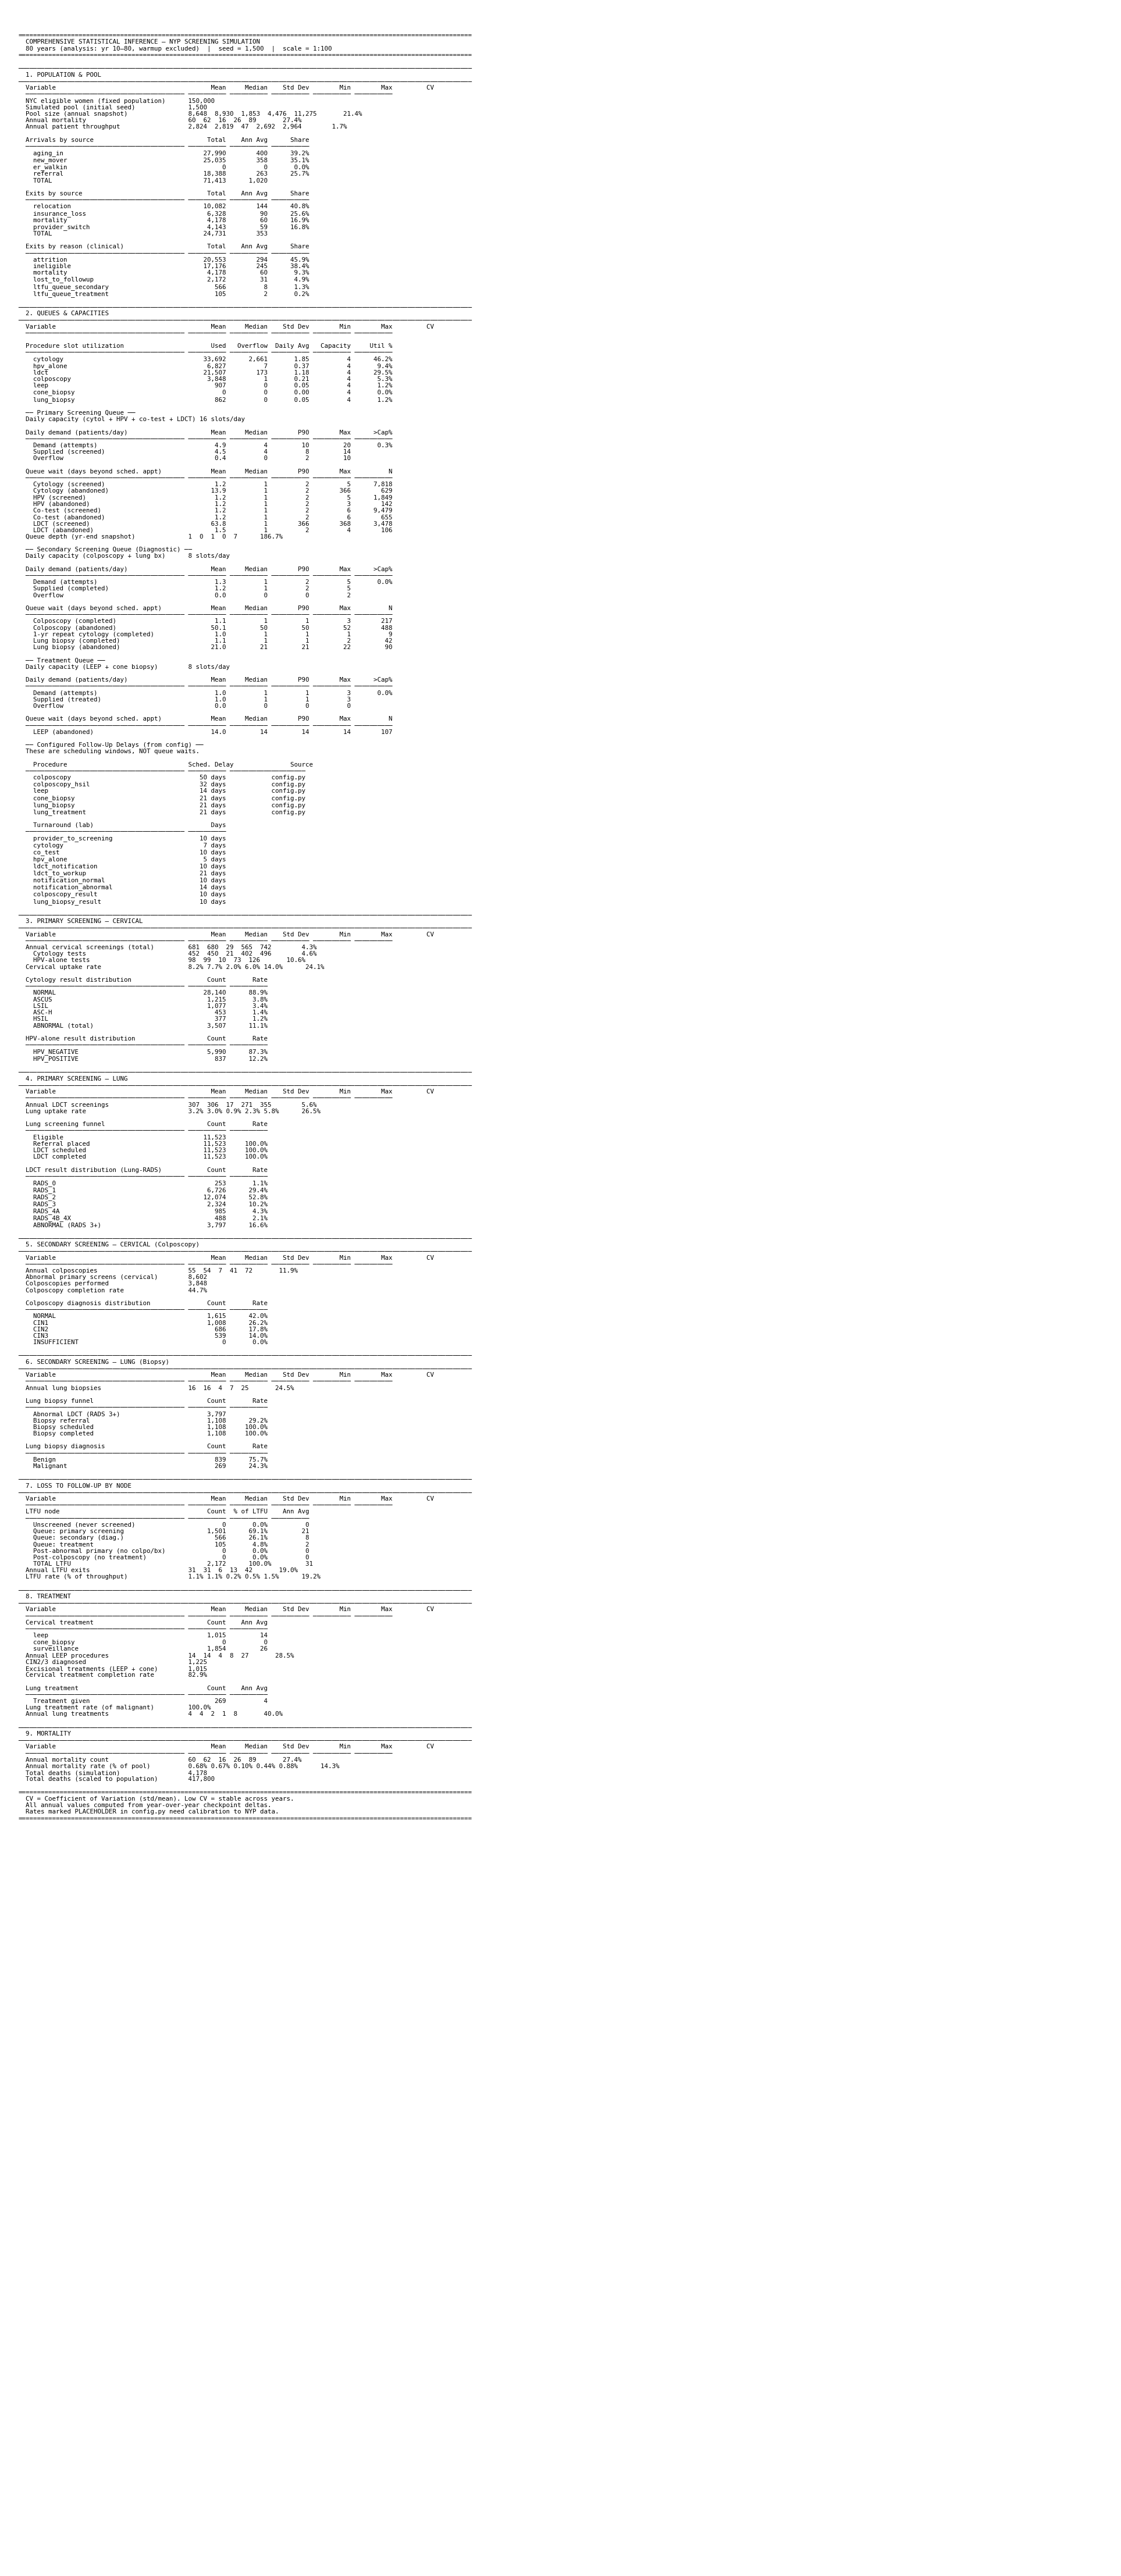

Saved: /Users/alexandrapaiz/Desktop/NYP/notebooks/Base Visualizations/00_statistical_inference_table.png


In [4]:
# ── Export Statistical Inference Table as Image ──────────────────────────────
# Captures the output of _print_stats_table() and renders as a high-res PNG.
import matplotlib.pyplot as plt
import io, sys

_buf = io.StringIO()
_stdout_bak = sys.stdout
sys.stdout = _buf
_print_stats_table()
sys.stdout = _stdout_bak
_text = _buf.getvalue()

# ── Render as image ──────────────────────────────────────────────────────────
lines = _text.split('\n')
n_lines = len(lines)
fig_h = max(8, n_lines * 0.135)
fig, ax = plt.subplots(figsize=(16, fig_h))
ax.axis('off')
fig.patch.set_facecolor('white')

ax.text(0.01, 0.99, _text, transform=ax.transAxes,
        fontsize=6.5, fontfamily='monospace', verticalalignment='top',
        horizontalalignment='left', linespacing=1.15)

plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(VIZ_DIR, "00_statistical_inference_table.png"),
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {os.path.join(VIZ_DIR, '00_statistical_inference_table.png')}")


### What the {cfg.SIM_YEARS}-Year Run Models

The simulation maintains a stable pool of **15,000 active patients** cycling through NYP's screening program at all times — roughly proportional to the real NYP women's health patient population using a scale factor. New patients enter continuously as others age out, die, or are lost to follow-up, keeping the pool size roughly constant the way a real hospital system does over decades.

Key parameters (all set in `config.py` and replaceable with real NYP data):

| Parameter | Current value | Source |
|---|---|---|
| Active patient pool | 15,000 | Placeholder — replace with NYP census |
| Daily patient volume | 200/day | Placeholder — replace with NYP scheduling data |
| Simulation horizon | cfg.SIM_YEARS years | Full patient lifetime |
| Random seed | None | Non-deterministic (different each run) — set an int for reproducibility |

**This cell may take several minutes to run.** Once complete, all charts below will populate automatically.

In [5]:
# ── Database summary + revenue analysis ─────────────────────────────────────
print("=== DATABASE SUMMARY ===")
sim_70yr.db_summary()

print()
print("=== REVENUE ANALYSIS ===")
sim_70yr.revenue_summary()

# Keep DB open for longitudinal plots below


=== DATABASE SUMMARY ===

── Database Summary ──────────────────────────────────────────
  Total flushed patients : 33,698
  Established (cycling)  : 33,698
  New entrants           : 0
  Mean visits per patient: 5.1
  Mean age at exit       : 54.9
  Mortality total        : 4,178
  Exit reasons:
    attrition:insurance_loss  6,769
    attrition:provider_switch 4,417
    attrition:relocation      10,804
    ineligible                4,965
    ltfu_queue_primary        1,594
    ltfu_queue_secondary      631
    ltfu_queue_treatment      118
    mortality                 4,400
  Exit sources (detailed):
    relocation                10,082
    insurance_loss            6,328
    mortality                 4,178
    provider_switch           4,143
  Arrival sources:
    aging_in                  27,990
    new_mover                 25,035
    referral                  18,388


=== REVENUE ANALYSIS ===

REVENUE ANALYSIS  (PLACEHOLDER CPT rates — replace with NYP data)

Realized revenue (pr

### Reading the Simulation Summary

The output below shows two things:

**Database summary** — total patient encounters written to the SQLite database (`nyp_70yr.db`). This is a persistent record of every simulated patient event and can be queried directly with SQL if needed.

**Revenue analysis** — procedure revenue across the full {cfg.SIM_YEARS}-year run. These figures use **placeholder CPT rates** and are not reflective of NYP contract rates. Replace the values in `config.py → PROCEDURE_REVENUE` with actual NYP rates before drawing any financial conclusions.

---

## Single Patient Trace

A randomly selected patient followed from her first visit to the end of her screening-eligible life. Every screening event, abnormal result, follow-up procedure, and clinical decision is printed in chronological order and rendered as a timeline.

In [6]:

import sys, random
sys.path.insert(0, '../src')

from patient import Patient
from population import sample_patient, draw_death_day
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening
import config as cfg


def trace_single_patient(
    starting_age: int   = 25,
    has_cervix:   bool  = True,
    smoker:       bool  = True,
    pack_years:   float = 15.0,   # accumulates +1/year while still smoking
    hpv_positive: bool  = False,
    race:         str   = "Hispanic/Latino",
    insurance:    str   = "Medicaid",
    seed:         int   = None,
) -> tuple:
    """
    Simulate one patient's full SIM_YEARS-year screening journey, year by year.

    Uses the EXACT same eligibility, result-draw, and follow-up
    functions as the full SimulationRunner — just for a single patient so
    every event is visible and the logic can be inspected step by step.

    Annual visit cadence
    --------------------
    The patient sees their provider once per year (every 365 days).
    • Cervical screening is every 3 years (ages 21–65) enforced by
      is_due_for_screening(), which checks last_cervical_screen_day.
    • HPV-alone (ages 30–65) carries a 5-year interval — so if that
      test is randomly assigned, the patient is skipped the following
      year's cervical check.
    • Lung screening is every year once age ≥ 50 AND pack_years ≥ 20
      AND still smoking or quit within 15 years.
    • Pack-years grow +1 per year while smoker=True.

    Follow-up logic
    ---------------
    • Abnormal cervical result → colposcopy at visit_day + 30.
    • CIN2/CIN3 at colposcopy → treatment (LEEP or cone) at colpo + 14 days.
    • RADS 4A/4B at LDCT → lung biopsy pathway triggered immediately.
    • LTFU at any clinical node: patient is RE-ACTIVATED and continues
      annual visits (mirrors established-patient logic in SimulationRunner).

    Mortality
    ---------
    Death day is pre-drawn from the Gompertz hazard at entry.
    When the visit day passes the death day, the loop breaks.

    Returns
    -------
    patient   : Patient with final clinical state after SIM_YEARS years (or death)
    metrics   : standard metrics dict (same structure as full sim run)
    timeline  : list of (day, age, category, description) tuples for plotting
    """
    random.seed(seed)

    # ── Create patient ─────────────────────────────────────────────────────────
    p = Patient(
        patient_id           = 1,
        day_created          = 0,
        patient_type         = "outpatient",
        destination          = "gynecologist",
        age                  = starting_age,
        race                 = race,
        insurance            = insurance,
        has_cervix           = has_cervix,
        smoker               = smoker,
        pack_years           = pack_years,
        years_since_quit     = 0.0,
        bmi                  = round(random.gauss(27.5, 5.0), 1),
        hpv_positive         = hpv_positive,
        hpv_vaccinated       = False,
        prior_abnormal_pap   = False,
        prior_cin            = None,
        is_established       = True,
        age_at_entry         = starting_age,
        simulation_entry_day = 0,
    )

    metrics  = initialize_metrics()
    timeline = []   # list of (day, age, category, description)
    entry_pack_years = pack_years   # remember entry value for reporting

    timeline.append((0, starting_age, "enrollment",
                     f"Entered system — age {starting_age}, smoker={smoker}, "
                     f"pack_years={pack_years:.0f}, has_cervix={has_cervix}"))
    p.log(0, f"ENTER SYSTEM  age={starting_age}  smoker={smoker}  "
             f"pack_years={pack_years:.0f}  has_cervix={has_cervix}")

    # Offset visit days past warmup so record_screening doesn't filter them out.
    # This is trace-only — the real simulation handles warmup separately.
    _day_offset = cfg.WARMUP_YEARS * 365

    # ── Pre-draw death day from Gompertz hazard ────────────────────────────────
    death_day = draw_death_day(p, entry_day=_day_offset)

    # ── {cfg.SIM_YEARS}-year annual visit loop ──────────────────────────────────────────────
    for year in range(cfg.SIM_YEARS):
        visit_day   = _day_offset + year * 365
        current_age = starting_age + year
        p.age       = current_age

        # Accumulate pack-years while still smoking (+1 pack-year per year)
        if p.smoker:
            p.pack_years += 1.0

        # ── Mortality check (Gompertz — pre-drawn at entry) ──────────────────
        if visit_day >= death_day:
            p.exit_system(visit_day, "mortality")
            timeline.append((visit_day, current_age, "mortality",
                             f"Death at age {current_age}"))
            p.log(visit_day, f"MORTALITY at age {current_age}")
            break

        # ── Annual provider visit ──────────────────────────────────────────────
        p.visit_count += 1
        p.log(visit_day, f"ANNUAL VISIT #{p.visit_count}  age={current_age}  "
                         f"pack_years={p.pack_years:.0f}")

        # ── Screen for each active cancer ──────────────────────────────────────
        for cancer in cfg.ACTIVE_CANCERS:

            result = run_screening_step(p, cancer, visit_day, metrics)

            # None means: not due yet, not eligible, or LTFU in lung pre-LDCT step
            if result is None:
                if not p.active:   # re-activate if lung pre-LDCT fired exit
                    p.active = True; p.exit_reason = None; p.exit_day = None
                continue

            record_screening(metrics, p, cancer, result, current_day=visit_day)

            # Classify for the timeline
            if cancer == "cervical":
                is_abn   = result not in ("NORMAL", "HPV_NEGATIVE")
            else:
                is_abn   = result in ("RADS_4A", "RADS_4B_4X")
            category = "screen_abnormal" if is_abn else "screen_normal"
            timeline.append((visit_day, current_age, category,
                             f"{cancer.upper()} screen: {result}"))

            # ── Cervical follow-up ─────────────────────────────────────────────
            if cancer == "cervical" and result not in ("NORMAL", "HPV_NEGATIVE"):
                colpo_day = visit_day + 30
                run_cervical_followup(p, colpo_day, metrics)

                if p.colposcopy_result:
                    timeline.append((colpo_day, current_age, "colposcopy",
                                     f"Colposcopy → {p.colposcopy_result}"))

                if p.treatment_type and p.treatment_type != "surveillance":
                    treat_day = colpo_day + cfg.FOLLOWUP_DELAY_DAYS.get(p.treatment_type, 14)
                    timeline.append((treat_day, current_age, "treatment",
                                     f"Treatment: {p.treatment_type.upper()}"))

                if not p.active:   # re-activate post-LTFU/treatment so cycle continues
                    p.active = True; p.exit_reason = None; p.exit_day = None
                p.colposcopy_result = None   # reset for next screening cycle
                p.treatment_type    = None

            # ── Lung follow-up ─────────────────────────────────────────────────
            elif cancer == "lung":
                # Record biopsy pathway entry BEFORE running follow-up.
                # run_lung_followup may modify p.lung_result internally
                # (e.g. biopsy result overwrites it), so the check must
                # happen here while we still have the LDCT result.
                if result in ("RADS_4A", "RADS_4B_4X"):
                    fu_day = visit_day + 1
                    timeline.append((fu_day, current_age, "lung_followup",
                                     f"Lung biopsy pathway triggered ({result})"))

                run_lung_followup(p, visit_day + 1, metrics)
                if not p.active:
                    p.active = True; p.exit_reason = None; p.exit_day = None

    else:
        # Loop completed all cfg.SIM_YEARS years without mortality
        end_age = starting_age + 70
        timeline.append((70 * 365, end_age, "end_of_sim",
                         f"End of simulation — survived to age {end_age}"))
        p.log(70 * 365, f"END OF SIMULATION  age={end_age}")

    # Attach entry pack_years so the viz cell can reference it
    p._entry_pack_years = entry_pack_years
    return p, metrics, timeline


print("trace_single_patient() defined.")


trace_single_patient() defined.


### How the Patient Trace Works

The trace function runs a single patient through the full simulation from her entry age to age 100 (or death), stepping through every annual visit, screening event, abnormal result, follow-up referral, and clinical decision.

At each step, the simulation:
1. Checks whether the patient is due for screening based on her age and the time since her last test
2. Draws a result from the age-appropriate probability table
3. Routes abnormal results to the correct follow-up pathway (colposcopy, LEEP, or lung biopsy)
4. Applies an annual mortality draw based on her current age

The patient's full event history is stored in `timeline` and printed as a chronological log, then rendered as the colour-coded chart below.

In [7]:
# Randomly sample a patient profile — retry until we get one who was screened
random.seed(None)

MAX_ATTEMPTS = 200
patient, pt_metrics, timeline = None, None, None

for _attempt in range(MAX_ATTEMPTS):
    _sample = sample_patient(patient_id=0, day_created=0, destination="gynecologist", patient_type="outpatient")
    _p, _m, _tl = trace_single_patient(
        starting_age = _sample.age,
        has_cervix   = _sample.has_cervix,
        smoker       = _sample.smoker,
        pack_years   = _sample.pack_years,
        hpv_positive = _sample.hpv_positive,
        race         = _sample.race,
        insurance    = _sample.insurance,
        seed         = random.randint(0, 99999),
    )
    # Accept only patients who had at least one screening event
    has_screening = any(cat.startswith("screen_") for _, _, cat, _ in _tl)
    if has_screening:
        patient, pt_metrics, timeline = _p, _m, _tl
        break
else:
    # Fallback: use last attempt even if no screening (shouldn't happen)
    patient, pt_metrics, timeline = _p, _m, _tl
    print(f"WARNING: no screened patient found in {MAX_ATTEMPTS} attempts — using last sample")

print(f"{'='*66}")
print(f"  Randomly selected patient (sampled in {_attempt + 1} attempt{'s' if _attempt else ''})")
print(f"  Entry age={patient.age_at_entry}  |  smoker={patient.smoker}  |  "
      f"has_cervix={patient.has_cervix}  |  race={patient.race}")
print(f"  Pack-years at entry: {getattr(patient, '_entry_pack_years', patient.pack_years):.0f}")
print(f"  Total provider visits: {patient.visit_count}")
print(f"{'='*66}\n")

for day, event in patient.event_log:
    year = day // 365
    age  = patient.age_at_entry + year
    print(f"  Day {day:>6}  (age {age:>3})  {event}")

print()
print(f"Final age     : {patient.age}")
print(f"Exit reason   : {patient.exit_reason or 'alive at end of simulation'}")
print(f"Cervical primary  : {pt_metrics['n_screened']['cervical']}")
print(f"Cervical secondary: {pt_metrics['n_colposcopy']}")
print(f"Lung primary      : {pt_metrics['n_screened']['lung']}")
print(f"Lung secondary    : {pt_metrics.get('lung_biopsy_completed', 0)}")

  Randomly selected patient (sampled in 1 attempt)
  Entry age=27  |  smoker=False  |  has_cervix=True  |  race=White
  Pack-years at entry: 0
  Total provider visits: 21

  Day      0  (age  27)  ENTER SYSTEM  age=27  smoker=False  pack_years=0  has_cervix=True
  Day   3650  (age  37)  ANNUAL VISIT #1  age=27  pack_years=0
  Day   3650  (age  37)  SCREEN cervical via cytology
  Day   3650  (age  37)  RESULT cervical: NORMAL
  Day   3650  (age  37)  SKIP lung — not eligible (age=27)
  Day   4015  (age  38)  ANNUAL VISIT #2  age=28  pack_years=0
  Day   4015  (age  38)  SKIP cervical — not yet due
  Day   4015  (age  38)  SKIP lung — not eligible (age=28)
  Day   4380  (age  39)  ANNUAL VISIT #3  age=29  pack_years=0
  Day   4380  (age  39)  SKIP cervical — not yet due
  Day   4380  (age  39)  SKIP lung — not eligible (age=29)
  Day   4745  (age  40)  ANNUAL VISIT #4  age=30  pack_years=0
  Day   4745  (age  40)  SCREEN cervical via hpv_alone
  Day   4745  (age  40)  RESULT cervical: HP

The cell below draws a **randomly selected patient** from the population distribution each time it is run. To trace the same patient repeatedly (e.g. for a presentation), replace `random.seed(None)` with a fixed integer like `random.seed(7)`. The printed summary beneath the chart shows her demographics, number of screenings, and final outcome.

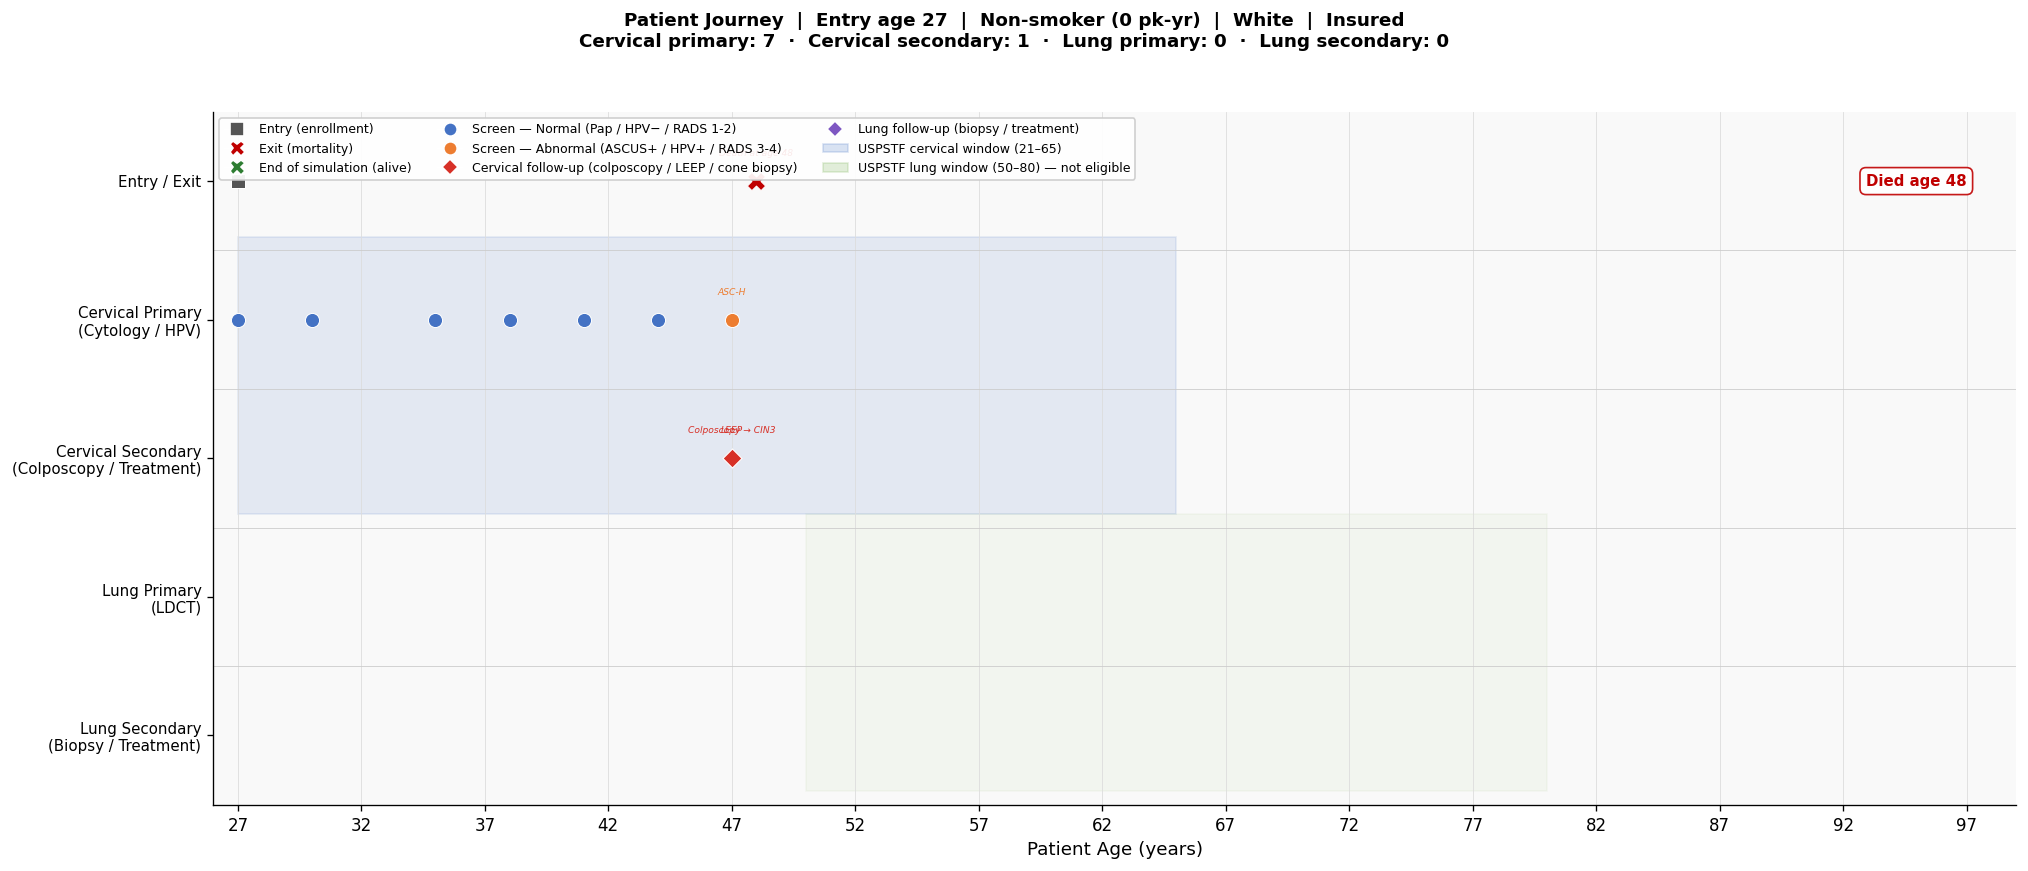

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PATIENT TRACE — Separate lanes for:
#   1. Entry / Exit
#   2. Cervical Primary Screening (Cytology / HPV)
#   3. Cervical Secondary Screening (Colposcopy / Treatment)
#   4. Lung Primary Screening (LDCT)
#   5. Lung Secondary Screening (Biopsy / Treatment)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

cerv_elig = cfg.ELIGIBILITY["cervical"]
lung_elig = cfg.ELIGIBILITY["lung"]
entry_pk  = getattr(patient, "_entry_pack_years", patient.pack_years)

# ── Classify timeline events into distinct lanes ─────────────────────────────
ev_entry       = []   # enrollment
ev_exit        = []   # mortality / end-of-sim
ev_cerv_prim   = []   # cervical primary screen (normal + abnormal)
ev_cerv_sec    = []   # colposcopy, cervical treatment
ev_lung_prim   = []   # lung primary screen (LDCT results)
ev_lung_sec    = []   # lung biopsy, lung treatment

for day, age, category, desc in timeline:
    if category == "enrollment":
        ev_entry.append((age, desc, "#555555"))
    elif category == "mortality":
        ev_exit.append((age, desc, "#C00000"))
    elif category == "end_of_sim":
        ev_exit.append((age, desc, "#2E7D32"))
    elif category == "screen_normal" and "CERVICAL" in desc.upper():
        ev_cerv_prim.append((age, desc, "#4472C4"))
    elif category == "screen_abnormal" and "CERVICAL" in desc.upper():
        ev_cerv_prim.append((age, desc, "#ED7D31"))
    elif category == "screen_normal" and "LUNG" in desc.upper():
        ev_lung_prim.append((age, desc, "#70AD47"))
    elif category == "screen_abnormal" and "LUNG" in desc.upper():
        ev_lung_prim.append((age, desc, "#ED7D31"))
    elif category in ("colposcopy", "treatment"):
        ev_cerv_sec.append((age, desc, "#D73027"))
    elif category == "lung_followup":
        ev_lung_sec.append((age, desc, "#7E57C2"))

# ── Layout: 5 horizontal lanes ──────────────────────────────────────────────
lane_labels = [
    "Entry / Exit",
    "Cervical Primary\n(Cytology / HPV)",
    "Cervical Secondary\n(Colposcopy / Treatment)",
    "Lung Primary\n(LDCT)",
    "Lung Secondary\n(Biopsy / Treatment)",
]
n_lanes = len(lane_labels)

age_min = patient.age_at_entry
age_max = patient.age_at_entry + 71

fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f9f9f9")
ax.set_xlim(age_min - 1, age_max + 1)
ax.set_ylim(-0.5, n_lanes - 0.5)

# Grid lines
for decade in range(int(age_min), int(age_max) + 1, 5):
    ax.axvline(decade, color="#dddddd", linewidth=0.5, zorder=1)

# ── USPSTF eligibility windows (background bands) ───────────────────────────
cerv_start = max(cerv_elig["age_min"], age_min)
cerv_end   = min(cerv_elig["age_max"], age_max)
lung_start = max(lung_elig["age_min"], age_min)
lung_end   = min(lung_elig["age_max"], age_max)

cerv_applicable = patient.has_cervix if cerv_elig.get("requires_cervix") else True
min_pk = lung_elig.get("min_pack_years", 20)
lung_is_eligible = patient.smoker and entry_pk >= min_pk

# Cervical window spans lanes 1-2 (primary + secondary)
if cerv_applicable and cerv_start < cerv_end:
    ax.axvspan(cerv_start, cerv_end, ymin=0.42, ymax=0.82, alpha=0.12, color="#4472C4", zorder=0)

# Lung window spans lanes 3-4 (primary + secondary)
if lung_start < lung_end:
    alpha_l = 0.12 if lung_is_eligible else 0.05
    ax.axvspan(lung_start, lung_end, ymin=0.02, ymax=0.42, alpha=alpha_l, color="#70AD47", zorder=0)

# ── Plot events on lanes ─────────────────────────────────────────────────────
def _plot_lane(lane_y, events, marker, size, default_color=None):
    for age, desc, color in events:
        c = default_color or color
        ax.scatter(age, lane_y, color=c, marker=marker, s=size, zorder=5,
                   edgecolors="white", linewidths=0.6)
        # Annotation for abnormal/treatment events
        if color in ("#ED7D31", "#D73027", "#7E57C2", "#C00000"):
            short = desc.split(":")[1].strip() if ":" in desc else desc[:20]
            ax.text(age, lane_y + 0.18, short, fontsize=5.5, ha="center",
                    color=color, style="italic", clip_on=True)

# Lane 4 (bottom): Entry / Exit — inverted y so lane 0 is top
_plot_lane(4, ev_entry, "s", 80)
_plot_lane(4, ev_exit, "X", 120)

# Lane 3: Cervical Primary
_plot_lane(3, ev_cerv_prim, "o", 72)

# Lane 2: Cervical Secondary (colposcopy / treatment)
_plot_lane(2, ev_cerv_sec, "D", 64)

# Lane 1: Lung Primary
_plot_lane(1, ev_lung_prim, "o", 72)

# Lane 0 (top): Lung Secondary (biopsy / treatment)
_plot_lane(0, ev_lung_sec, "D", 64)

# ── Outcome annotation ──────────────────────────────────────────────────────
outcome_str = (
    f"Died age {patient.age}" if patient.exit_reason == "mortality"
    else f"Alive at simulation end (age {patient.age})"
    if not patient.exit_reason
    else f"Exit: {patient.exit_reason} (age {patient.age})"
)
outcome_color = (
    "#C00000" if patient.exit_reason == "mortality"
    else "#2E7D32" if not patient.exit_reason
    else "#FF8C00"
)
ax.annotate(
    outcome_str,
    xy=(age_max - 1, 4), fontsize=9, ha="right", va="center",
    color=outcome_color, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=outcome_color, alpha=0.9)
)

# ── Y-axis labels ────────────────────────────────────────────────────────────
ax.set_yticks(range(n_lanes))
ax.set_yticklabels(list(reversed(lane_labels)), fontsize=9)
ax.set_xlabel("Patient Age (years)", fontsize=11)
ax.set_xticks(range(int(age_min), int(age_max) + 1, 5))

# ── Horizontal separators between lanes ──────────────────────────────────────
for y in [0.5, 1.5, 2.5, 3.5]:
    ax.axhline(y, color="#cccccc", linewidth=0.5, zorder=1)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#555555", markersize=8, label="Entry (enrollment)"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="#C00000", markersize=9, label="Exit (mortality)"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="#2E7D32", markersize=9, label="End of simulation (alive)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4472C4", markersize=8, label="Screen — Normal (Pap / HPV− / RADS 1-2)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ED7D31", markersize=8, label="Screen — Abnormal (ASCUS+ / HPV+ / RADS 3-4)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#D73027", markersize=7, label="Cervical follow-up (colposcopy / LEEP / cone biopsy)"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="#7E57C2", markersize=7, label="Lung follow-up (biopsy / treatment)"),
    mpatches.Patch(color="#4472C4", alpha=0.2, label=f"USPSTF cervical window ({cerv_elig['age_min']}–{cerv_elig['age_max']})"),
    mpatches.Patch(color="#70AD47", alpha=0.2,
                   label=f"USPSTF lung window ({lung_elig['age_min']}–{lung_elig['age_max']})"
                         f"{'' if lung_is_eligible else ' — not eligible'}"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=7.5, framealpha=0.92, ncol=3)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    f"Patient Journey  |  Entry age {patient.age_at_entry}  |  "
    f"{'Smoker' if patient.smoker else 'Non-smoker'} ({entry_pk:.0f} pk-yr)  |  "
    f"{patient.race}  |  {patient.insurance}\n"
    f"Cervical primary: {pt_metrics['n_screened']['cervical']}  ·  "
    f"Cervical secondary: {pt_metrics['n_colposcopy']}  ·  "
    f"Lung primary: {pt_metrics['n_screened']['lung']}  ·  "
    f"Lung secondary: {pt_metrics.get('lung_biopsy_completed', 0)}",
    fontsize=11, fontweight="bold", y=1.03
)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("patient_trace_timeline"), dpi=150, bbox_inches="tight")
plt.show()

#### Patient Scheduling Detail

Breaks down this patient's clinical events by pathway (cervical vs lung) and stage (primary screening vs follow-up). Each row shows the event, the gap since the previous event *in the same pathway*, and what type of gap it is (routine screening interval vs follow-up scheduling delay).

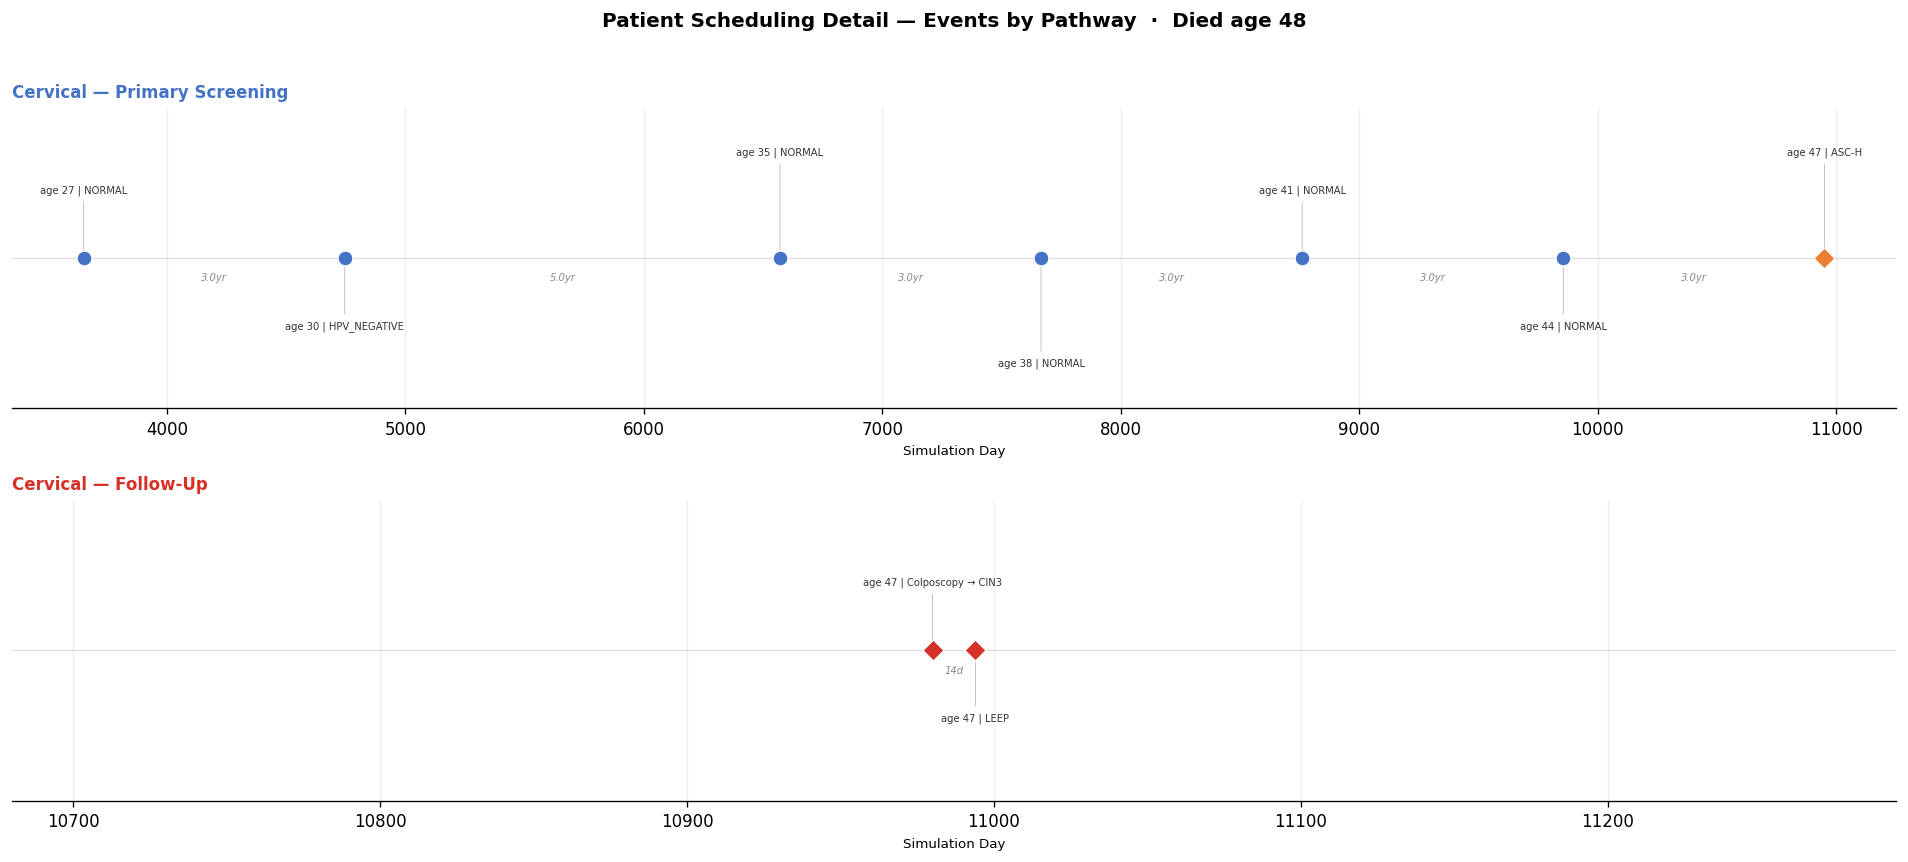


    Day   Age  Pathway      Event
----------------------------------------------------------------------
      0    27  Entry/Exit   Entered system — age 27, smoker=False, pack_years=0, has_cervix=True
   3650    27  Cerv 1°      CERVICAL screen: NORMAL
   4745    30  Cerv 1°      CERVICAL screen: HPV_NEGATIVE
   6570    35  Cerv 1°      CERVICAL screen: NORMAL
   7665    38  Cerv 1°      CERVICAL screen: NORMAL
   8760    41  Cerv 1°      CERVICAL screen: NORMAL
   9855    44  Cerv 1°      CERVICAL screen: NORMAL
  10950    47  Cerv 1°      CERVICAL screen: ASC-H
  10980    47  Cerv F/U     Colposcopy → CIN3
  10994    47  Cerv F/U     Treatment: LEEP
  11315    48  Entry/Exit   Death at age 48


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import config as cfg

# ═════════════════════════════════════════════════════════════════════════════
# Patient Scheduling Detail — Per-Pathway Event Breakdown
#
# Separates events by:
#   1. Cancer type (cervical vs lung)
#   2. Stage (primary screening vs diagnostic/treatment)
# ═════════════════════════════════════════════════════════════════════════════

# ── Classify events into pathways ────────────────────────────────────────────
cerv_primary  = []  # (day, age, desc)
cerv_followup = []
lung_primary  = []
lung_followup = []
entry_exit    = []

for day, age, cat, desc in timeline:
    if cat == "enrollment":
        entry_exit.append((day, age, "ENTRY", desc))
    elif cat in ("mortality", "end_of_sim"):
        entry_exit.append((day, age, "EXIT", desc))
    elif cat in ("screen_normal", "screen_abnormal") and "CERVICAL" in desc.upper():
        stage = "ABNORMAL" if cat == "screen_abnormal" else "NORMAL"
        cerv_primary.append((day, age, stage, desc))
    elif cat in ("screen_normal", "screen_abnormal") and "LUNG" in desc.upper():
        stage = "ABNORMAL" if cat == "screen_abnormal" else "NORMAL"
        lung_primary.append((day, age, stage, desc))
    elif cat in ("colposcopy", "treatment"):
        cerv_followup.append((day, age, cat.upper(), desc))
    elif cat == "lung_followup":
        lung_followup.append((day, age, "LUNG F/U", desc))

# ── Build figure: up to 4 panels (skip empty pathways) ──────────────────────
panels = []
if cerv_primary:
    panels.append(("Cervical — Primary Screening", cerv_primary, "#4472C4"))
if cerv_followup:
    panels.append(("Cervical — Follow-Up", cerv_followup, "#D73027"))
if lung_primary:
    panels.append(("Lung — Primary Screening (LDCT)", lung_primary, "#70AD47"))
if lung_followup:
    panels.append(("Lung — Follow-Up", lung_followup, "#7E57C2"))

if not panels:
    print("No clinical events to display.")
else:
    n_panels = len(panels)
    fig, axes = plt.subplots(n_panels, 1,
                             figsize=(16, max(4, n_panels * 3.5)),
                             squeeze=False)
    fig.patch.set_facecolor("white")

    # Stagger offsets: cycle through 4 levels to avoid overlap
    y_offsets = [0.25, -0.25, 0.40, -0.40]

    for idx, (title, events, color) in enumerate(panels):
        ax = axes[idx, 0]

        days  = [e[0] for e in events]

        # Plot events as markers on a horizontal timeline
        for i, (d, a, tag, desc) in enumerate(events):
            marker = "o" if tag in ("NORMAL", "LUNG F/U") else "D"
            mc = "#ED7D31" if tag == "ABNORMAL" else color
            ax.scatter(d, 0, color=mc, marker=marker, s=80, zorder=5,
                       edgecolors="white", linewidths=0.8)

            # Stagger labels across 4 levels
            y_off = y_offsets[i % len(y_offsets)]
            va = "bottom" if y_off > 0 else "top"

            # Short label: just the result keyword
            if ": " in desc:
                short = desc.split(": ", 1)[1]
            else:
                short = desc[:20]
            # Truncate long labels
            if len(short) > 22:
                short = short[:20] + "…"

            ax.annotate(
                f"age {a:.0f} | {short}",
                xy=(d, 0), xytext=(d, y_off),
                fontsize=6, ha="center", va=va, color="#333",
                arrowprops=dict(arrowstyle="-", color="#bbb", lw=0.5),
            )

        # Draw gap annotations between consecutive events
        for i in range(1, len(events)):
            gap = events[i][0] - events[i-1][0]
            mid = (events[i-1][0] + events[i][0]) / 2
            gap_yr = gap / 365
            label = f"{gap}d" if gap < 365 else f"{gap_yr:.1f}yr"
            ax.annotate(label, xy=(mid, -0.06), fontsize=6, ha="center",
                        va="top", color="#888", fontstyle="italic")

        ax.set_xlim(min(days) - 300, max(days) + 300)
        ax.set_ylim(-0.6, 0.6)
        ax.set_yticks([])
        ax.set_xlabel("Simulation Day", fontsize=8)
        ax.set_title(title, fontsize=10, fontweight="bold", color=color, loc="left")
        ax.axhline(0, color="#ddd", lw=0.8, zorder=0)
        ax.grid(axis="x", alpha=0.2)
        ax.spines[["top", "right", "left"]].set_visible(False)

    # ── Suptitle ─────────────────────────────────────────────────────────────
    mort = next(((d, a) for d, a, c, _ in timeline if c == "mortality"), None)
    mort_str = f"  ·  Died age {mort[1]:.0f}" if mort else ""
    fig.suptitle(
        f"Patient Scheduling Detail — Events by Pathway{mort_str}",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(viz_path("patient_scheduling_detail"), dpi=150, bbox_inches="tight")
    plt.show()

# ── Text table ───────────────────────────────────────────────────────────────
print(f"\n{'Day':>7}  {'Age':>4}  {'Pathway':<12} {'Event'}")
print("-" * 70)
all_events = (
    [(d, a, "Entry/Exit", desc) for d, a, _, desc in entry_exit]
    + [(d, a, "Cerv 1°", desc) for d, a, _, desc in cerv_primary]
    + [(d, a, "Cerv F/U", desc) for d, a, _, desc in cerv_followup]
    + [(d, a, "Lung 1°", desc) for d, a, _, desc in lung_primary]
    + [(d, a, "Lung F/U", desc) for d, a, _, desc in lung_followup]
)
for d, a, pathway, desc in sorted(all_events, key=lambda x: x[0]):
    print(f"  {d:>5}  {a:>4.0f}  {pathway:<12} {desc}")

---

## Longitudinal Visualizations

How the screening program performs year by year across the {cfg.SIM_YEARS}-year horizon.

| Chart | What it shows |
|---|---|
| **Screening Volume Over Time** | Annual cervical and lung screening throughput, with LTFU and pool stability |
| **Clinical Rates Over Time** | How screening, abnormal result, and completion rates evolve across the simulation |
| **Revenue Over Time** | Annual realized revenue by procedure type, cumulative total, and LTFU lost revenue |
| **Patient Journey Cascade** | Cumulative {cfg.SIM_YEARS}-year funnel from provider visit to treatment |
| **Lung Cancer Pathway** | Attrition from eligible smoker to treatment, with RADS distribution |
| **Population Dynamics** | Pool stability, annual throughput, and provider capacity |

### Individual Charts

Each chart below produces a **single image** saved to `Base Visualizations/`.


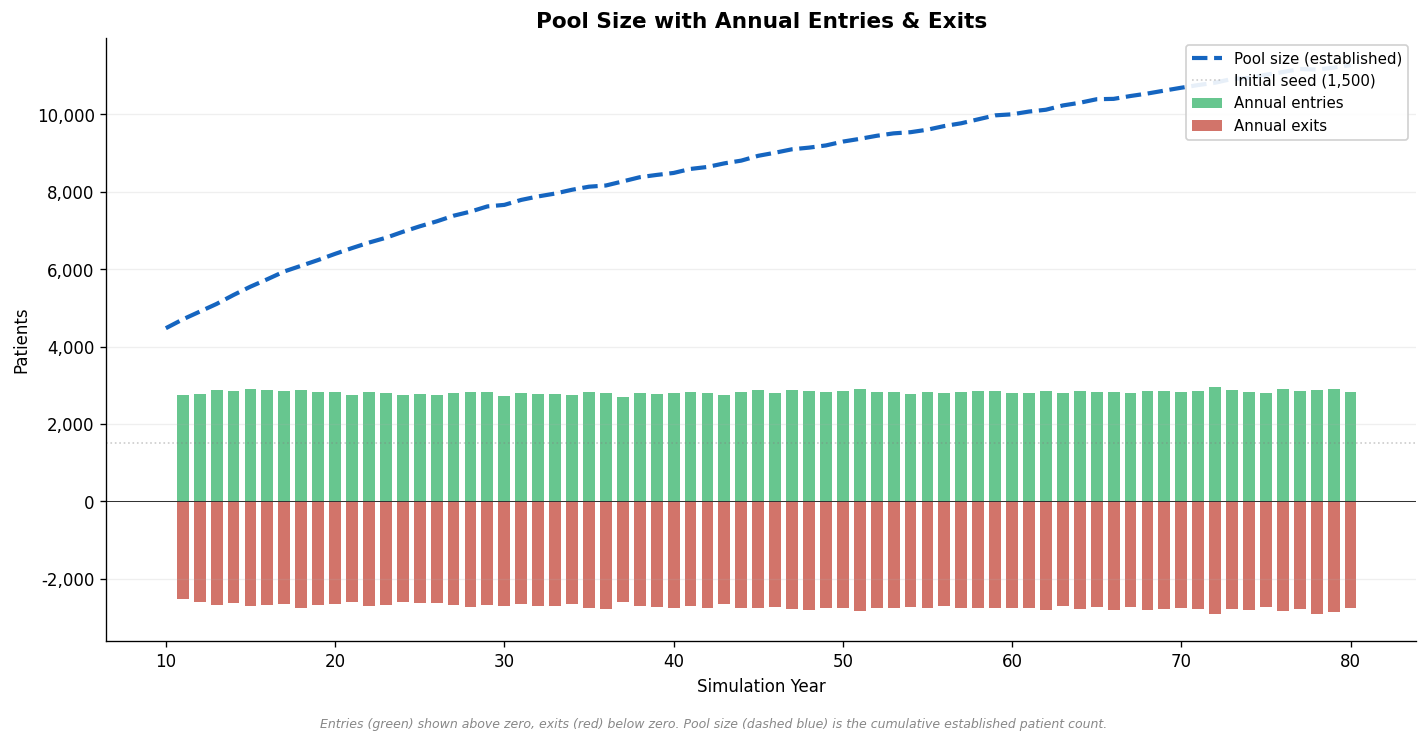

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]

pool_size = np.array([c["pool_size"] for c in chk])
yrs       = np.array(years)

# Compute annual entries and exits from checkpoint deltas
pts_cum  = np.array([c.get("cum_n_patients", 0) for c in chk])
pool_delta  = np.diff(pool_size)
ann_entries = np.diff(pts_cum)
# Total exits = entries - change in pool size
ann_exits_total = ann_entries - pool_delta

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")

x = yrs[1:]
w = 0.7

# Entries above zero (green), exits below zero (red)
ax.bar(x, ann_entries, width=w, color="#27AE60", alpha=0.7, label="Annual entries")
ax.bar(x, -ann_exits_total, width=w, color="#C0392B", alpha=0.7, label="Annual exits")

# Pool size as a line on the same axis
ax.plot(yrs, pool_size, color="#1565C0", lw=2.5, ls="--", label="Pool size (established)")
ax.axhline(cfg.INITIAL_POOL_SIZE, color="gray", lw=1, ls=":",
           alpha=0.4, label=f"Initial seed ({cfg.INITIAL_POOL_SIZE:,})")

# Zero line
ax.axhline(0, color="#333", lw=0.6)

ax.set_xlabel("Simulation Year", fontsize=10)
ax.set_ylabel("Patients", fontsize=10)
ax.set_title("Pool Size with Annual Entries & Exits",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.02,
         "Entries (green) shown above zero, exits (red) below zero. "
         "Pool size (dashed blue) is the cumulative established patient count.",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("pool_size"), dpi=150, bbox_inches="tight")
plt.show()

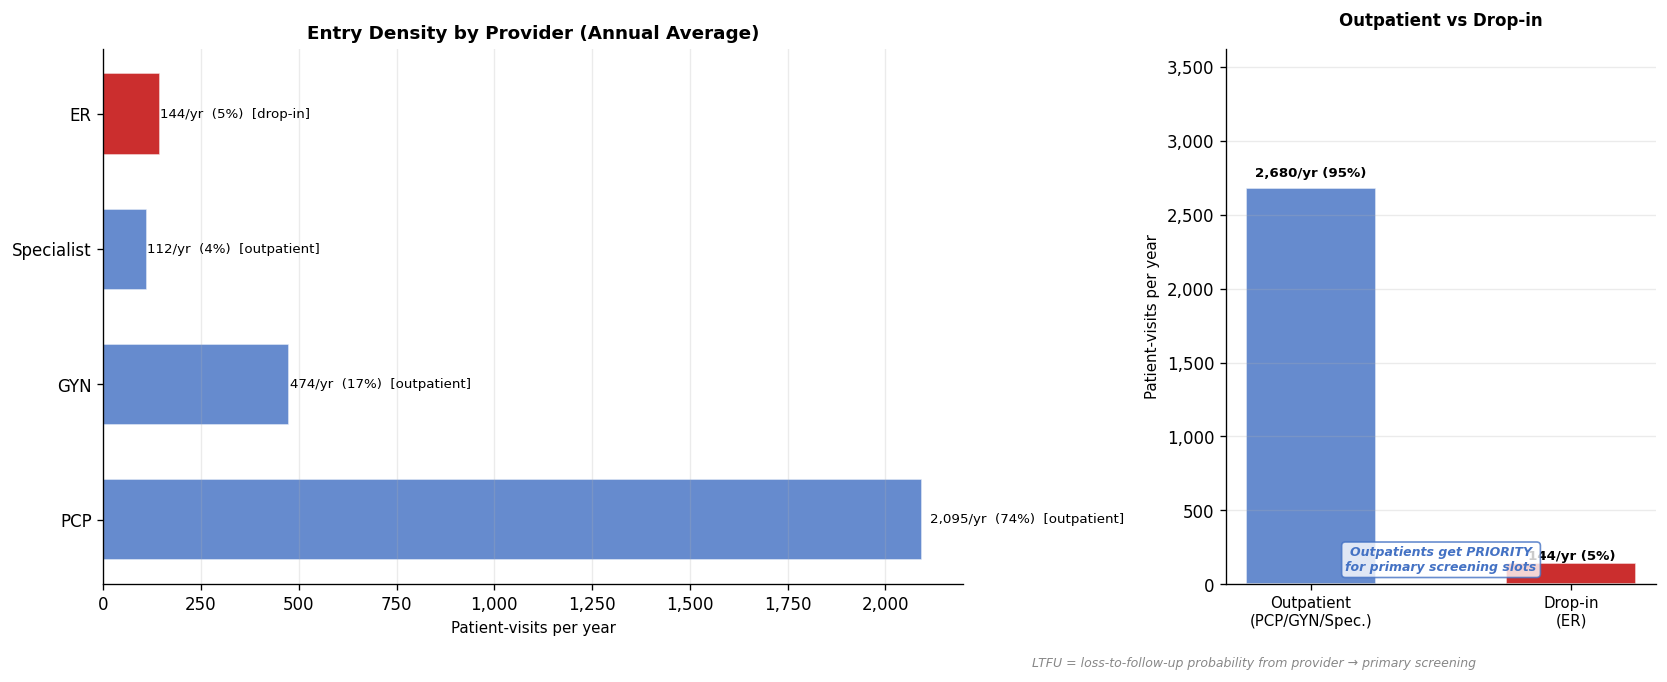

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import config as cfg

m = metrics_70yr
sim_years = cfg.SIM_YEARS - cfg.WARMUP_YEARS  # post-warmup analysis period

dest_counts = dict(m.get("entries_by_destination", {}))
type_counts = dict(m.get("entries_by_type", {}))

# ── Group providers into Outpatient vs Drop-in ───────────────────────────────
outpatient_provs = ["pcp", "gynecologist", "specialist"]
dropin_provs     = ["er"]

dest_labels = {"pcp": "PCP", "gynecologist": "GYN", "specialist": "Specialist", "er": "ER"}
C_OP    = "#4472C4"   # outpatient blue
C_DI    = "#C00000"   # drop-in red

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [2, 1]})
fig.patch.set_facecolor("white")

# ── Left panel: bars by individual provider, color-coded by type ─────────────
all_provs = outpatient_provs + dropin_provs
ann_vals  = []
colors    = []
labels    = []
for d in all_provs:
    cnt = dest_counts.get(d, 0)
    ann = cnt / max(sim_years, 1)
    ann_vals.append(ann)
    labels.append(dest_labels[d])
    colors.append(C_OP if d in outpatient_provs else C_DI)

y_pos = range(len(all_provs))
bars = ax1.barh(y_pos, ann_vals, color=colors, alpha=0.82, edgecolor="white", height=0.6)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(labels, fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
total_ann = sum(ann_vals)

for bar, val, d in zip(bars, ann_vals, all_provs):
    pct = 100 * val / max(total_ann, 1)
    ptype = "outpatient" if d in outpatient_provs else "drop-in"
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f"{val:,.0f}/yr  ({pct:.0f}%)  [{ptype}]", va="center", fontsize=8)

ax1.set_title("Entry Density by Provider (Annual Average)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Patient-visits per year", fontsize=9)
ax1.grid(axis="x", alpha=0.25)
ax1.spines[["top", "right"]].set_visible(False)

# ── Right panel: outpatient vs drop-in summary ──────────────────────────────
total_op = sum(dest_counts.get(d, 0) for d in outpatient_provs)
total_di = sum(dest_counts.get(d, 0) for d in dropin_provs)
total    = max(total_op + total_di, 1)


grp_names = ["Outpatient\n(PCP/GYN/Spec.)", "Drop-in\n(ER)"]
grp_vals  = [total_op / max(sim_years, 1), total_di / max(sim_years, 1)]
grp_colors = [C_OP, C_DI]

bars2 = ax2.bar(range(2), grp_vals, color=grp_colors, alpha=0.82, edgecolor="white", width=0.5)
ax2.set_xticks(range(2))
ax2.set_xticklabels(grp_names, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

for bar, val, pct_raw in zip(bars2, grp_vals, [total_op, total_di]):
    pct = 100 * pct_raw / total
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f"{val:,.0f}/yr ({pct:.0f}%)",
             ha="center", va="bottom", fontsize=8, fontweight="bold")

ax2.set_title("Outpatient vs Drop-in", fontsize=10, fontweight="bold", pad=14)
ax2.set_ylabel("Patient-visits per year", fontsize=9)
ax2.grid(axis="y", alpha=0.25)
ax2.spines[["top", "right"]].set_visible(False)

# Increase top margin so annotations don't overlap title
y_max = max(grp_vals) if grp_vals else 1
ax2.set_ylim(0, y_max * 1.35)

# Priority annotation
ax2.text(0.5, 0.02, "Outpatients get PRIORITY\nfor primary screening slots",
         transform=ax2.transAxes, ha="center", va="bottom",
         fontsize=7.5, color=C_OP, fontweight="bold", fontstyle="italic",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=C_OP, alpha=0.8))

# Subtitle with LTFU context
fig.text(0.75, -0.02,
         "LTFU = loss-to-follow-up probability from provider → primary screening",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("entry_density"), dpi=150, bbox_inches="tight")
plt.show()

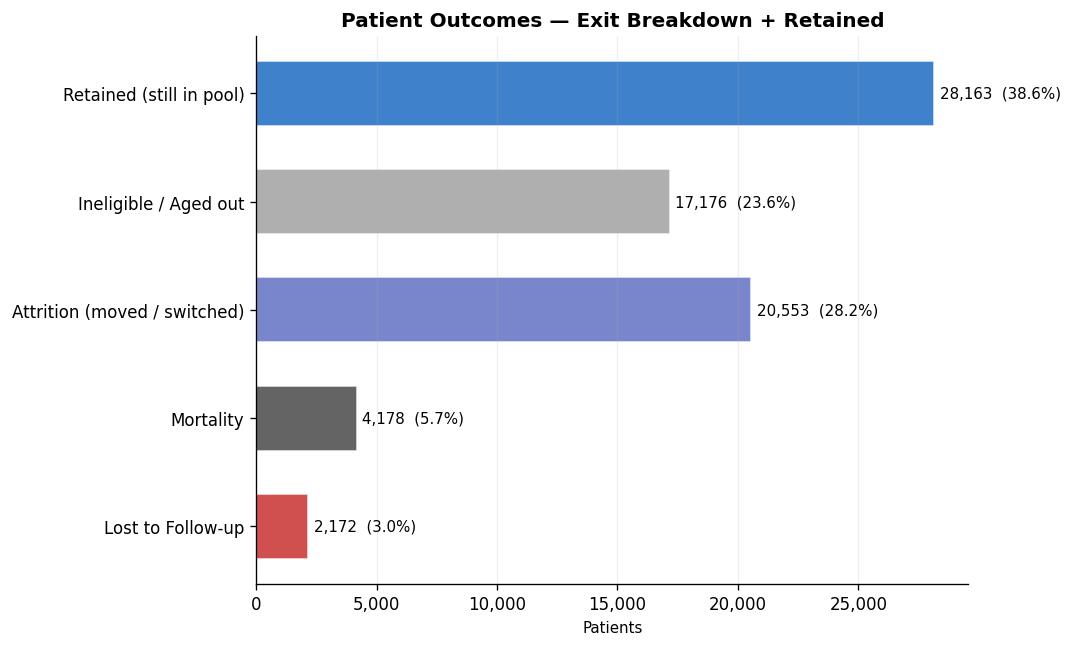

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import config as cfg

m = metrics_70yr

# Total patients who ever entered the pool
# (initial seed + all arrivals over the run)
total_pool = cfg.INITIAL_POOL_SIZE + sum(m.get("arrivals_by_source", {}).values())

exit_counts = dict(m.get("exits_by_reason", {}))
total_exits = sum(exit_counts.values())
retained    = total_pool - total_exits

# ═════════════════════════════════════════════════════════════════════════════
# Exit Breakdown by Reason — with Retained as residual
# ═════════════════════════════════════════════════════════════════════════════

exit_order  = ["treated", "lost_to_followup", "mortality",
               "attrition", "ineligible"]
exit_labels = {"treated": "Treated (completed care)",
               "lost_to_followup": "Lost to Follow-up", "mortality": "Mortality",
               "attrition": "Attrition (moved / switched)",
               "ineligible": "Ineligible / Aged out"}
exit_colors = {"treated": "#2E7D32", "lost_to_followup": "#C62828",
               "mortality": "#424242", "attrition": "#5C6BC0",
               "ineligible": "#9E9E9E"}

# Build bars: exits first, then retained at the bottom
reasons = [r for r in exit_order if exit_counts.get(r, 0) > 0]
vals    = [exit_counts[r] for r in reasons]
lbls    = [exit_labels.get(r, r) for r in reasons]
colors  = [exit_colors.get(r, "#BDBDBD") for r in reasons]

# Add retained as last bar
reasons.append("retained")
vals.append(max(retained, 0))
lbls.append("Retained (still in pool)")
colors.append("#1565C0")

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor("white")

bars = ax.barh(range(len(reasons)), vals, color=colors, alpha=0.82,
               edgecolor="white", height=0.6)
ax.set_yticks(range(len(reasons)))
ax.set_yticklabels(lbls, fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{int(v):,}"))

for bar, val in zip(bars, vals):
    pct = 100 * val / max(total_pool, 1)
    ax.text(bar.get_width() + max(vals) * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9)

ax.set_title("Patient Outcomes — Exit Breakdown + Retained", fontsize=12, fontweight="bold")
ax.set_xlabel("Patients", fontsize=9)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("exit_breakdown"), dpi=150, bbox_inches="tight")
plt.show()


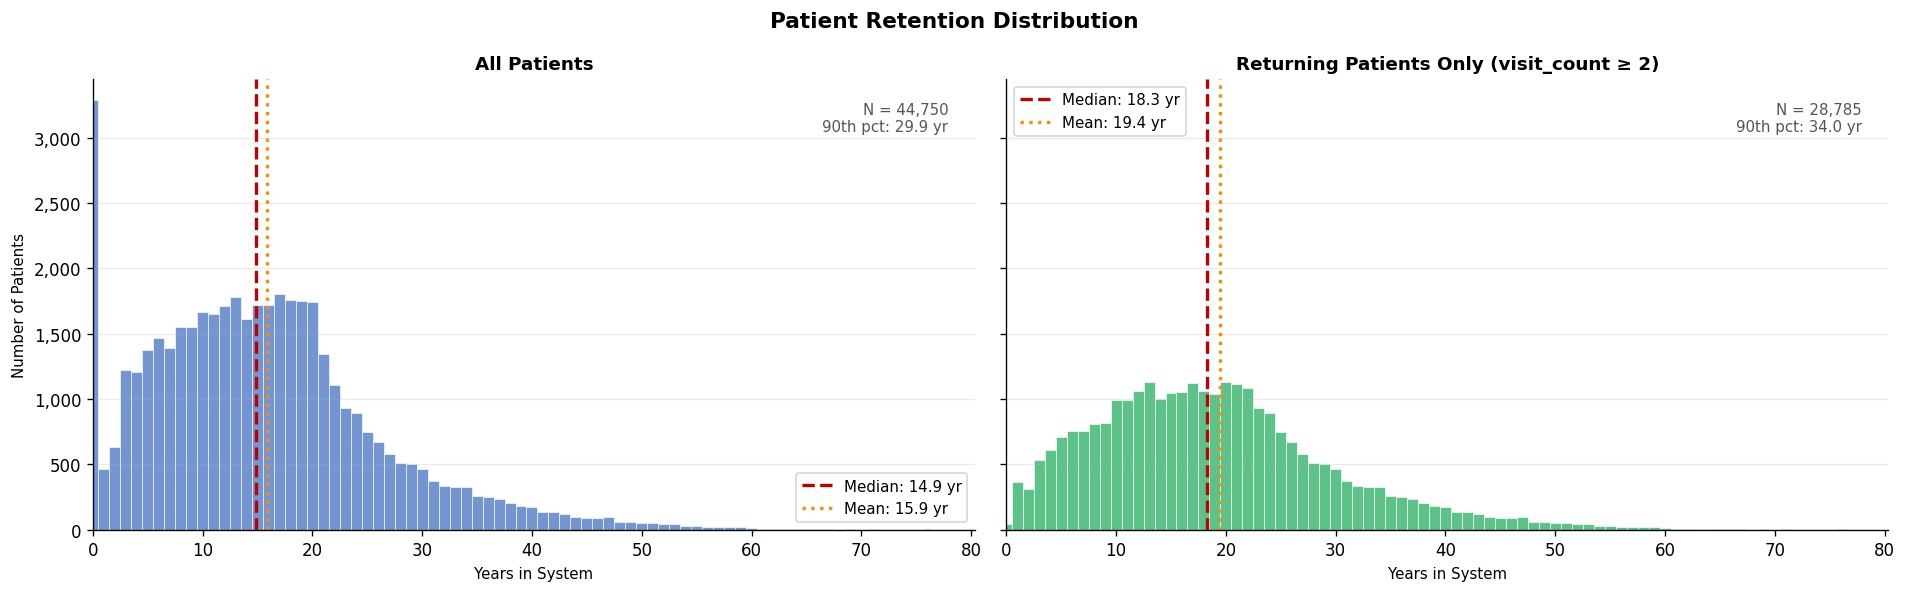

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

retention_all = metrics_70yr.get("days_in_system", [])
retention_screened = metrics_70yr.get("days_in_system_screened", [])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.patch.set_facecolor("white")

for ax, data, title, color in [
    (axes[0], retention_all, "All Patients", "#4472C4"),
    (axes[1], retention_screened, "Returning Patients Only (visit_count ≥ 2)", "#27AE60"),
]:
    if data:
        yrs = [d / 365 for d in data]
        max_yr = max(yrs)
        bins = np.arange(0, max_yr + 1, 1)  # 1-year bins, starting at 0
        ax.hist(yrs, bins=bins, color=color, alpha=0.75, edgecolor="white", lw=0.5,
                align="left")
        median_yrs = np.median(yrs)
        mean_yrs   = np.mean(yrs)
        p90        = np.percentile(yrs, 90)
        ax.axvline(median_yrs, color="#C00000", lw=2, ls="--",
                   label=f"Median: {median_yrs:.1f} yr")
        ax.axvline(mean_yrs, color="#FF8C00", lw=2, ls=":",
                   label=f"Mean: {mean_yrs:.1f} yr")
        ax.legend(fontsize=9)
        ax.text(0.97, 0.95, f"N = {len(data):,}\n90th pct: {p90:.1f} yr",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#555")
    else:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=12, color="#999")
    ax.set_xlabel("Years in System", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_xlim(left=0)

axes[0].set_ylabel("Number of Patients", fontsize=9)

plt.suptitle("Patient Retention Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(viz_path("retention"), dpi=150, bbox_inches="tight")
plt.show()

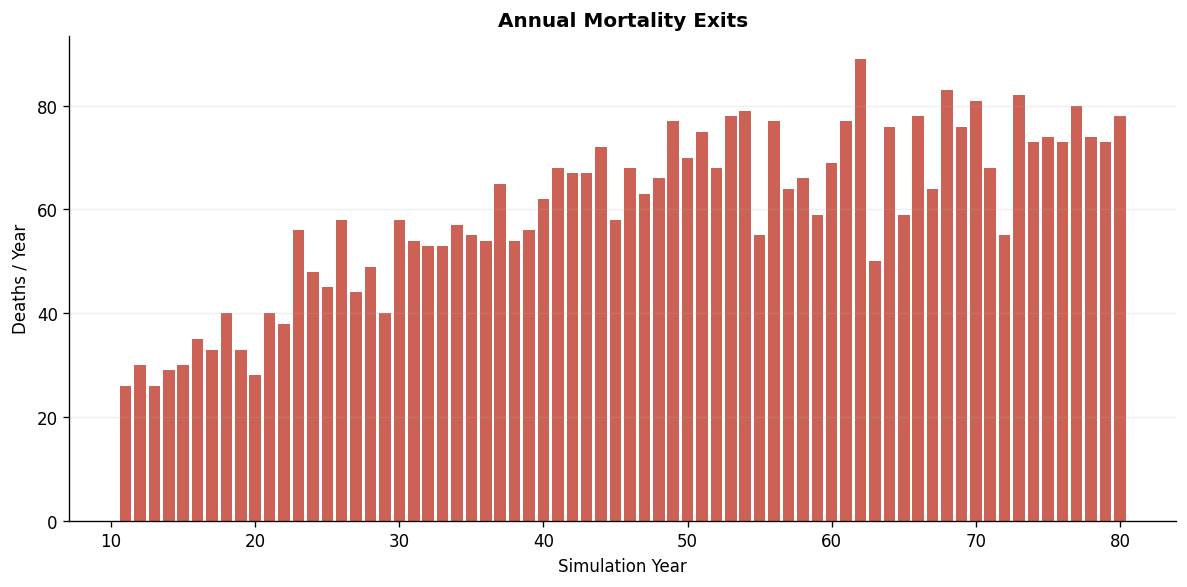

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get('year_checkpoints', []))
years = [c['year'] for c in chk]
years_ann = years[1:]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_mort = ann('cum_mortality')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

ax.bar(years_ann, ann_mort, color='#C0392B', alpha=0.8, width=0.8)

ax.set_title('Annual Mortality Exits', fontsize=12, fontweight='bold')
ax.set_xlabel('Simulation Year', fontsize=10)
ax.set_ylabel('Deaths / Year', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(viz_path('mortality'), dpi=150, bbox_inches='tight')
plt.show()


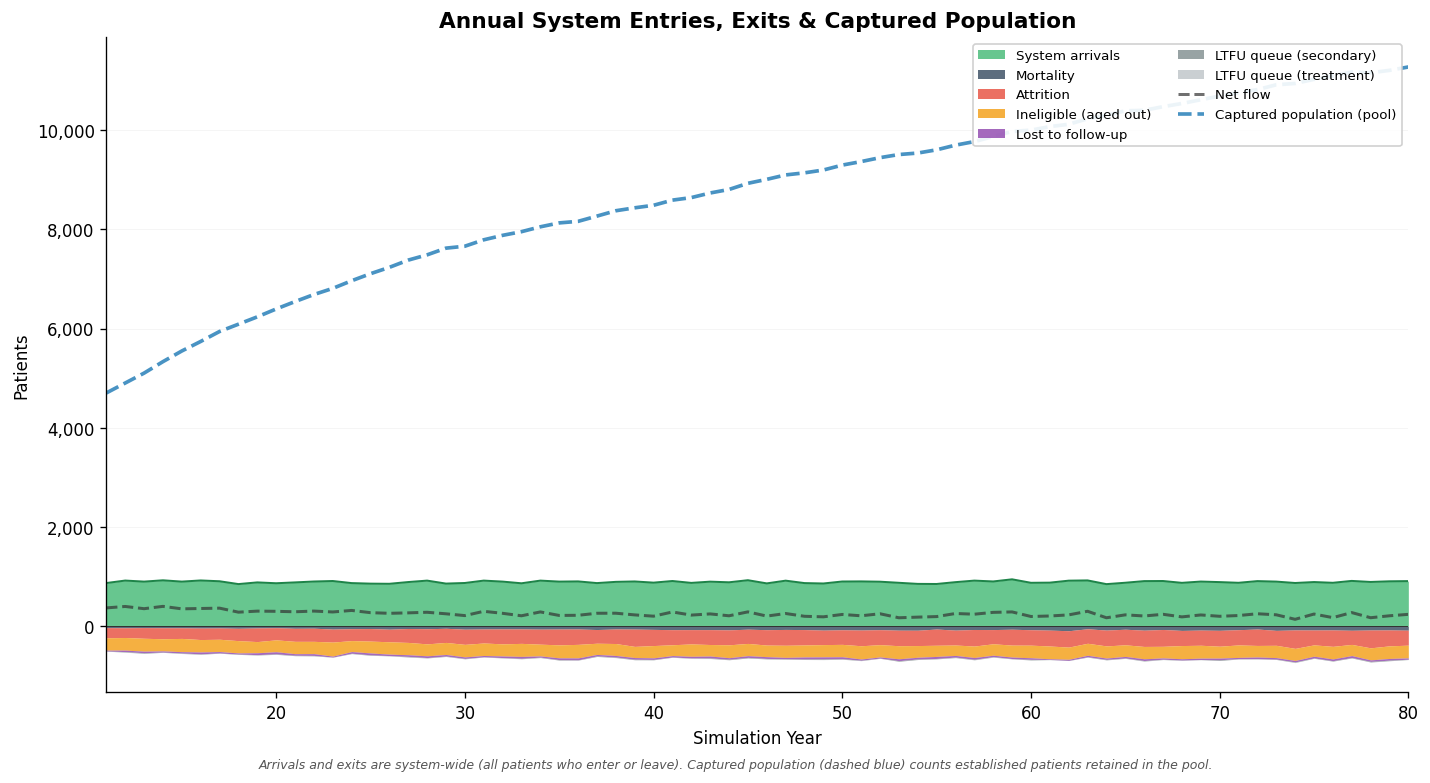

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))

if len(chk) < 2:
    print("Not enough checkpoints for entries/exits chart.")
else:
    years = [c["year"] for c in chk]
    years_ann = years[1:]

    # -- Annual entries (ALL system arrivals) ----------------------------------
    cum_arrivals = [c.get("cum_arrivals", 0) for c in chk]
    ann_arrivals = np.array([cum_arrivals[i] - cum_arrivals[i-1]
                             for i in range(1, len(cum_arrivals))], dtype=float)

    # -- Pool size (captured population) --------------------------------------
    pool_sizes = [c.get("pool_size", 0) for c in chk]
    pool_ann = np.array(pool_sizes[1:], dtype=float)

    # -- Annual exits by reason (ALL system exits) ----------------------------
    exit_spec = [
        ("mortality",            "Mortality",                   "#34495E"),
        ("attrition",            "Attrition",                   "#E74C3C"),
        ("ineligible",           "Ineligible (aged out)",       "#F39C12"),
        ("lost_to_followup",     "Lost to follow-up",           "#8E44AD"),
        ("ltfu_queue_secondary", "LTFU queue (secondary)",      "#7F8C8D"),
        ("ltfu_queue_treatment", "LTFU queue (treatment)",      "#BDC3C7"),
    ]

    all_reasons = set()
    for c in chk:
        all_reasons.update(c.get("cum_exits_by_reason", {}).keys())

    ann_exits = {}
    for reason, _, _ in exit_spec:
        if reason not in all_reasons:
            continue
        cum = [c.get("cum_exits_by_reason", {}).get(reason, 0) for c in chk]
        ann_exits[reason] = np.array([cum[i] - cum[i-1]
                                       for i in range(1, len(cum))], dtype=float)

    known = {r for r, _, _ in exit_spec}
    for reason in sorted(all_reasons - known):
        cum = [c.get("cum_exits_by_reason", {}).get(reason, 0) for c in chk]
        ann_exits[reason] = np.array([cum[i] - cum[i-1]
                                       for i in range(1, len(cum))], dtype=float)
        exit_spec.append((reason, reason.replace("_", " ").title(), "#95A5A6"))

    active_spec = [(r, l, c) for r, l, c in exit_spec if r in ann_exits]

    # -- Plot -----------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor("white")

    x = np.array(years_ann)

    # Entries: filled area above zero
    ax.fill_between(x, 0, ann_arrivals, color="#27AE60", alpha=0.7,
                    label="System arrivals", linewidth=0)
    ax.plot(x, ann_arrivals, color="#1E8449", lw=1.2)

    # Exits: stacked areas below zero
    bottom = np.zeros(len(x))
    for reason, label, color in active_spec:
        vals = ann_exits[reason]
        ax.fill_between(x, -(bottom + vals), -bottom,
                        color=color, alpha=0.8, label=label, linewidth=0)
        bottom += vals

    # Net flow line
    total_exits = sum(ann_exits[r] for r in ann_exits)
    net = ann_arrivals - total_exits
    ax.plot(x, net, color="#333", lw=1.8, ls="--", alpha=0.7, label="Net flow")

    # Pool size on SAME y-axis (dashed blue)
    ax.plot(x, pool_ann, color="#2980B9", lw=2.2, ls="--", alpha=0.85,
            label="Captured population (pool)")

    # Zero line
    ax.axhline(0, color="#333", lw=0.6)

    # Formatting
    ax.set_xlabel("Simulation Year", fontsize=10)
    ax.set_ylabel("Patients", fontsize=10)
    ax.set_title("Annual System Entries, Exits & Captured Population",
                 fontsize=13, fontweight="bold")

    ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2)
    ax.grid(axis="y", alpha=0.15, lw=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}"))
    ax.set_xlim(x[0], x[-1])

    # Footnote
    footnote = (
        "Arrivals and exits are system-wide (all patients who enter or leave). "
        "Captured population (dashed blue) counts established patients retained in the pool."
    )
    fig.text(0.5, 0.01, footnote, ha="center", fontsize=7.5,
             style="italic", color="#555", wrap=True)

    plt.subplots_adjust(bottom=0.10)
    plt.savefig(viz_path("entries_exits"), dpi=150, bbox_inches="tight")
    plt.show()


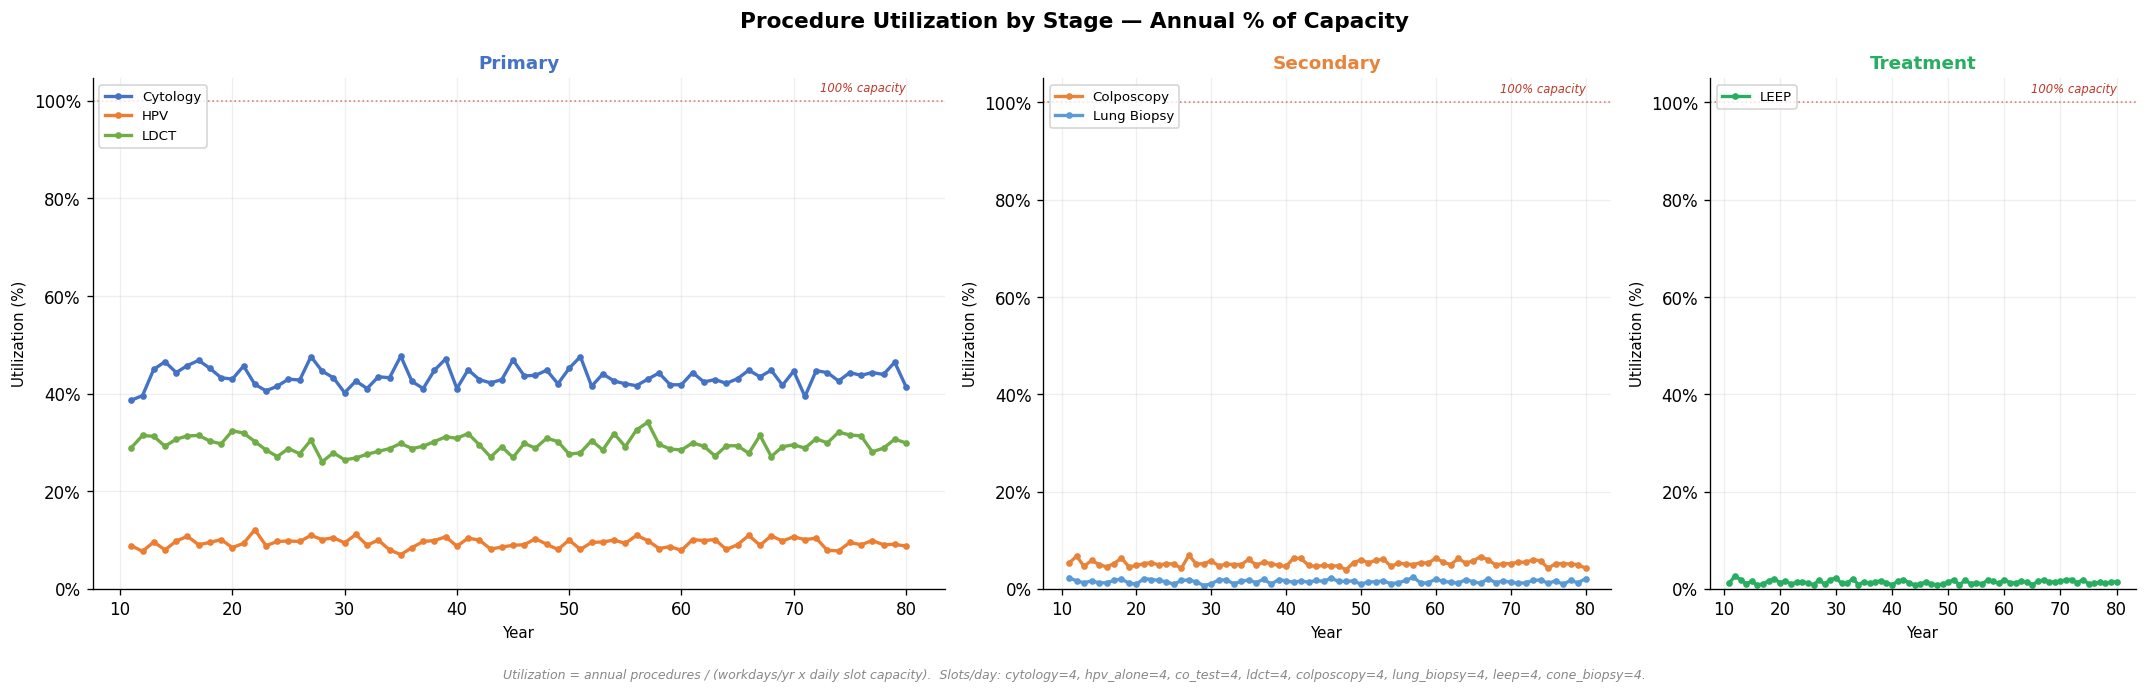

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]

workdays_per_year = int(365 * 5 / 7)

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

def utilization(ann_vals, proc):
    cap = cfg.CAPACITIES.get(proc, 1)
    return [100 * v / (workdays_per_year * cap) for v in ann_vals]

procs = {
    "Primary": [
        ("Cytology",    ann("cum_cytology"),    "cytology",    "#4472C4"),
        ("HPV",         ann("cum_hpv_alone"),   "hpv_alone",   "#ED7D31"),
        ("LDCT",        ann("cum_ldct"),        "ldct",        "#70AD47"),
    ],
    "Secondary": [
        ("Colposcopy",  ann("cum_colposcopy"),  "colposcopy",  "#E8833A"),
        ("Lung Biopsy", ann("cum_lung_biopsy"), "lung_biopsy", "#5B9BD5"),
    ],
    "Treatment": [
        ("LEEP",        ann("cum_leep"),        "leep",        "#27AE60"),
    ],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5),
                         gridspec_kw={"width_ratios": [3, 2, 1.5]})
fig.patch.set_facecolor("white")
fig.suptitle("Procedure Utilization by Stage — Annual % of Capacity",
             fontsize=13, fontweight="bold")

stage_colors = {"Primary": "#4472C4", "Secondary": "#E8833A", "Treatment": "#27AE60"}

for ax, (stage, proc_list) in zip(axes, procs.items()):
    for label, ann_vals, proc_key, color in proc_list:
        util = utilization(ann_vals, proc_key)
        ax.plot(years_ann, util, lw=2, color=color, label=label, marker="o", ms=3)

    ax.axhline(100, color="#C0392B", ls=":", lw=1, alpha=0.6)
    ax.text(years_ann[-1], 102, "100% capacity", ha="right", fontsize=7,
            color="#C0392B", fontstyle="italic")

    ax.set_title(stage, fontsize=11, fontweight="bold", color=stage_colors[stage])
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Utilization (%)", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.03,
         f"Utilization = annual procedures / (workdays/yr x daily slot capacity).  "
         f"Slots/day: {', '.join(f'{k}={v}' for k,v in cfg.CAPACITIES.items() if v > 0)}.",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("capacity_by_stage"), dpi=150, bbox_inches="tight")
plt.show()



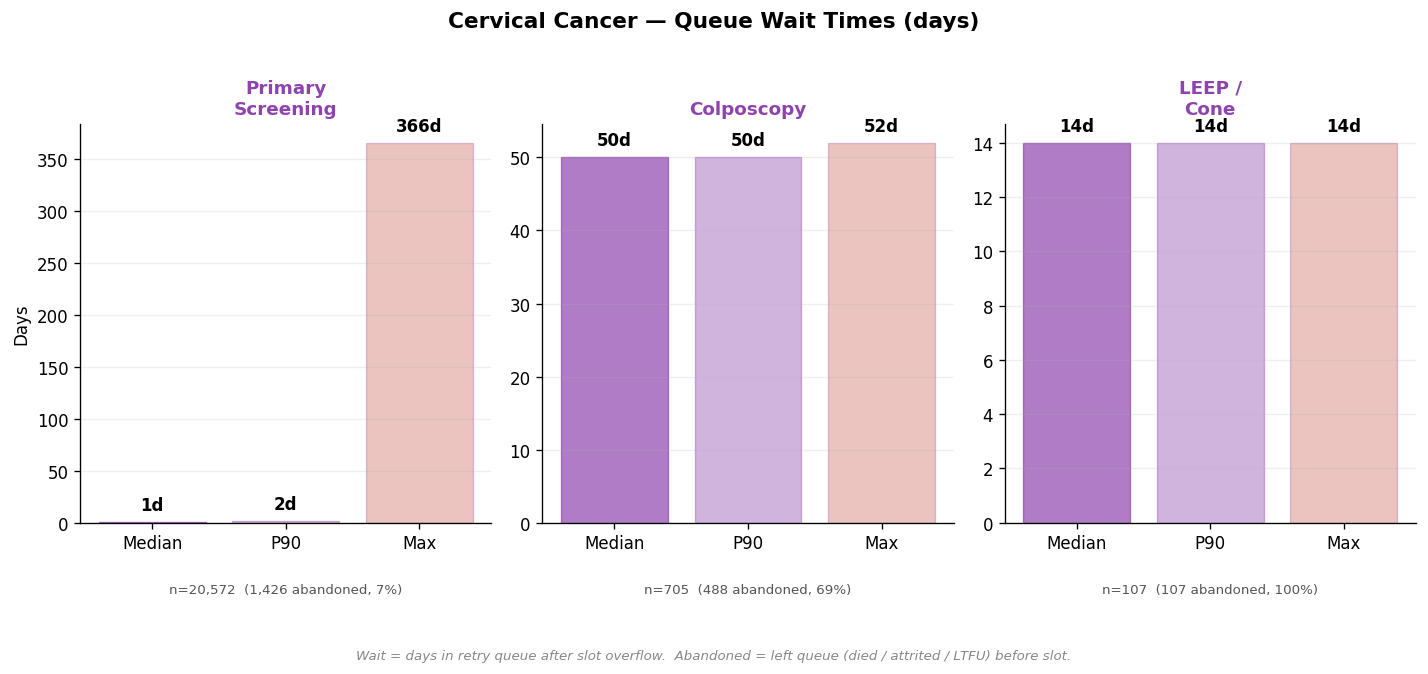

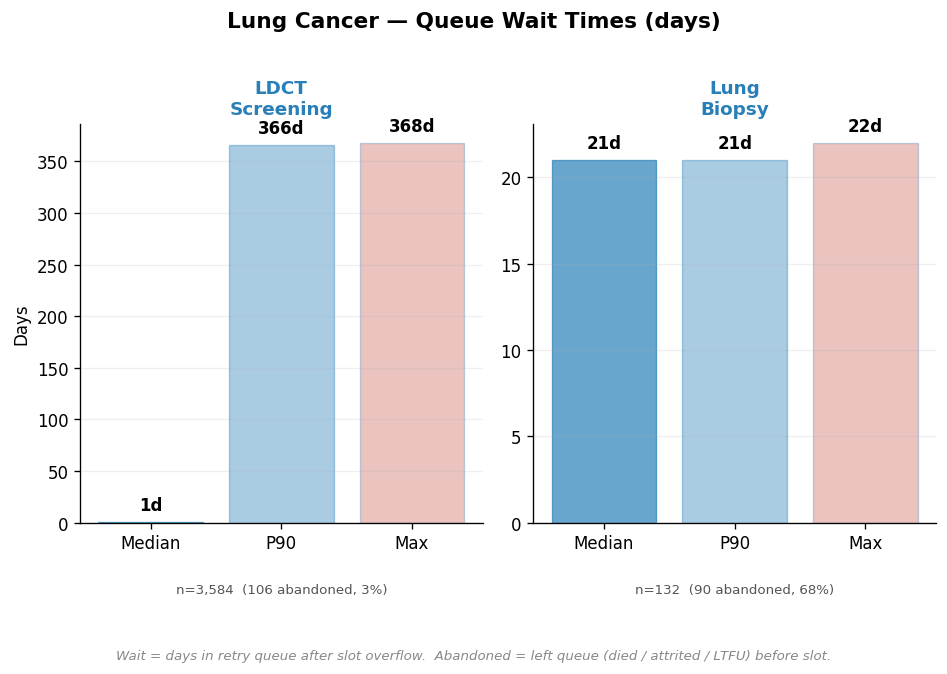

In [17]:
import matplotlib.pyplot as plt
import numpy as np

m   = metrics_70yr
wt  = m.get("wait_times", {})
wta = m.get("wait_times_abandoned", {})

# ── Procedure groups by cancer ──────────────────────────────────────────────
cerv_prim_s = wt.get("cytology", []) + wt.get("hpv_alone", []) + wt.get("co_test", [])
cerv_prim_a = wta.get("cytology", []) + wta.get("hpv_alone", []) + wta.get("co_test", [])

cancer_groups = {
    "cervical": {
        "title": "Cervical Cancer — Queue Wait Times (days)",
        "color": "#8E44AD",
        "procs": [
            ("Primary\nScreening", cerv_prim_s, cerv_prim_a),
            ("Colposcopy",         wt.get("colposcopy", []), wta.get("colposcopy", [])),
            ("LEEP /\nCone",       wt.get("leep", []) + wt.get("cone_biopsy", []),
                                   wta.get("leep", []) + wta.get("cone_biopsy", [])),
        ],
        "save": "wait_times_cervical",
    },
    "lung": {
        "title": "Lung Cancer — Queue Wait Times (days)",
        "color": "#2980B9",
        "procs": [
            ("LDCT\nScreening", wt.get("ldct", []), wta.get("ldct", [])),
            ("Lung\nBiopsy",    wt.get("lung_biopsy", []), wta.get("lung_biopsy", [])),
        ],
        "save": "wait_times_lung",
    },
}

def _plot_wait_group(group):
    procs = group["procs"]
    color = group["color"]
    n = len(procs)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]
    fig.patch.set_facecolor("white")
    fig.suptitle(group["title"], fontsize=13, fontweight="bold", y=1.02)

    for ax, (label, vs, va) in zip(axes, procs):
        has_data = bool(vs) or bool(va)
        if not has_data:
            ax.text(0.5, 0.5, "No overflow\n(all got slots)", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#888")
            ax.set_title(label, fontsize=11, fontweight="bold", color=color)
            ax.set_yticks([])
            ax.spines[["top", "right", "left"]].set_visible(False)
            continue

        arr = np.array(vs + va)
        med = np.median(arr)
        p90 = np.percentile(arr, 90)
        mx  = np.max(arr)
        n_total = len(arr)
        n_abandoned = len(va)
        pct_abandoned = 100 * n_abandoned / max(n_total, 1)

        alphas = [0.7, 0.4, 0.3]
        bars = ax.bar(["Median", "P90", "Max"], [med, p90, mx],
                      color=[color, color, "#C0392B"],
                      edgecolor=color, linewidth=0.8)
        for bar, a in zip(bars, alphas):
            bar.set_alpha(a)

        # Value labels
        ymax = ax.get_ylim()[1]
        for bar, val in zip(bars, [med, p90, mx]):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, val + ymax * 0.02,
                        f"{val:.0f}d", ha="center", va="bottom", fontsize=10, fontweight="bold")

        stats_text = f"n={n_total:,}  ({n_abandoned:,} abandoned, {pct_abandoned:.0f}%)"
        ax.text(0.5, -0.15, stats_text, ha="center", va="top", fontsize=8,
                color="#555", transform=ax.transAxes)

        ax.set_title(label, fontsize=11, fontweight="bold", color=color)
        ax.set_ylabel("Days" if ax == axes[0] else "")
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)

    fig.text(0.5, -0.06,
             "Wait = days in retry queue after slot overflow.  "
             "Abandoned = left queue (died / attrited / LTFU) before slot.",
             ha="center", fontsize=8, color="#888", fontstyle="italic")
    plt.tight_layout()
    plt.savefig(viz_path(group["save"]), dpi=150, bbox_inches="tight")
    plt.show()

for g in cancer_groups.values():
    _plot_wait_group(g)


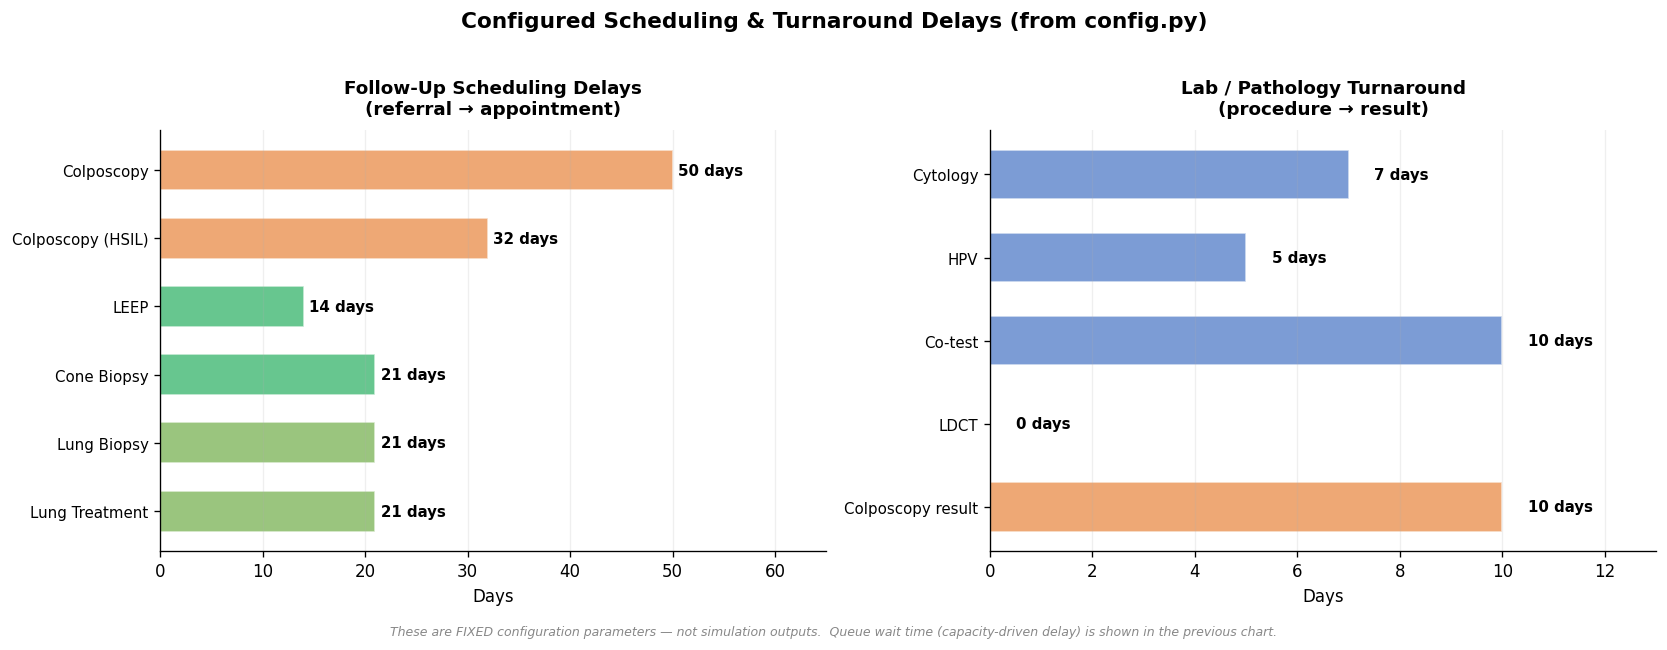

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import config as cfg

# ═════════════════════════════════════════════════════════════════════════════
# Follow-Up Scheduling Delays (FOLLOWUP_DELAY_DAYS)
#
# These are the CONFIGURED scheduling windows between a referral and the
# appointment date. They are NOT queue wait times — queue wait is the
# additional delay beyond this window when capacity is insufficient.
#
# Source: FOLLOWUP_DELAY_DAYS and TURNAROUND_DAYS in config.py
# ═════════════════════════════════════════════════════════════════════════════

# ── Gather configured delays ────────────────────────────────────────────────
followup = cfg.FOLLOWUP_DELAY_DAYS
turnaround = cfg.TURNAROUND_DAYS

# Group into categories
categories = [
    ('Follow-Up Scheduling Delays\n(referral → appointment)', [
        ('Colposcopy', followup.get('colposcopy', 0), '#E8833A'),
        ('Colposcopy (HSIL)', followup.get('colposcopy_hsil', 0), '#E8833A'),
        ('LEEP', followup.get('leep', 0), '#27AE60'),
        ('Cone Biopsy', followup.get('cone_biopsy', 0), '#27AE60'),
        ('Lung Biopsy', followup.get('lung_biopsy', 0), '#70AD47'),
        ('Lung Treatment', followup.get('lung_treatment', 0), '#70AD47'),
    ]),
    ('Lab / Pathology Turnaround\n(procedure → result)', [
        ('Cytology', turnaround.get('cytology', 0), '#4472C4'),
        ('HPV', turnaround.get('hpv_alone', 0), '#4472C4'),
        ('Co-test', turnaround.get('co_test', 0), '#4472C4'),
        ('LDCT', turnaround.get('ldct', 0), '#4472C4'),
        ('Colposcopy result', turnaround.get('colposcopy_result', 0), '#E8833A'),
    ]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

for ax, (title, items) in zip(axes, categories):
    labels = [it[0] for it in items]
    values = [it[1] for it in items]
    colors = [it[2] for it in items]

    y_pos = range(len(labels))
    bars = ax.barh(y_pos, values, color=colors, alpha=0.7, edgecolor='white', height=0.6)

    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val} days', va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Days', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, max(values) * 1.3 if values else 10)
    ax.invert_yaxis()

plt.suptitle(
    'Configured Scheduling & Turnaround Delays (from config.py)',
    fontsize=13, fontweight='bold', y=1.02,
)
fig.text(
    0.5, -0.02,
    'These are FIXED configuration parameters — not simulation outputs.  '
    'Queue wait time (capacity-driven delay) is shown in the previous chart.',
    ha='center', fontsize=7.5, color='#888', fontstyle='italic',
)
plt.tight_layout()
plt.savefig(viz_path('followup_delays'), dpi=150, bbox_inches='tight')
plt.show()

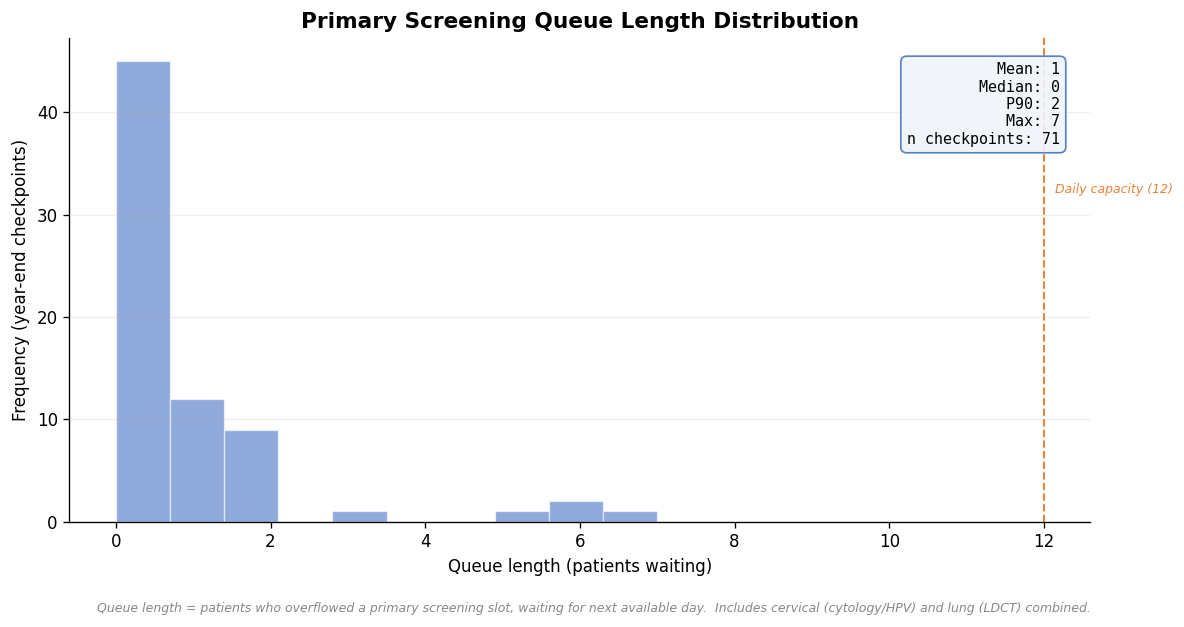

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

# =============================================================================
# Primary Screening Queue Length Distribution
#
# Distribution of how many patients are in the primary screening overflow
# queue at each year-end checkpoint (post-warmup).
# =============================================================================
m     = metrics_70yr
chk   = post_warmup_checkpoints(m.get("year_checkpoints", []))

# screening_queue_depth = total patients waiting for a primary screening slot
queue = [c.get("screening_queue_depth", 0) for c in chk]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")

if queue and max(queue) > 0:
    bins = max(10, min(30, len(set(queue))))
    ax.hist(queue, bins=bins, color="#4472C4", alpha=0.6, edgecolor="white", lw=0.8)

    mu  = np.mean(queue)
    med = np.median(queue)
    p90 = np.percentile(queue, 90)
    mx  = max(queue)

    stats_text = (
        f"Mean: {mu:,.0f}\n"
        f"Median: {med:,.0f}\n"
        f"P90: {p90:,.0f}\n"
        f"Max: {mx:,.0f}\n"
        f"n checkpoints: {len(queue)}"
    )
    ax.text(
        0.97, 0.95, stats_text,
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#F0F4FA",
                  edgecolor="#4472C4", alpha=0.9),
    )

    # Reference line: total primary capacity
    primary_cap = (
        cfg.CAPACITIES.get("cytology", 0)
        + cfg.CAPACITIES.get("hpv_alone", 0)
        + cfg.CAPACITIES.get("ldct", 0)
    )
    if primary_cap > 0 and primary_cap < mx * 3:
        ax.axvline(primary_cap, color="#E8833A", ls="--", lw=1.2)
        ax.text(primary_cap + mx * 0.02, ax.get_ylim()[1] * 0.7,
                f"Daily capacity ({primary_cap})",
                fontsize=7.5, color="#E8833A", fontstyle="italic", va="top")
else:
    ax.text(0.5, 0.5, "No queue overflow recorded\n(capacity always met demand)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11, color="#27AE60",
            fontweight="bold")

ax.set_xlabel("Queue length (patients waiting)", fontsize=10)
ax.set_ylabel("Frequency (year-end checkpoints)", fontsize=10)
ax.set_title("Primary Screening Queue Length Distribution",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
if queue and max(queue) > 0:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

fig.text(
    0.5, -0.03,
    "Queue length = patients who overflowed a primary screening slot, waiting for next available day.  "
    "Includes cervical (cytology/HPV) and lung (LDCT) combined.",
    ha="center", fontsize=7.5, color="#888", fontstyle="italic",
)

plt.tight_layout()
plt.savefig(viz_path("screening_queue_length_dist"), dpi=150, bbox_inches="tight")
plt.show()


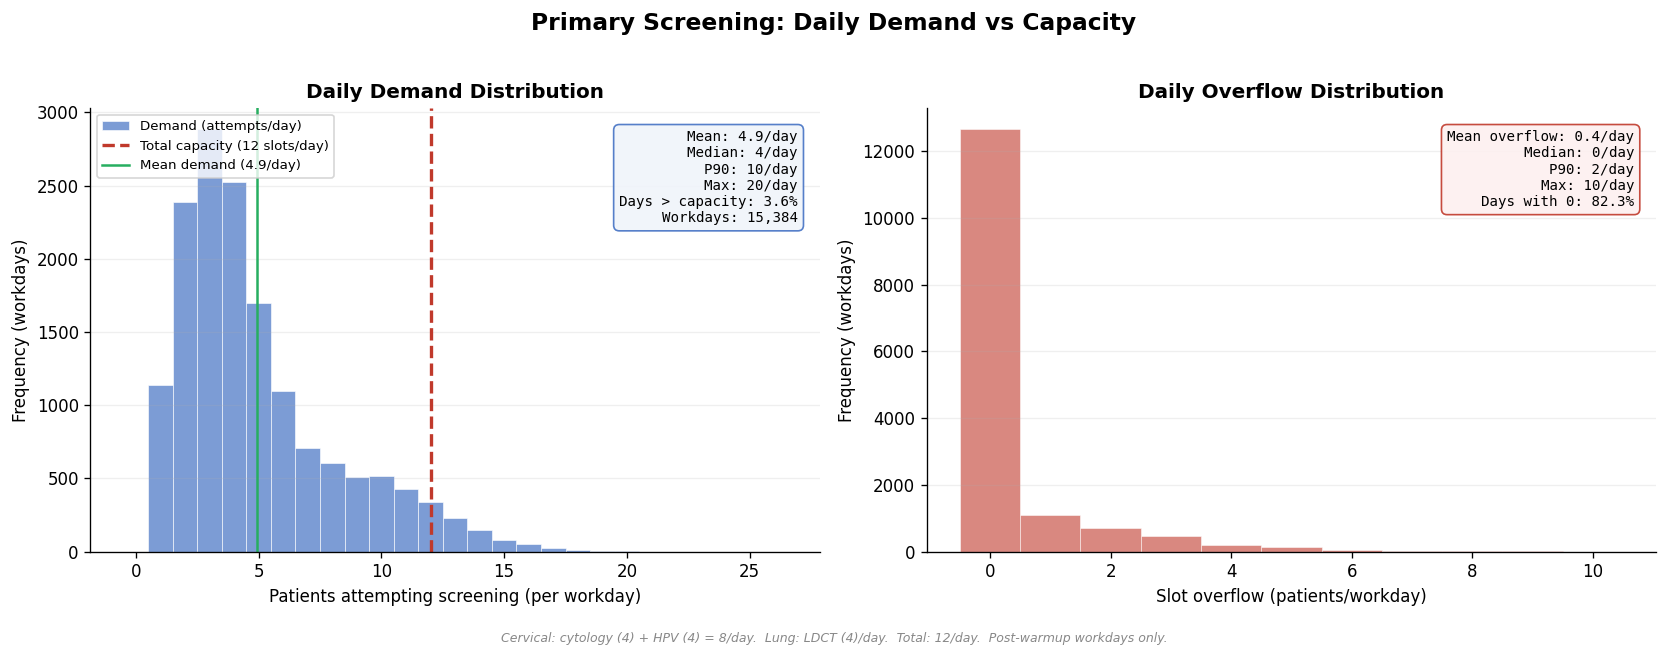

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

# =============================================================================
# Primary Screening: Daily Demand vs Capacity
# =============================================================================

m = metrics_70yr
raw = m.get("daily_screening_demand", [])

warmup_workdays = int(cfg.WARMUP_YEARS * 365 * 5 / 7)
data = raw[warmup_workdays:] if len(raw) > warmup_workdays else raw

if not data:
    print("No daily screening demand data recorded.")
else:
    demand   = np.array([d[0] for d in data])
    supply   = np.array([d[1] for d in data])
    overflow = np.array([d[2] for d in data])

    total_cap = (cfg.CAPACITIES.get("cytology", 0)
                 + cfg.CAPACITIES.get("hpv_alone", 0)
                 + cfg.CAPACITIES.get("ldct", 0))

    has_overflow = overflow.max() > 0

    if has_overflow:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    else:
        fig, ax1 = plt.subplots(figsize=(9, 5))

    fig.patch.set_facecolor("white")

    # -- Demand distribution -------------------------------------------------
    max_val = int(min(demand.max() * 1.3, total_cap * 2.5))
    bins = np.arange(-0.5, max_val + 1.5, 1)

    ax1.hist(demand, bins=bins, color="#4472C4", alpha=0.7,
             edgecolor="white", lw=0.5, label="Demand (attempts/day)")
    ax1.axvline(total_cap, color="#C0392B", ls="--", lw=2,
                label=f"Total capacity ({total_cap} slots/day)")
    ax1.axvline(np.mean(demand), color="#27AE60", ls="-", lw=1.5,
                label=f"Mean demand ({np.mean(demand):.1f}/day)")

    over_cap_pct = 100 * np.sum(demand > total_cap) / len(demand)
    ax1.text(
        0.97, 0.95,
        f"Mean: {np.mean(demand):.1f}/day\n"
        f"Median: {np.median(demand):.0f}/day\n"
        f"P90: {np.percentile(demand, 90):.0f}/day\n"
        f"Max: {demand.max():.0f}/day\n"
        f"Days > capacity: {over_cap_pct:.1f}%\n"
        f"Workdays: {len(demand):,}",
        transform=ax1.transAxes, ha="right", va="top",
        fontsize=8.5, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#F0F4FA",
                  edgecolor="#4472C4", alpha=0.9),
    )

    ax1.set_xlabel("Patients attempting screening (per workday)", fontsize=10)
    ax1.set_ylabel("Frequency (workdays)", fontsize=10)
    ax1.set_title("Daily Demand Distribution", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.grid(axis="y", alpha=0.2)
    ax1.spines[["top", "right"]].set_visible(False)

    # -- Overflow distribution (only if overflow exists) ---------------------
    if has_overflow:
        bins_o = np.arange(-0.5, overflow.max() + 1.5, 1)
        ax2.hist(overflow, bins=bins_o, color="#C0392B", alpha=0.6,
                 edgecolor="white", lw=0.5)
        zero_pct = 100 * np.sum(overflow == 0) / len(overflow)
        ax2.text(
            0.97, 0.95,
            f"Mean overflow: {np.mean(overflow):.1f}/day\n"
            f"Median: {np.median(overflow):.0f}/day\n"
            f"P90: {np.percentile(overflow, 90):.0f}/day\n"
            f"Max: {overflow.max():.0f}/day\n"
            f"Days with 0: {zero_pct:.1f}%",
            transform=ax2.transAxes, ha="right", va="top",
            fontsize=8.5, fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDF0F0",
                      edgecolor="#C0392B", alpha=0.9),
        )
        ax2.set_xlabel("Slot overflow (patients/workday)", fontsize=10)
        ax2.set_ylabel("Frequency (workdays)", fontsize=10)
        ax2.set_title("Daily Overflow Distribution", fontsize=12, fontweight="bold")
        ax2.grid(axis="y", alpha=0.2)
        ax2.spines[["top", "right"]].set_visible(False)

    cerv_cap = cfg.CAPACITIES.get("cytology", 0) + cfg.CAPACITIES.get("hpv_alone", 0)
    lung_cap = cfg.CAPACITIES.get("ldct", 0)

    fig.suptitle("Primary Screening: Daily Demand vs Capacity",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.text(
        0.5, -0.03,
        f"Cervical: cytology ({cfg.CAPACITIES.get('cytology',0)}) + "
        f"HPV ({cfg.CAPACITIES.get('hpv_alone',0)}) = {cerv_cap}/day.  "
        f"Lung: LDCT ({lung_cap})/day.  Total: {total_cap}/day.  "
        f"Post-warmup workdays only.",
        ha="center", fontsize=7.5, color="#888", fontstyle="italic",
    )

    plt.tight_layout()
    plt.savefig(viz_path("primary_demand_vs_capacity"), dpi=150, bbox_inches="tight")
    plt.show()


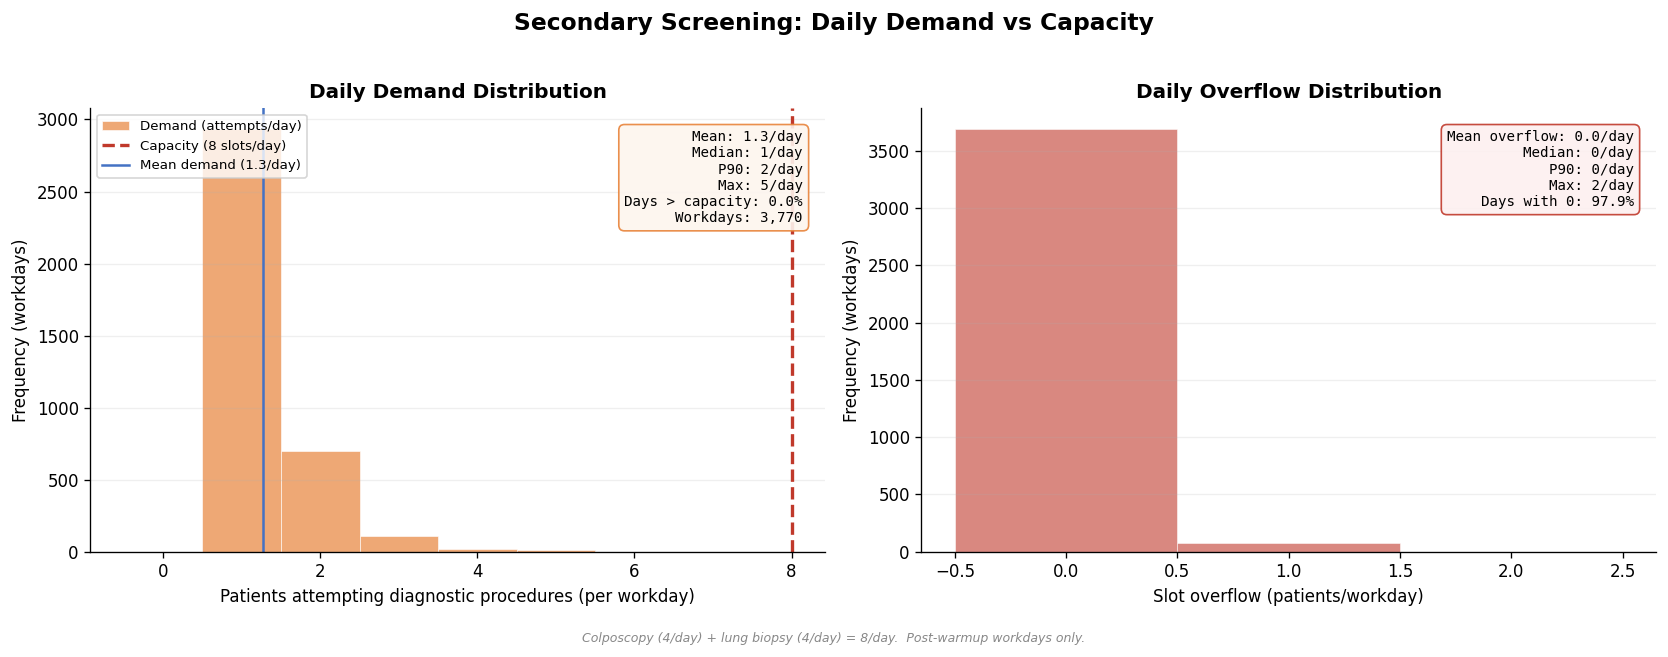

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

# =============================================================================
# Secondary Screening: Daily Demand vs Capacity
# Diagnostic/follow-up procedures: colposcopy, lung biopsy
# =============================================================================

m = metrics_70yr
raw = m.get("daily_secondary_demand", [])

warmup_workdays = int(cfg.WARMUP_YEARS * 365 * 5 / 7)
data = raw[warmup_workdays:] if len(raw) > warmup_workdays else raw

if not data:
    print("No daily secondary demand data recorded.")
else:
    demand   = np.array([d[0] for d in data])
    supply   = np.array([d[1] for d in data])
    overflow = np.array([d[2] for d in data])

    secondary_cap = (
        cfg.CAPACITIES.get("colposcopy", 0)
        + cfg.CAPACITIES.get("lung_biopsy", 0)
    )

    has_overflow = overflow.max() > 0

    if has_overflow:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    else:
        fig, ax1 = plt.subplots(figsize=(9, 5))

    fig.patch.set_facecolor("white")

    # -- Demand distribution -------------------------------------------------
    max_val = int(min(demand.max() * 1.3, secondary_cap * 2.5))
    bins = np.arange(-0.5, max_val + 1.5, 1)

    ax1.hist(demand, bins=bins, color="#E8833A", alpha=0.7,
             edgecolor="white", lw=0.5, label="Demand (attempts/day)")
    ax1.axvline(secondary_cap, color="#C0392B", ls="--", lw=2,
                label=f"Capacity ({secondary_cap} slots/day)")
    ax1.axvline(np.mean(demand), color="#4472C4", ls="-", lw=1.5,
                label=f"Mean demand ({np.mean(demand):.1f}/day)")

    over_cap_pct = 100 * np.sum(demand > secondary_cap) / len(demand)
    ax1.text(
        0.97, 0.95,
        f"Mean: {np.mean(demand):.1f}/day\n"
        f"Median: {np.median(demand):.0f}/day\n"
        f"P90: {np.percentile(demand, 90):.0f}/day\n"
        f"Max: {demand.max():.0f}/day\n"
        f"Days > capacity: {over_cap_pct:.1f}%\n"
        f"Workdays: {len(demand):,}",
        transform=ax1.transAxes, ha="right", va="top",
        fontsize=8.5, fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDF5EE",
                  edgecolor="#E8833A", alpha=0.9),
    )

    ax1.set_xlabel("Patients attempting diagnostic procedures (per workday)", fontsize=10)
    ax1.set_ylabel("Frequency (workdays)", fontsize=10)
    ax1.set_title("Daily Demand Distribution", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.grid(axis="y", alpha=0.2)
    ax1.spines[["top", "right"]].set_visible(False)

    # -- Overflow distribution (only if overflow exists) ---------------------
    if has_overflow:
        bins_o = np.arange(-0.5, overflow.max() + 1.5, 1)
        ax2.hist(overflow, bins=bins_o, color="#C0392B", alpha=0.6,
                 edgecolor="white", lw=0.5)
        zero_pct = 100 * np.sum(overflow == 0) / len(overflow)
        ax2.text(
            0.97, 0.95,
            f"Mean overflow: {np.mean(overflow):.1f}/day\n"
            f"Median: {np.median(overflow):.0f}/day\n"
            f"P90: {np.percentile(overflow, 90):.0f}/day\n"
            f"Max: {overflow.max():.0f}/day\n"
            f"Days with 0: {zero_pct:.1f}%",
            transform=ax2.transAxes, ha="right", va="top",
            fontsize=8.5, fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDF0F0",
                      edgecolor="#C0392B", alpha=0.9),
        )
        ax2.set_xlabel("Slot overflow (patients/workday)", fontsize=10)
        ax2.set_ylabel("Frequency (workdays)", fontsize=10)
        ax2.set_title("Daily Overflow Distribution", fontsize=12, fontweight="bold")
        ax2.grid(axis="y", alpha=0.2)
        ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Secondary Screening: Daily Demand vs Capacity",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.text(
        0.5, -0.03,
        f"Colposcopy ({cfg.CAPACITIES.get('colposcopy',0)}/day) + "
        f"lung biopsy ({cfg.CAPACITIES.get('lung_biopsy',0)}/day) = {secondary_cap}/day.  "
        f"Post-warmup workdays only.",
        ha="center", fontsize=7.5, color="#888", fontstyle="italic",
    )

    plt.tight_layout()
    plt.savefig(viz_path("secondary_demand_vs_capacity"), dpi=150, bbox_inches="tight")
    plt.show()


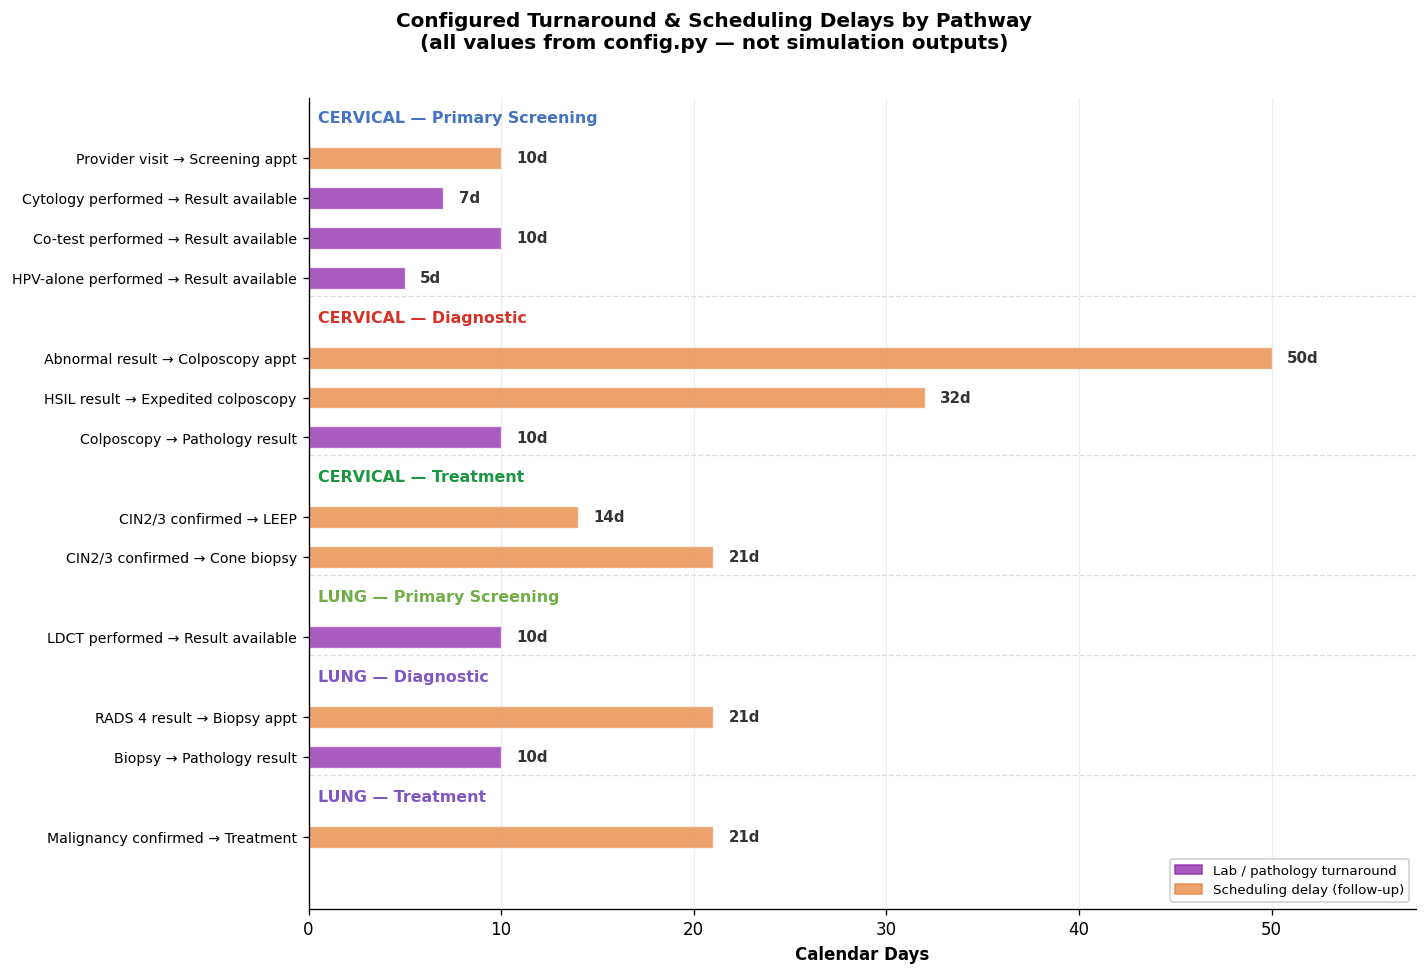

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import config as cfg

# ═════════════════════════════════════════════════════════════════════════════
# Turnaround & Scheduling Delays — by Pathway and Stage
# All values from config.py (TURNAROUND_DAYS & FOLLOWUP_DELAY_DAYS)
# ═════════════════════════════════════════════════════════════════════════════

td = cfg.TURNAROUND_DAYS
fd = cfg.FOLLOWUP_DELAY_DAYS

# Grouped by pathway → stage
# Each group: (section_title, color, [(label, days, delay_type), ...])
sections = [
    ("CERVICAL — Primary Screening", "#4472C4", [
        ("Provider visit → Screening appt",       td.get("provider_to_screening", 10), "scheduling"),
        ("Cytology performed → Result available",  td.get("cytology", 7),               "lab"),
        ("Co-test performed → Result available",   td.get("co_test", 10),               "lab"),
        ("HPV-alone performed → Result available", td.get("hpv_alone", 5),              "lab"),
    ]),
    ("CERVICAL — Diagnostic", "#D73027", [
        ("Abnormal result → Colposcopy appt",      fd.get("colposcopy", 50),            "scheduling"),
        ("HSIL result → Expedited colposcopy",     fd.get("colposcopy_hsil", 32),       "scheduling"),
        ("Colposcopy → Pathology result",          td.get("colposcopy_result", 10),     "lab"),
    ]),
    ("CERVICAL — Treatment", "#1a9641", [
        ("CIN2/3 confirmed → LEEP",               fd.get("leep", 14),                  "scheduling"),
        ("CIN2/3 confirmed → Cone biopsy",        fd.get("cone_biopsy", 21),           "scheduling"),
    ]),
    ("LUNG — Primary Screening", "#70AD47", [
        ("LDCT performed → Result available",      td.get("ldct_notification", 5),      "lab"),
    ]),
    ("LUNG — Diagnostic", "#7E57C2", [
        ("RADS 4 result → Biopsy appt",           fd.get("lung_biopsy", 21),           "scheduling"),
        ("Biopsy → Pathology result",             td.get("lung_biopsy_result", 10),    "lab"),
    ]),
    ("LUNG — Treatment", "#7E57C2", [
        ("Malignancy confirmed → Treatment",      fd.get("lung_treatment", 21),        "scheduling"),
    ]),
]

# ── Build flat list with y-positions ─────────────────────────────────────────
# Each section header gets its own row (no bar) so nothing overlaps.
rows = []       # (label, days, delay_type, color)
y_positions = []
y_cursor = 0
section_header_positions = []  # (y_pos, title, color)

for sec_idx, (title, color, items) in enumerate(sections):
    # Section header occupies its own y-position (no bar drawn)
    section_header_positions.append((y_cursor, title, color))
    y_cursor += 1
    for label, days, dtype in items:
        rows.append((label, days, dtype, color))
        y_positions.append(y_cursor)
        y_cursor += 1

n = len(rows)
y_max = y_cursor
# Flip so first section appears at top
y_positions = [y_max - yp for yp in y_positions]
section_header_positions = [(y_max - yp, t, c) for yp, t, c in section_header_positions]

# Delay type → bar color mapping
dtype_colors = {"lab": "#8E24AA", "scheduling": "#E8833A"}

fig, ax = plt.subplots(figsize=(12, max(8, y_max * 0.42)))
fig.patch.set_facecolor("white")

max_days = max(r[1] for r in rows)

for i, (label, days, dtype, sec_color) in enumerate(rows):
    yp = y_positions[i]
    bar_color = dtype_colors.get(dtype, sec_color)
    ax.barh(yp, days, color=bar_color, height=0.55, edgecolor="white",
            linewidth=0.8, alpha=0.75)
    # Value label — always outside bar to avoid overlap
    ax.text(days + 0.8, yp, f"{days}d", va="center", ha="left",
            fontsize=9, fontweight="bold", color="#333")

# Y-axis: bar labels only
ax.set_yticks(y_positions)
ax.set_yticklabels([r[0] for r in rows], fontsize=8.5)

# Section headers — rendered as bold colored text at their own y-position
for yp, title, color in section_header_positions:
    ax.text(0.5, yp, title, ha="left", va="center",
            fontsize=9.5, fontweight="bold", color=color)

# Section divider lines between groups
for i in range(1, len(section_header_positions)):
    sep_y = section_header_positions[i][0] + 0.55
    ax.axhline(sep_y, color="#ddd", lw=0.8, ls="--")

ax.set_xlabel("Calendar Days", fontsize=10, fontweight="bold")
ax.set_xlim(0, max_days * 1.15)
ax.set_ylim(-0.8, y_max + 0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

# Legend
legend_patches = [
    mpatches.Patch(color="#8E24AA", alpha=0.75, label="Lab / pathology turnaround"),
    mpatches.Patch(color="#E8833A", alpha=0.75, label="Scheduling delay (follow-up)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.9)

fig.suptitle(
    "Configured Turnaround & Scheduling Delays by Pathway\n"
    "(all values from config.py — not simulation outputs)",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(viz_path("turnaround_delays"), dpi=150, bbox_inches="tight")
plt.show()

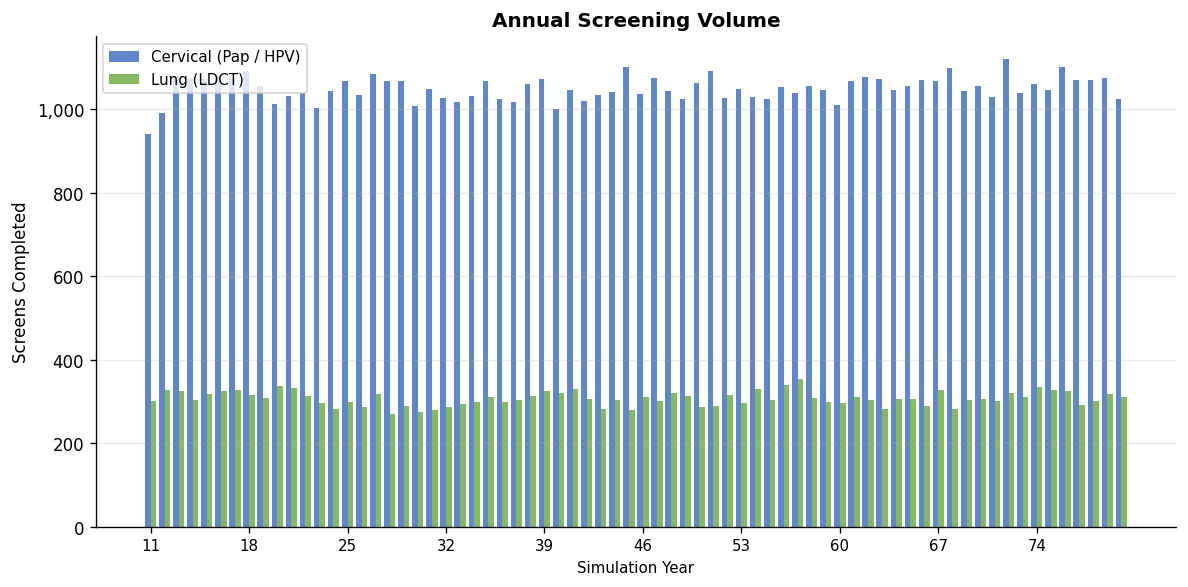

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]  # annual diffs have N-1 values


def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_cerv = ann("cum_cervical")
ann_lung = ann("cum_lung")
years_ss = years_ann
cerv_ss = ann_cerv
lung_ss = ann_lung

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
x     = np.arange(len(years_ss))
bar_w = 0.4
ax.bar(x - bar_w/2, cerv_ss, bar_w, color="#4472C4", alpha=0.85, label="Cervical (Pap / HPV)")
ax.bar(x + bar_w/2, lung_ss, bar_w, color="#70AD47", alpha=0.85, label="Lung (LDCT)")
tick_step = max(1, len(years_ss) // 10)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([str(y) for y in years_ss[::tick_step]], fontsize=9)
ax.set_xlabel("Simulation Year", fontsize=9)
ax.set_ylabel("Screens Completed", fontsize=10)
ax.set_title("Annual Screening Volume", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("annual_screening_volume"), dpi=150, bbox_inches="tight")
plt.show()

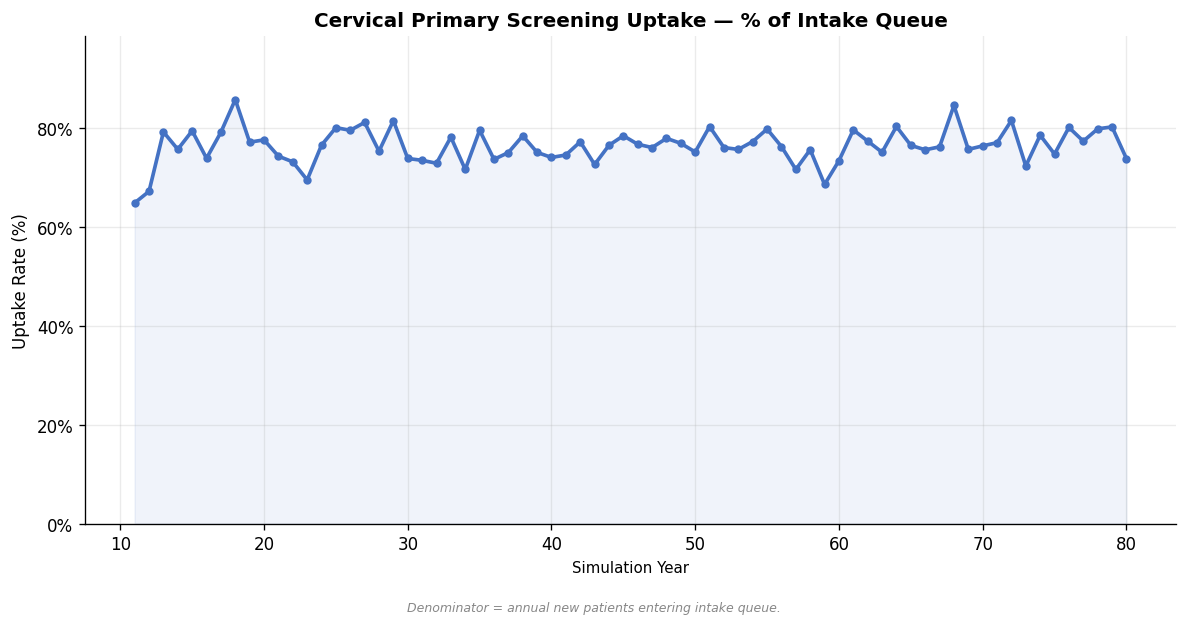

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get('year_checkpoints', []))

if len(chk) < 2:
    print('Not enough checkpoint data for cervical uptake chart.')
else:
    years = [c['year'] for c in chk]
    years_ann = years[1:]

    cum_cerv = [c.get('cum_cervical_est', 0) for c in chk]
    ann_cerv = [cum_cerv[i] - cum_cerv[i-1] for i in range(1, len(cum_cerv))]

    cum_intake = [c.get('cum_intake_total', 0) for c in chk]
    ann_intake = [max(cum_intake[i] - cum_intake[i-1], 1) for i in range(1, len(cum_intake))]

    uptake = [100 * s / d for s, d in zip(ann_cerv, ann_intake)]

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')

    ax.plot(years_ann, uptake, color='#4472C4', lw=2.2, marker='o', markersize=4)
    ax.fill_between(years_ann, uptake, alpha=0.08, color='#4472C4')

    ax.set_ylim(0, max(max(uptake) * 1.15, 10) if uptake else 10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Simulation Year', fontsize=9)
    ax.set_ylabel('Uptake Rate (%)', fontsize=10)
    ax.set_title('Cervical Primary Screening Uptake — % of Intake Queue',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

    fig.text(0.5, -0.03,
             'Denominator = annual new patients entering intake queue.',
             ha='center', fontsize=7.5, color='#888', fontstyle='italic')

    plt.tight_layout()
    plt.savefig(viz_path('cervical_uptake'), dpi=150, bbox_inches='tight')
    plt.show()


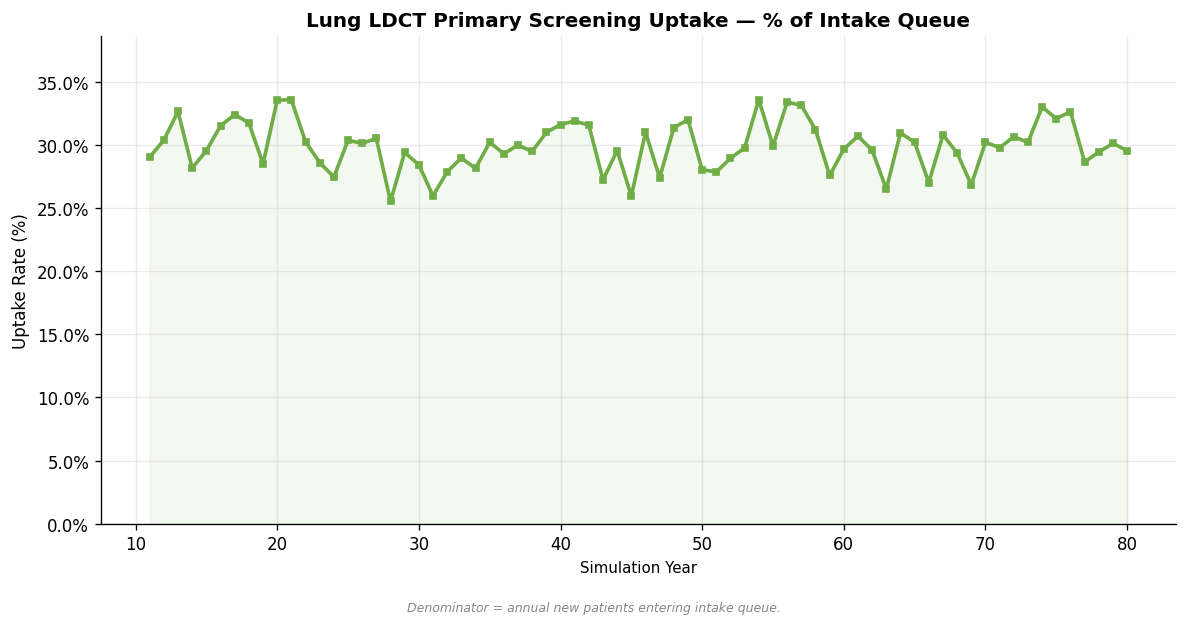

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get('year_checkpoints', []))

if len(chk) < 2:
    print('Not enough checkpoint data for lung uptake chart.')
else:
    years = [c['year'] for c in chk]
    years_ann = years[1:]

    cum_lung = [c.get('cum_lung_est', 0) for c in chk]
    ann_lung = [cum_lung[i] - cum_lung[i-1] for i in range(1, len(cum_lung))]

    cum_intake = [c.get('cum_intake_total', 0) for c in chk]
    ann_intake = [max(cum_intake[i] - cum_intake[i-1], 1) for i in range(1, len(cum_intake))]

    uptake = [100 * s / d for s, d in zip(ann_lung, ann_intake)]

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')

    ax.plot(years_ann, uptake, color='#70AD47', lw=2.2, marker='s', markersize=4)
    ax.fill_between(years_ann, uptake, alpha=0.08, color='#70AD47')

    ax.set_ylim(0, max(max(uptake) * 1.15, 10) if uptake else 10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Simulation Year', fontsize=9)
    ax.set_ylabel('Uptake Rate (%)', fontsize=10)
    ax.set_title('Lung LDCT Primary Screening Uptake — % of Intake Queue',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

    fig.text(0.5, -0.03,
             'Denominator = annual new patients entering intake queue.',
             ha='center', fontsize=7.5, color='#888', fontstyle='italic')

    plt.tight_layout()
    plt.savefig(viz_path('lung_uptake'), dpi=150, bbox_inches='tight')
    plt.show()


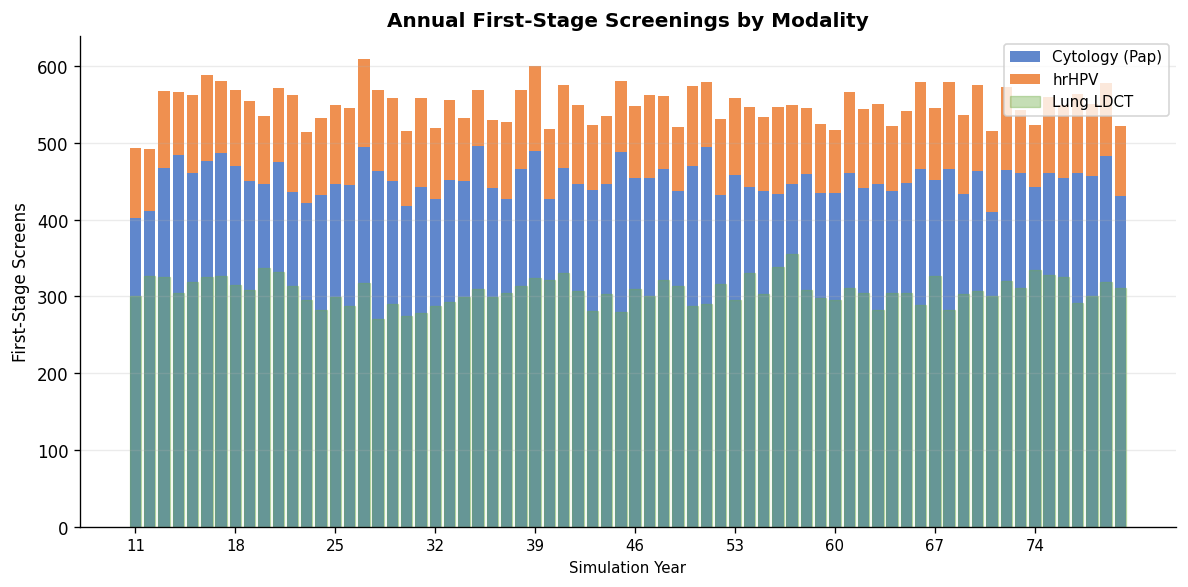

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]  # annual diffs have N-1 values


def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

# Annual first-stage screenings by test modality (skip warmup)
ann_cyto = ann("cum_cytology")
ann_hpv  = ann("cum_hpv_alone")
ann_ldct = ann("cum_ldct")
years_ss = years_ann

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
x = np.arange(len(years_ss))

# Stacked cervical: cytology on bottom, hrHPV on top
ax.bar(x, ann_cyto, color="#4472C4", alpha=0.85, label="Cytology (Pap)")
ax.bar(x, ann_hpv, bottom=ann_cyto, color="#ED7D31", alpha=0.85, label="hrHPV")
# LDCT as separate grouped bar
ax.bar(x, ann_ldct, color="#70AD47", alpha=0.40, edgecolor="#70AD47", lw=0.8, label="Lung LDCT")

tick_step = max(1, len(years_ss) // 10)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([str(y) for y in years_ss[::tick_step]], fontsize=9)
ax.set_xlabel("Simulation Year", fontsize=9)
ax.set_ylabel("First-Stage Screens", fontsize=10)
ax.set_title("Annual First-Stage Screenings by Modality", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("first_stage_screenings"), dpi=150, bbox_inches="tight")
plt.show()

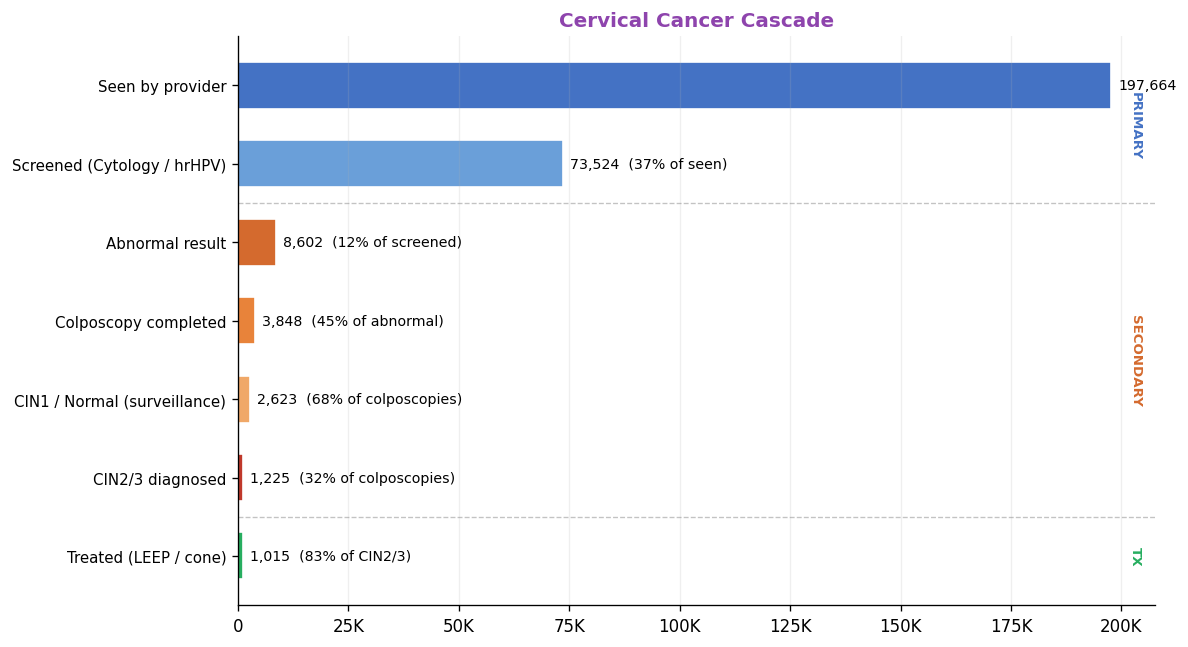

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

m = metrics_70yr

# =============================================================================
# Cervical Cancer Cascade -- Primary -> Secondary -> Treatment
# =============================================================================

total_seen    = m["n_patients"]
cerv_screened = m["n_screened"]["cervical"]
cerv_all      = dict(m.get("cervical_results", {}))
cerv_abnormal = sum(v for k, v in cerv_all.items() if k not in ("NORMAL", "HPV_NEGATIVE"))
colposcopies  = m["n_colposcopy"]
cin_results   = dict(m.get("colposcopy_results", {}))
cin1          = cin_results.get("CIN1", 0) + cin_results.get("NORMAL", 0)
cin2_plus     = cin_results.get("CIN2", 0) + cin_results.get("CIN3", 0)
tx            = dict(m.get("n_treatment", {}))
cerv_treated  = tx.get("leep", 0) + tx.get("cone_biopsy", 0)

# Labels, values, correct denominators for each percentage
labels = [
    "Seen by provider",
    "Screened (Cytology / hrHPV)",
    "Abnormal result",
    "Colposcopy completed",
    "CIN1 / Normal (surveillance)",
    "CIN2/3 diagnosed",
    "Treated (LEEP / cone)",
]
vals = [total_seen, cerv_screened, cerv_abnormal, colposcopies, cin1, cin2_plus, cerv_treated]

# Each entry: (denominator_index, denominator_label) for the percentage
# Percentages are relative to the clinically appropriate parent step
pct_refs = [
    None,                        # Seen -- no percentage
    (0, "seen"),                 # Screened / Seen
    (1, "screened"),             # Abnormal / Screened
    (2, "abnormal"),             # Colposcopy / Abnormal
    (3, "colposcopies"),         # CIN1+Normal / Colposcopy
    (3, "colposcopies"),         # CIN2/3 / Colposcopy (NOT % of CIN1)
    (5, "CIN2/3"),               # Treated / CIN2/3
]

section_colors = [
    "#4472C4", "#6A9FD9",        # Primary
    "#D46A2E", "#E8833A",        # Secondary trigger + diagnostic
    "#F0A868", "#C0392B",        # Secondary results
    "#27AE60",                   # Treatment
]

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")

bars = ax.barh(range(len(labels)), vals, color=section_colors, edgecolor="white", height=0.6)

for i, (bar, val) in enumerate(zip(bars, vals)):
    ref = pct_refs[i]
    if ref is not None:
        denom_idx, denom_label = ref
        denom = vals[denom_idx]
        pct = 100 * val / max(denom, 1)
        pct_str = f"  ({pct:.0f}% of {denom_label})"
    else:
        pct_str = ""
    ax.text(bar.get_width() + max(vals) * 0.008, bar.get_y() + bar.get_height() / 2,
            f"{val:,}{pct_str}", va="center", ha="left", fontsize=8.5)

ax.axhline(y=1.5, color="#888", ls="--", lw=0.8, alpha=0.5)
ax.axhline(y=5.5, color="#888", ls="--", lw=0.8, alpha=0.5)

ax.text(max(vals) * 1.02, 0.5, "PRIMARY", fontsize=8, color="#4472C4",
        fontweight="bold", va="center", rotation=-90)
ax.text(max(vals) * 1.02, 3.5, "SECONDARY", fontsize=8, color="#D46A2E",
        fontweight="bold", va="center", rotation=-90)
ax.text(max(vals) * 1.02, 6.0, "TX", fontsize=8, color="#27AE60",
        fontweight="bold", va="center", rotation=-90)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_title("Cervical Cancer Cascade", fontsize=12, fontweight="bold", color="#8E44AD")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("cervical_cascade"), dpi=150, bbox_inches="tight")
plt.show()


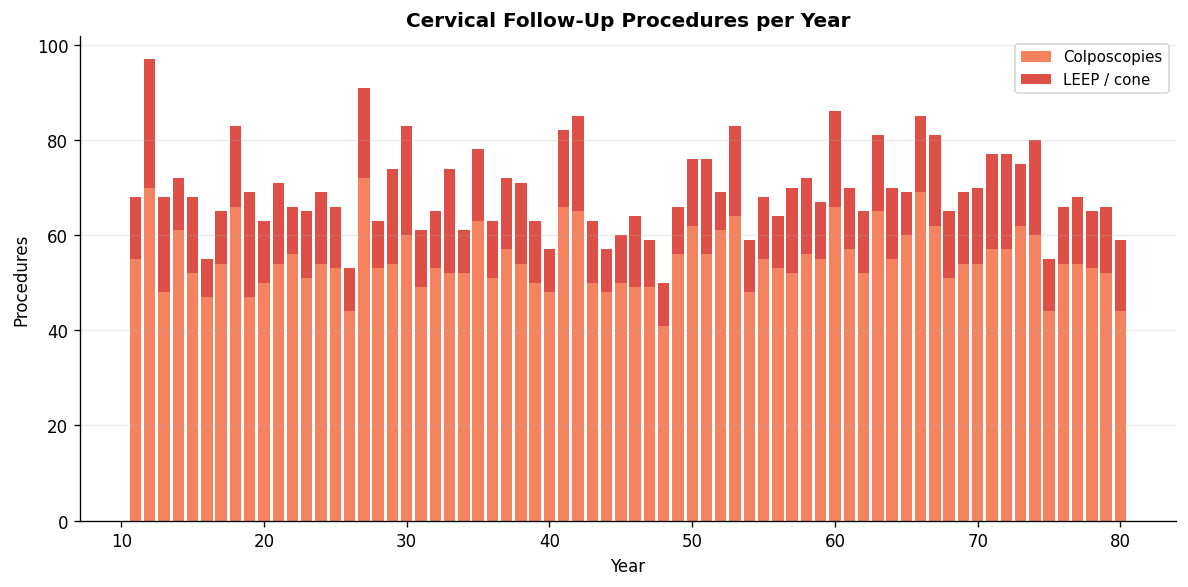

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]  # annual diffs have N-1 values

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_colp = ann("cum_colposcopy")
ann_leep = ann("cum_leep")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(years_ann, ann_colp, color="#f46d43", alpha=0.85, label="Colposcopies", width=0.8)
ax.bar(years_ann, ann_leep, color="#d73027", alpha=0.85, label="LEEP / cone", width=0.8, bottom=ann_colp)
ax.set_title("Cervical Follow-Up Procedures per Year", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("cervical_followup"), dpi=150, bbox_inches="tight")
plt.show()


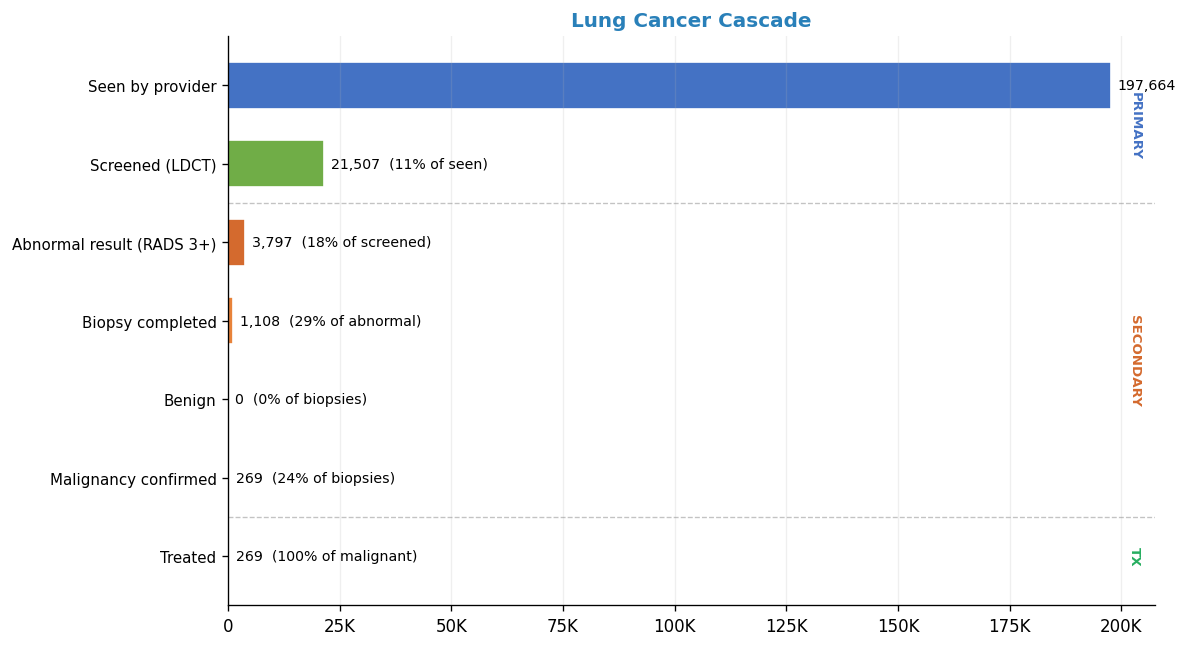

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

m = metrics_70yr

# =============================================================================
# Lung Cancer Cascade -- Primary -> Secondary -> Treatment
# =============================================================================

total_seen    = m["n_patients"]
lung_screened = m["n_screened"]["lung"]
rads          = dict(m.get("lung_rads_distribution", {}))
lung_abnormal = sum(v for k, v in rads.items() if k in ("RADS_3", "RADS_4A", "RADS_4B_4X"))
lung_biopsy   = m.get("lung_biopsy_completed", 0)
lung_benign   = m.get("lung_benign_confirmed", 0)
lung_malig    = m.get("lung_malignancy_confirmed", 0)
lung_treated  = m.get("lung_treatment_given", 0)

# Labels, values, correct denominators for each percentage
labels = [
    "Seen by provider",
    "Screened (LDCT)",
    "Abnormal result (RADS 3+)",
    "Biopsy completed",
    "Benign",
    "Malignancy confirmed",
    "Treated",
]
vals = [total_seen, lung_screened, lung_abnormal, lung_biopsy, lung_benign, lung_malig, lung_treated]

# Each entry: (denominator_index, denominator_label) for the percentage
pct_refs = [
    None,                        # Seen -- no percentage
    (0, "seen"),                 # Screened / Seen
    (1, "screened"),             # Abnormal / Screened
    (2, "abnormal"),             # Biopsy / Abnormal
    (3, "biopsies"),             # Benign / Biopsy
    (3, "biopsies"),             # Malignant / Biopsy (NOT % of benign)
    (5, "malignant"),            # Treated / Malignant
]

section_colors = [
    "#4472C4", "#70AD47",        # Primary
    "#D46A2E", "#E8833A",        # Secondary trigger + diagnostic
    "#F0A868", "#C0392B",        # Secondary results
    "#27AE60",                   # Treatment
]

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")

bars = ax.barh(range(len(labels)), vals, color=section_colors, edgecolor="white", height=0.6)

for i, (bar, val) in enumerate(zip(bars, vals)):
    ref = pct_refs[i]
    if ref is not None:
        denom_idx, denom_label = ref
        denom = vals[denom_idx]
        pct = 100 * val / max(denom, 1)
        pct_str = f"  ({pct:.0f}% of {denom_label})"
    else:
        pct_str = ""
    ax.text(bar.get_width() + max(vals) * 0.008, bar.get_y() + bar.get_height() / 2,
            f"{val:,}{pct_str}", va="center", ha="left", fontsize=8.5)

ax.axhline(y=1.5, color="#888", ls="--", lw=0.8, alpha=0.5)
ax.axhline(y=5.5, color="#888", ls="--", lw=0.8, alpha=0.5)

ax.text(max(vals) * 1.02, 0.5, "PRIMARY", fontsize=8, color="#4472C4",
        fontweight="bold", va="center", rotation=-90)
ax.text(max(vals) * 1.02, 3.5, "SECONDARY", fontsize=8, color="#D46A2E",
        fontweight="bold", va="center", rotation=-90)
ax.text(max(vals) * 1.02, 6.0, "TX", fontsize=8, color="#27AE60",
        fontweight="bold", va="center", rotation=-90)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_title("Lung Cancer Cascade", fontsize=12, fontweight="bold", color="#2980B9")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("lung_cascade"), dpi=150, bbox_inches="tight")
plt.show()


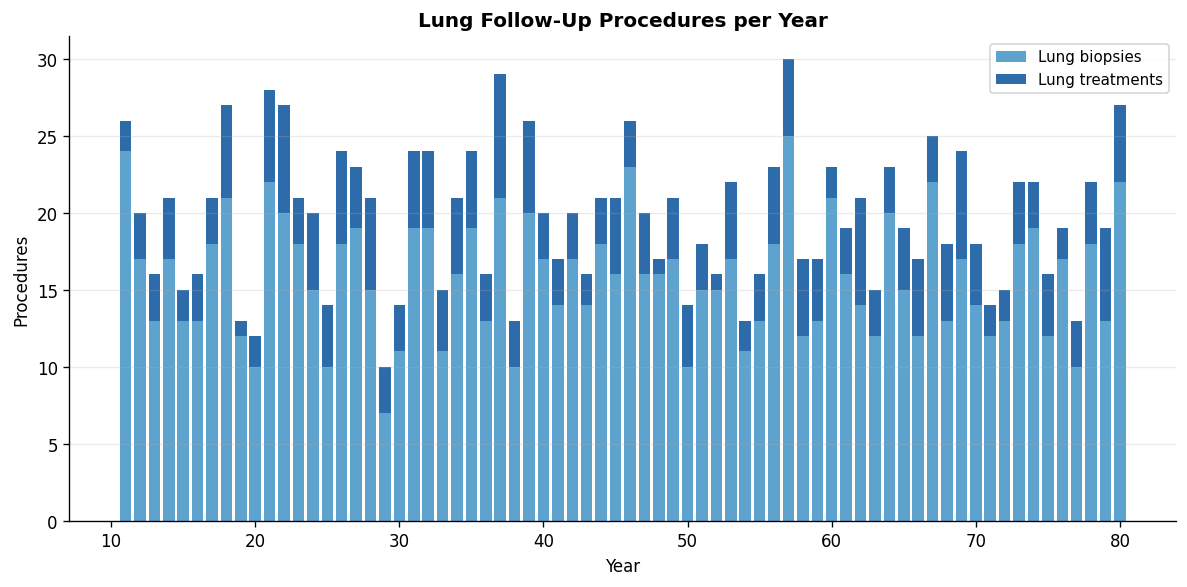

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]  # annual diffs have N-1 values

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_lbx = ann("cum_lung_biopsy")
ann_ltx = ann("cum_lung_treatment")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(years_ann, ann_lbx, color="#4292c6", alpha=0.85, label="Lung biopsies", width=0.8)
ax.bar(years_ann, ann_ltx, color="#08519c", alpha=0.85, label="Lung treatments", width=0.8, bottom=ann_lbx)
ax.set_title("Lung Follow-Up Procedures per Year", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("lung_followup"), dpi=150, bbox_inches="tight")
plt.show()


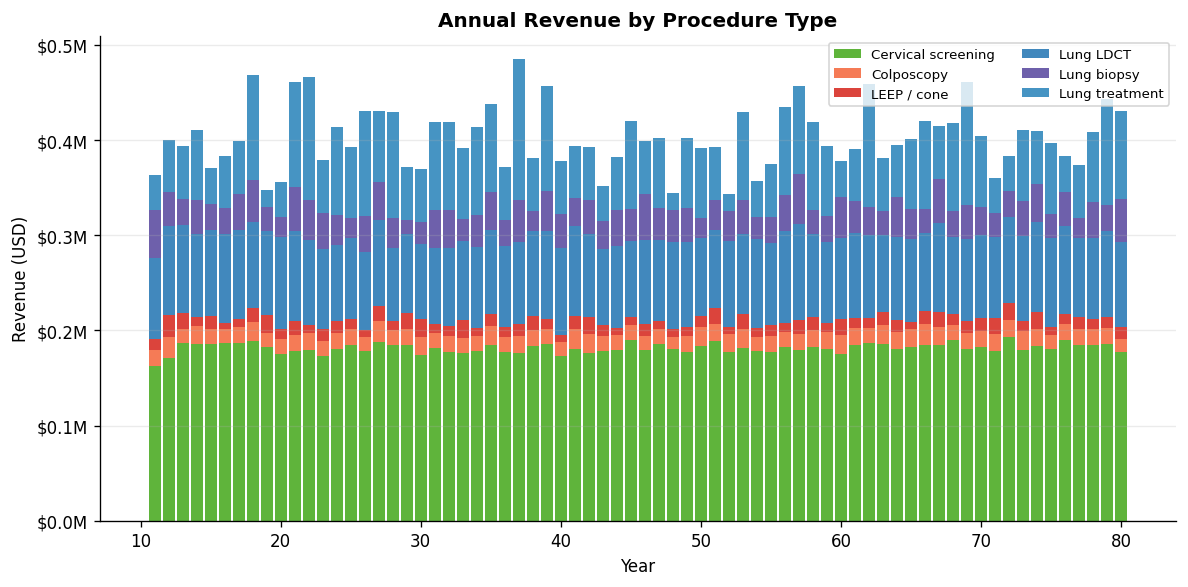

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]
years_ann = years[1:]  # annual diffs have N-1 values

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

rev_cfg = cfg.PROCEDURE_REVENUE
ann_cerv  = ann("cum_cervical"); ann_colp = ann("cum_colposcopy"); ann_leep = ann("cum_leep")
ann_lung  = ann("cum_lung"); ann_lbx = ann("cum_lung_biopsy"); ann_ltx = ann("cum_lung_treatment")

ann_cerv_r = [c * (0.6*rev_cfg["cytology"] + 0.4*rev_cfg["hpv_alone"]) for c in ann_cerv]
ann_colp_r = [c * rev_cfg["colposcopy"] for c in ann_colp]
ann_leep_r = [c * rev_cfg["leep"] for c in ann_leep]
ann_lung_r = [c * rev_cfg["ldct"] for c in ann_lung]
ann_lbx_r  = [c * rev_cfg["lung_biopsy"] for c in ann_lbx]
ann_ltx_r  = [c * rev_cfg["lung_treatment"] for c in ann_ltx]

bar_series = {"Cervical screening": (ann_cerv_r, "#4dac26"), "Colposcopy": (ann_colp_r, "#f46d43"),
              "LEEP / cone": (ann_leep_r, "#d73027"), "Lung LDCT": (ann_lung_r, "#2c7bb6"),
              "Lung biopsy": (ann_lbx_r, "#5e4fa2"), "Lung treatment": (ann_ltx_r, "#3288bd")}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
bottom = np.zeros(len(years_ann))
for label, (vals, col) in bar_series.items():
    ax.bar(years_ann, vals, bottom=bottom, color=col, label=label, width=0.85, alpha=0.9)
    bottom += np.array(vals)
ax.set_title("Annual Revenue by Procedure Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(viz_path("annual_revenue"), dpi=150, bbox_inches="tight")
plt.show()


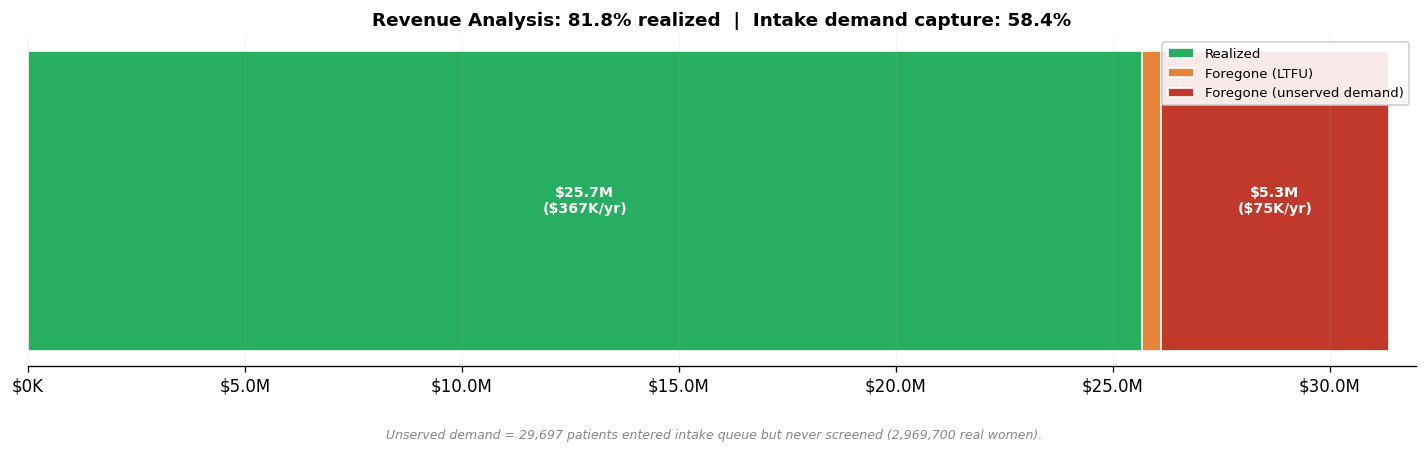

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import config as cfg
from metrics import compute_revenue

m = metrics_70yr
r = compute_revenue(m)

realized     = r["realized_total"]
foregone     = r["foregone_total"]
unserved     = r["unserved_total"]
total        = realized + foregone + unserved
n_years      = cfg.SIM_YEARS - cfg.WARMUP_YEARS
capture_rate = r["demand_capture_rate"]

fig, ax = plt.subplots(figsize=(12, 3.5))
fig.patch.set_facecolor("white")

# Three-segment stacked bar
ax.barh(0, realized, color="#27AE60", edgecolor="white", height=0.5, label="Realized")
ax.barh(0, foregone, left=realized, color="#E8833A", edgecolor="white", height=0.5, label="Foregone (LTFU)")
ax.barh(0, unserved, left=realized + foregone, color="#C0392B", edgecolor="white",
        height=0.5, label="Foregone (unserved demand)")

def fmt_rev(v):
    if v >= 1e6: return f"${v/1e6:.1f}M"
    elif v >= 1e3: return f"${v/1e3:.0f}K"
    return f"${v:.0f}"

segments = [
    (0, realized, "#FFFFFF", "Realized"),
    (realized, foregone, "#FFFFFF", "LTFU"),
    (realized + foregone, unserved, "#FFFFFF", "Unserved"),
]
for left, width, color, label in segments:
    if width > total * 0.05:
        ax.text(left + width / 2, 0,
                f"{fmt_rev(width)}\n({fmt_rev(width / max(n_years, 1))}/yr)",
                ha="center", va="center", fontsize=8.5, color=color, fontweight="bold")

ax.set_yticks([])
ax.set_xlim(0, max(total * 1.02, 1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))

realized_pct = 100 * realized / max(total, 1)
ax.set_title(f"Revenue Analysis: {realized_pct:.1f}% realized  |  "
             f"Intake demand capture: {capture_rate:.1%}",
             fontsize=11, fontweight="bold")

ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(axis="x", alpha=0.15)
ax.spines[["top", "right", "left"]].set_visible(False)

fig.text(0.5, -0.06,
         f"Unserved demand = {r['unserved_count_sim']:,.0f} patients entered intake queue but never screened "
         f"({r['unserved_count_real']:,.0f} real women).",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("revenue_capture"), dpi=150, bbox_inches="tight")
plt.show()

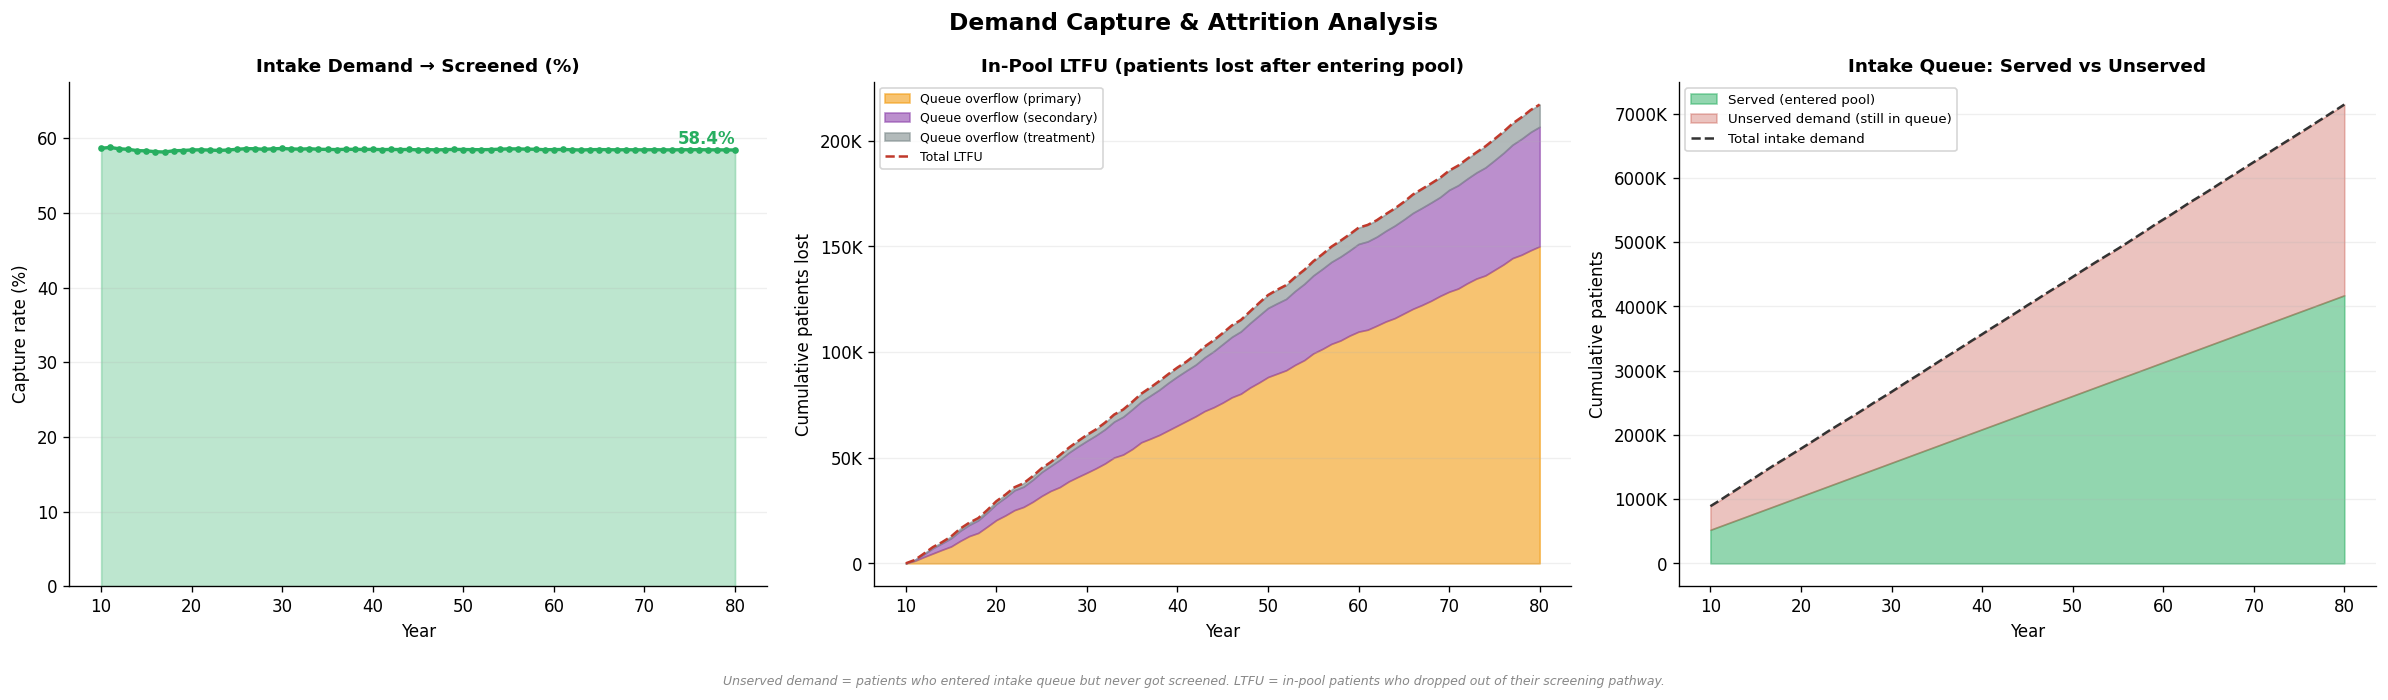

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
years = [c["year"] for c in chk]

cum_intake_total  = [c.get("cum_intake_total", 0) for c in chk]
cum_intake_served = [c.get("cum_intake_served", 0) for c in chk]
intake_unserved   = [t - s for t, s in zip(cum_intake_total, cum_intake_served)]
capture_rate      = [100 * s / max(t, 1) for s, t in zip(cum_intake_served, cum_intake_total)]

scale = cfg.POPULATION_SCALE_FACTOR
intake_total_real  = [v * scale for v in cum_intake_total]
intake_served_real = [v * scale for v in cum_intake_served]
unserved_real      = [v * scale for v in intake_unserved]

cum_ltfu = [c.get("cum_ltfu", 0) * scale for c in chk]
cum_ltfu_q1 = [c.get("cum_ltfu_queue_primary", 0) * scale for c in chk]
cum_ltfu_q2 = [c.get("cum_ltfu_queue_secondary", 0) * scale for c in chk]
cum_ltfu_qt = [c.get("cum_ltfu_queue_treatment", 0) * scale for c in chk]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5.5))
fig.patch.set_facecolor("white")
fig.suptitle("Demand Capture & Attrition Analysis", fontsize=14, fontweight="bold")

# Panel 1: Demand capture rate
ax1.fill_between(years, capture_rate, color="#27AE60", alpha=0.3)
ax1.plot(years, capture_rate, color="#27AE60", lw=2, marker="o", ms=3)
if capture_rate:
    ax1.text(years[-1], capture_rate[-1] + 0.3,
             f"{capture_rate[-1]:.1f}%",
             ha="right", va="bottom", fontsize=10, color="#27AE60", fontweight="bold")
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Capture rate (%)", fontsize=10)
ax1.set_title("Intake Demand → Screened (%)", fontsize=11, fontweight="bold")
y_max = max(max(capture_rate) * 1.15, 10) if capture_rate else 10
ax1.set_ylim(0, min(y_max, 105))
ax1.grid(axis="y", alpha=0.2)
ax1.spines[["top", "right"]].set_visible(False)

# Panel 2: Cumulative LTFU by type (in-pool only, no "declined screening")
ax2.fill_between(years, cum_ltfu_q1,
                 color="#F39C12", alpha=0.6, label="Queue overflow (primary)")
bottom1 = np.array(cum_ltfu_q1)
ax2.fill_between(years, bottom1, bottom1 + np.array(cum_ltfu_q2),
                 color="#8E44AD", alpha=0.6, label="Queue overflow (secondary)")
bottom2 = bottom1 + np.array(cum_ltfu_q2)
ax2.fill_between(years, bottom2, bottom2 + np.array(cum_ltfu_qt),
                 color="#7F8C8D", alpha=0.6, label="Queue overflow (treatment)")
ax2.plot(years, cum_ltfu, color="#C0392B", lw=1.5, ls="--", label="Total LTFU")

ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("Cumulative patients lost", fontsize=10)
ax2.set_title("In-Pool LTFU (patients lost after entering pool)", fontsize=11, fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax2.legend(fontsize=7.5, loc="upper left")
ax2.grid(axis="y", alpha=0.2)
ax2.spines[["top", "right"]].set_visible(False)

# Panel 3: Intake demand — served vs unserved
ax3.fill_between(years, intake_served_real, color="#27AE60", alpha=0.5, label="Served (entered pool)")
ax3.fill_between(years, intake_served_real, intake_total_real,
                 color="#C0392B", alpha=0.3, label="Unserved demand (still in queue)")
ax3.plot(years, intake_total_real, color="#333", lw=1.5, ls="--", label="Total intake demand")

ax3.set_xlabel("Year", fontsize=10)
ax3.set_ylabel("Cumulative patients", fontsize=10)
ax3.set_title("Intake Queue: Served vs Unserved", fontsize=11, fontweight="bold")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax3.legend(fontsize=8, loc="upper left")
ax3.grid(axis="y", alpha=0.2)
ax3.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.04,
         "Unserved demand = patients who entered intake queue but never got screened. "
         "LTFU = in-pool patients who dropped out of their screening pathway.",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("population_capture"), dpi=150, bbox_inches="tight")
plt.show()



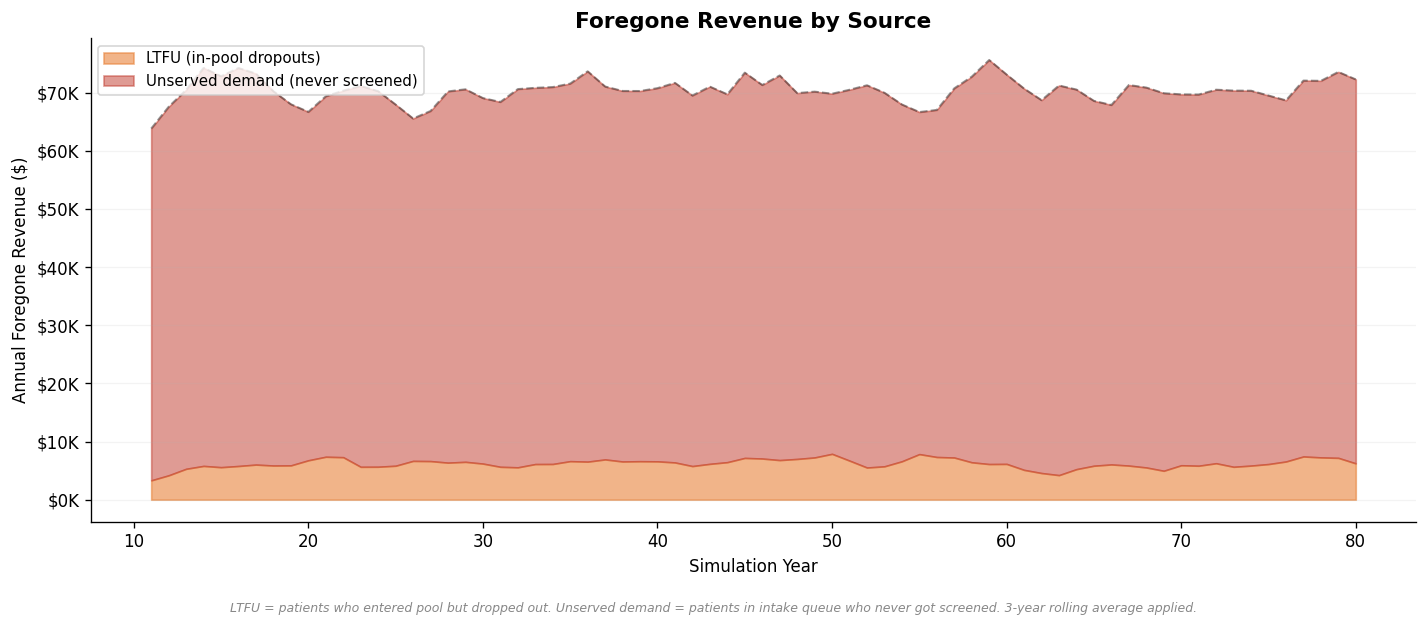

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg
from metrics import compute_revenue

m   = metrics_70yr
chk = post_warmup_checkpoints(m.get("year_checkpoints", []))
rev = cfg.PROCEDURE_REVENUE

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[i] - vals[i-1] for i in range(1, len(vals))]

years = [c["year"] for c in chk]
years_ann = years[1:]

avg_cerv_rev = 0.60 * rev["cytology"] + 0.40 * rev["hpv_alone"]

# -- Annual LTFU foregone (all in-pool sources combined) ----------------------
ann_unscreened  = ann("cum_ltfu_unscreened")
ann_q_primary   = ann("cum_ltfu_queue_primary")
ann_q_secondary = ann("cum_ltfu_queue_secondary")

fg_ltfu = np.array([
    u * avg_cerv_rev + qp * avg_cerv_rev + qs * rev["colposcopy"]
    for u, qp, qs in zip(ann_unscreened, ann_q_primary, ann_q_secondary)
], dtype=float)

# -- Annual unserved demand foregone ------------------------------------------
cum_intake_total  = [c.get("cum_intake_total", 0) for c in chk]
cum_intake_served = [c.get("cum_intake_served", 0) for c in chk]
ann_unserved = [max((cum_intake_total[i] - cum_intake_served[i]) -
                    (cum_intake_total[i-1] - cum_intake_served[i-1]), 0)
                for i in range(1, len(chk))]
fg_unserved = np.array([u * avg_cerv_rev for u in ann_unserved], dtype=float)

# -- Smooth with 3-year rolling average --------------------------------------
def smooth(series, window=3):
    arr = np.array(series, dtype=float)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    padded = np.concatenate([arr[:1] * np.ones(window - 1), arr])
    return np.convolve(padded, kernel, mode="valid")

fg_ltfu_s    = smooth(fg_ltfu)
fg_unserved_s = smooth(fg_unserved)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")

ax.fill_between(years_ann, fg_ltfu_s, color="#E8833A", alpha=0.6, label="LTFU (in-pool dropouts)")
ax.fill_between(years_ann, fg_ltfu_s, fg_ltfu_s + fg_unserved_s,
                color="#C0392B", alpha=0.5, label="Unserved demand (never screened)")
ax.plot(years_ann, fg_ltfu_s + fg_unserved_s, color="#333", lw=1.2, ls="--", alpha=0.5)

ax.set_title("Foregone Revenue by Source", fontsize=13, fontweight="bold")
ax.set_xlabel("Simulation Year", fontsize=10)
ax.set_ylabel("Annual Foregone Revenue ($)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.15)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.03,
         "LTFU = patients who entered pool but dropped out. "
         "Unserved demand = patients in intake queue who never got screened. "
         "3-year rolling average applied.",
         ha="center", fontsize=7.5, color="#888", fontstyle="italic")

plt.tight_layout()
plt.savefig(viz_path("foregone_revenue"), dpi=150, bbox_inches="tight")
plt.show()

---

## 1-Year Simulation

A single-year snapshot — useful for quickly checking how a parameter change affects screening throughput and outcomes before committing to a full 70-year run.

In [35]:

# ── Standalone run via SimulationRunner ───────────────────────────────────────
# This cell uses runner.py directly — no dependency on Sophia's SimPy notebook.
# SimulationRunner handles arrivals, queues, screening, and follow-up in one
# clean class. Switch use_stable_population=True for the {cfg.SIM_YEARS}-year cycling model.

import sys
sys.path.insert(0, '../src')

from runner import SimulationRunner
import config as cfg

print("Running 1-year simulation (SimulationRunner, standard mode)...")
sim = SimulationRunner(
    n_days     = 365,
    seed       = cfg.RANDOM_SEED,
    daily_rate = cfg.DAILY_PATIENTS,
    use_stable_population = False,   # standard mode: Poisson arrivals, no cycling
)
metrics = sim.run()

print(f"Done. Provider visits logged : {metrics['n_patients']:,}")
print(f"Eligible for any screening  : {metrics['n_eligible_any']:,}")
print(f"Cervical screened           : {metrics['n_screened']['cervical']:,}")
print(f"Lung screened               : {metrics['n_screened']['lung']:,}")
print()
sim.summary()


Running 1-year simulation (SimulationRunner, standard mode)...
Done. Provider visits logged : 0
Eligible for any screening  : 0
Cervical screened           : 0
Lung screened               : 0

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                             0
Eligible for ≥1 screening:                      0
Unscreened (declined / no-show):                0  (0.0%)
  ↳ agreed to reschedule:                       0  (0.0% of unscreened)

Screenings completed by cancer type:
  cervical                      0
  lung                          0

Colposcopies performed:                  0  (0.0% of abnormals)

Outcomes:
  Treated:                                    0  (0.0% of colposcopies)
  Lost to follow-up:                          0  (0.0% of all patients)

LTFU breakdown:
  Declined screening:                         0
  Queue — primary screening:                  0
  Queue — secondary (colpo/biopsy):           0
  Queue — treatment (LEEP/cone):       

---

## Step-by-Step Breakdown

Technical walkthrough of the daily simulation engine. Shows how the arrivals layer, screening logic, queue processor, and event loop connect. Intended for development and debugging — the full model runs from `SimulationRunner` without any of the code below.

## Load Sophia's Arrival Functions

`%run` executes Sophia's notebook in its entirety and imports all of her functions and global variables into this notebook's namespace. This is equivalent to copy-pasting her code here, but means we always use her latest version without duplication.

After `%run`, we override only the patient-generation step (`generate_daily_arrivals`) to use our enriched `Patient` class — everything else (queue management, scheduling, ER routing) is hers unchanged.

**Namespace note**: `%run` will also load Sophia's `print_summary` function, which prints her arrivals summary. We import our own `print_summary` as `print_screening_summary` before this cell runs, so both can coexist.

In [36]:
%run "../archive/initial_model_NYP_flow_simulation (1).ipynb"

# Confirm Sophia's key functions are loaded
print('Sophia functions loaded:', [f for f in dir() if f in (
    'initialize_state', 'generate_daily_arrivals', 'process_provider_queue',
    'process_er_queue', 'release_scheduled_patients_for_today',
    'release_returning_er_patients', 'is_weekday', 'next_weekday',
)])

zsh:1: command not found: pip


ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0

DAY 0
--------------------------------------------------
--- DAY 0 START ---
Patient 1 arrives as outpatient to pcp
Patient 2 arrives as outpatient to pcp
Patient 3 arrives as drop-in to specialist
Patient 4 arrives as drop-in to pc

## Extended Patient Generation

Sophia's `generate_daily_arrivals` creates a plain `Patient` with only the fields her queue model needs (id, type, destination). We replace it with `generate_enriched_daily_arrivals` which calls `population.sample_patient` instead.

`sample_patient` draws the full clinical profile for each patient — age, race, insurance, HPV status, smoking history, BMI, prior CIN, etc. — from NYC-calibrated demographic distributions. These fields are what the screening eligibility checks and result-draw functions read when they evaluate the patient downstream.

This is the only change we make to the arrivals layer. Once a patient is created, Sophia's queue routing functions handle them the same way they would handle a plain `Patient` object.

In [37]:
def generate_enriched_daily_arrivals(day: int, state: dict, next_patient_id: int) -> int:
    """
    Generate DAILY_PATIENTS enriched patients for one weekday.

    Replaces Sophia's generate_daily_arrivals with population.sample_patient so
    each patient carries demographics and clinical flags from the population model.
    Queue routing logic (drop-in vs. outpatient, ER vs. PCP/GYN) mirrors Sophia's original.

    Returns the updated next_patient_id counter.
    """
    for _ in range(cfg.DAILY_PATIENTS):
        # Draw type and destination using config probability tables
        patient_type = random.choices(
            list(cfg.PATIENT_TYPE_PROBS.keys()),
            weights=list(cfg.PATIENT_TYPE_PROBS.values())
        )[0]
        destination = random.choices(
            list(cfg.DESTINATION_PROBS.keys()),
            weights=list(cfg.DESTINATION_PROBS.values())
        )[0]

        # sample_patient creates a Patient with age, race, clinical flags, etc.
        # from the population distribution — this is the enrichment over Sophia's version
        patient = sample_patient(next_patient_id, day, destination, patient_type)
        next_patient_id += 1

        # ER patients get a critical flag — critical patients return the next day
        # for follow-up instead of being routed to an outpatient queue
        if destination == 'er':
            patient.critical_status = random.random() < cfg.ER_CRITICAL_PROB

        # Append to global patient list and increment arrival counters
        state['all_patients'].append(patient)
        state['patients_created'] += 1
        state['created_by_type'][patient_type] += 1
        state['created_by_destination'][destination] += 1

        # Route into today's queue: outpatients go through scheduling,
        # ER drop-ins go directly to the ER queue
        if patient_type == 'outpatient':
            add_patient_to_today_queue(patient, state)
        elif destination == 'er':
            state['er_today'].append(patient)
        else:
            add_patient_to_today_queue(patient, state)

    return next_patient_id

print('generate_enriched_daily_arrivals defined')

generate_enriched_daily_arrivals defined


## Post-Provider Screening Step

This is the **integration point** between Sophia's layer and ours. Every time a patient is seen by a provider (PCP, GYN, or Specialist), we immediately run Steps 2–5:

1. **Eligibility** — `get_eligible_screenings` checks age, cervix status, and smoking history against USPSTF criteria for each active cancer type.
2. **Screening** — `run_screening_step` assigns the test modality and draws a stochastic result. For lung, it also runs the pre-LDCT referral + scheduling pathway.
3. **Follow-up** — `run_cervical_followup` or `run_lung_followup` routes the result through the clinical decision tree (colposcopy, biopsy, treatment).

Patients who are ineligible for all active cancers are counted and skipped. Patients who exit the system mid-encounter (e.g. lost to follow-up during lung pre-LDCT) are not processed for additional cancers.

In [38]:
def run_post_provider_screening(patient: Patient, day: int, metrics: dict) -> None:
    """
    Execute screening steps for one patient who has just been seen by a provider.
    Updates the patient object in place and writes results to metrics.

    Flow:
      1. Get the list of cancer types this patient is eligible for right now.
      2. If none → patient is not eligible for any active screening today; just count and return.
      3. For each eligible cancer → run_screening_step (lung pre-LDCT pathway runs inside).
      4. For each non-None result → route to cancer-specific follow-up function.
    """
    metrics['n_patients'] += 1

    # get_eligible_screenings filters by ACTIVE_CANCERS and applies all eligibility rules
    eligible = get_eligible_screenings(patient)

    if not eligible:
        # Patient doesn't meet criteria for any active cancer screening today
        # (wrong age, no cervix, not enough pack-years, etc.) — nothing to do
        metrics['n_unscreened'] += 1
        return

    metrics['n_eligible_any'] += 1

    for cancer in eligible:
        # If the patient exited mid-encounter (e.g. lost to follow-up in lung pre-LDCT),
        # stop processing further cancers for this visit
        if not patient.active:
            break

        # run_screening_step checks interval, assigns test, draws result, writes to patient.
        # Returns None if skipped (not yet due) or patient was lost before scan.
        # Passes metrics so lung funnel counters (referral, scheduled, completed) are populated.
        result = run_screening_step(patient, cancer, day, metrics=metrics)
        if result is None:
            continue  # not due yet, or lost before scan — no follow-up needed

        # Write the (cancer, result) pair to the metrics screening table
        record_screening(metrics, patient, cancer, result)

        # Route to the cancer-specific follow-up chain.
        # cervical: route_cervical_result → run_colposcopy → run_treatment
        # lung:     communicate → biopsy referral → biopsy → treatment
        # Other cancers are excluded by ACTIVE_CANCERS in get_eligible_screenings.
        if cancer == 'cervical':
            run_cervical_followup(patient, day, metrics)
        elif cancer == 'lung':
            run_lung_followup(patient, day, metrics)

        # If the follow-up chain marked the patient as exited, record that exit reason
        if patient.exit_reason:
            record_exit(metrics, patient.exit_reason)

print('run_post_provider_screening defined')

run_post_provider_screening defined


## Extended Provider Queue Processor

Sophia's `process_provider_queue` drains the daily queue for one provider type, marks patients as seen up to the day's capacity, and reschedules the overflow. We wrap it here to inject the screening step for every seen patient.

The ER is handled separately by Sophia's `process_er_queue` — we do not screen in the ER in the current model (no cancer screening is appropriate in an emergency setting).

In [39]:
def process_provider_queue_with_screening(
    day: int, queue: deque, capacity: int,
    provider_name: str, state: dict, metrics: dict
) -> None:
    """
    Sophia's provider queue logic plus a screening step for every seen patient.

    Patients up to `capacity` are marked seen; the rest are rescheduled.
    For each seen patient, run_post_provider_screening immediately triggers
    Steps 2–5 (eligibility → test → result → follow-up).
    """
    seen = 0

    while queue:
        patient = queue.popleft()

        if seen < capacity:
            # Patient is seen today — increment counter and log the visit
            seen += 1
            state['seen_by_destination'][provider_name] += 1
            log_day(state, day, f'Patient {patient.patient_id} seen by {provider_name}')

            # ── Steps 2–5: screening + follow-up ────────────────────────────
            # Runs immediately after the provider visit, same day
            run_post_provider_screening(patient, day, metrics)

        else:
            # Provider is at capacity — patient must wait and come back
            patient.wait_days += 1
            state['not_seen_by_destination'][provider_name] += 1

            # Drop-ins are converted to outpatient appointments for the next weekday;
            # already-scheduled outpatients are simply pushed to the next weekday slot
            if patient.patient_type == 'drop_in':
                patient.patient_type  = 'outpatient'
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)
                state['converted_dropin_to_outpatient'] += 1
            else:
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)

print('process_provider_queue_with_screening defined')

process_provider_queue_with_screening defined


## Main Daily Process (SimPy Generator)

This is the **SimPy event loop**. SimPy is a discrete-event simulation framework — rather than running a real clock, it steps through simulation time one day at a time. The `daily_process_with_screening` generator is registered with SimPy and called once per simulated day.

On each weekday, the generator:
1. Releases outpatients whose scheduled appointment falls on this day.
2. Brings back critical ER patients from the day before.
3. Generates new patient arrivals (enriched with clinical flags).
4. Drains the PCP, GYN, and Specialist queues — screening runs for each seen patient.
5. Drains the ER queue via Sophia's original processor.
6. Advances the clock by 1 day (`yield env.timeout(1)`).

Weekends are skipped entirely to match NYP's operating schedule.

In [40]:
def daily_process_with_screening(env, state: dict, metrics: dict):
    """
    SimPy generator: drives one simulated weekday at a time until SIM_DAYS.

    Each iteration:
      1. Skip weekends — yield a 1-day timeout and continue.
      2. Release scheduled outpatients whose appointment is today.
      3. Release returning ER patients (critical patients from yesterday).
      4. Generate new enriched arrivals (replaces Sophia's plain arrivals).
      5. Process PCP, GYN, and Specialist queues with integrated screening.
      6. Process ER queue using Sophia's original ER logic (no screening in ER).
      7. Advance SimPy clock by 1 day.
    """
    import simpy
    next_patient_id = 1

    while env.now < cfg.SIM_DAYS:
        day = int(env.now)

        # Skip weekends — Sophia's is_weekday() returns False for Sat/Sun
        if not is_weekday(day):
            yield env.timeout(1)
            continue

        # Pull today's scheduled outpatients out of future_schedule into their queues
        release_scheduled_patients_for_today(day, state)
        # Move critical ER patients from yesterday back to the ER queue
        release_returning_er_patients(day, state)

        # Generate DAILY_PATIENTS enriched arrivals and route them into queues
        next_patient_id = generate_enriched_daily_arrivals(day, state, next_patient_id)

        # Process each non-ER provider queue (steps 2–5 run inside for each seen patient)
        process_provider_queue_with_screening(
            day, state['pcp_today'],        cfg.PROVIDER_CAPACITY['pcp'],
            'pcp',          state, metrics
        )
        process_provider_queue_with_screening(
            day, state['gyn_today'],        cfg.PROVIDER_CAPACITY['gynecologist'],
            'gynecologist', state, metrics
        )
        process_provider_queue_with_screening(
            day, state['specialist_today'], cfg.PROVIDER_CAPACITY['specialist'],
            'specialist',   state, metrics
        )

        # ER uses Sophia's original processor — no cancer screening in the ER for now
        process_er_queue(day, state)

        # Advance clock by one day
        yield env.timeout(1)

print('daily_process_with_screening defined')

daily_process_with_screening defined


## Run the Simulation

`run_simulation` is the single entry point for a full model run. It:
- Seeds the random number generator so runs are reproducible.
- Creates a fresh SimPy environment (the discrete-event clock).
- Initialises both state dicts (Sophia's arrivals state and our screening metrics).
- Registers `daily_process_with_screening` with SimPy and advances to `sim_days`.

The quick test below runs **1 year (365 days)** with a fixed seed. For variance analysis, call `run_simulation` in a loop with different seeds and aggregate across replications.

In [41]:
import simpy

def run_simulation(
    sim_days: int = cfg.SIM_DAYS,
    seed:     int = cfg.RANDOM_SEED,
):
    """
    Run the full end-to-end simulation.

    Sets the random seed, creates a SimPy environment, initialises Sophia's
    arrivals state dict and our screening metrics dict, then advances the
    SimPy clock until sim_days.

    Returns
    -------
    state   : Sophia's arrivals state dict (patients_created, seen_by_destination, etc.)
    metrics : Steps 2–6 metrics dict (screened, abnormal rates, LTFU counts, etc.)
    """
    random.seed(seed)   # fix seed so results are reproducible across runs

    env     = simpy.Environment()   # SimPy clock starts at 0 (= day 0)
    state   = initialize_state()    # Sophia's arrivals state (queues, counters, schedule)
    metrics = initialize_metrics()  # our screening/follow-up metrics (from metrics.py)

    # Register the daily process as a SimPy generator — it yields timeout(1) each day
    env.process(daily_process_with_screening(env, state, metrics))
    env.run(until=sim_days)         # runs all days synchronously (no real concurrency)

    return state, metrics

print('run_simulation defined')

run_simulation defined


## Arrivals Summary (Sophia's Layer)

The cell below prints Sophia's arrivals summary from the same simulation run. This covers everything that happened *before* the screening step: how many patients were created, how many were seen by each provider type, how many were rescheduled due to capacity, and ER overflow statistics.

Use this alongside the screening summary above to understand both layers of the simulation — access bottlenecks upstream can reduce the number of patients who ever reach a screening opportunity.

In [42]:

# Sophia's arrivals summary is only available when her notebook was loaded via
# %run (cells above).  In standalone SimulationRunner mode, print a compact
# substitute using the metrics dict that is always present.

if 'state' in dir() and state is not None:
    # Sophia's layer is loaded — print her summary
    print_summary(state)
else:
    print("(Sophia's arrivals layer not loaded — standalone SimulationRunner mode)")
    print(f"  Total provider visits : {metrics['n_patients']:,}")
    print(f"  Eligible any cancer   : {metrics['n_eligible_any']:,}")
    print(f"  Cervical screened     : {metrics['n_screened']['cervical']:,}")
    print(f"  Lung screened         : {metrics['n_screened']['lung']:,}")
    print(f"  Colposcopies          : {metrics['n_colposcopy']:,}")
    print(f"  Treated               : {metrics['n_treated']:,}")
    print(f"  LTFU                  : {metrics['n_ltfu']:,}")


ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0


## Patient Event Log Trace

This section prints the full event-by-event history for a sample of individual patients.

Reading a patient trace is the best way to verify the clinical logic is flowing correctly end-to-end. Each line shows the simulated day and the event that occurred: screening, result, routing decision, colposcopy/biopsy, treatment, exit reason, etc.

If something is wrong in the model (e.g. a patient goes to colposcopy without an abnormal result, or a follow-up step fires for an ineligible patient), it will be visible here before it propagates into aggregate statistics.

In [43]:

# ── Patient event-log traces ──────────────────────────────────────────────────
# Sample a few patients, run them through screening manually, and print their
# event-by-event history.  Works standalone — no dependency on Sophia's state.

import random
random.seed(None)

from population import sample_patient
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics

traced = []
pid = 0
while len(traced) < 5 and pid < 200:
    dest  = random.choice(['pcp', 'gynecologist', 'specialist'])
    p     = sample_patient(pid, day_created=0, destination=dest, patient_type='outpatient')
    m     = initialize_metrics()

    for cancer in ['cervical', 'lung']:
        result = run_screening_step(p, cancer, 0, m)

        if cancer == 'cervical' and p.cervical_result not in (None, 'NORMAL', 'HPV_NEGATIVE'):
            run_cervical_followup(p, 30, m)
            if not p.active:               # re-activate so the loop can continue
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

        if cancer == 'lung' and p.lung_result is not None:
            run_lung_followup(p, 1, m)
            if not p.active:
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

    if p.event_log:
        traced.append(p)
    pid += 1

print(f"Traced {len(traced)} patients with events:\n")
for p in traced:
    p.print_history()
    print()


Traced 5 patients with events:


── Patient 0 | age=30 | destination=pcp ──
  Day     0: SCREEN cervical via co_test
  Day     0: RESULT cervical: ASCUS
  Day    30: ROUTE ASCUS → colposcopy
  Day    30: COLPOSCOPY → NORMAL
  Day    30: TREATMENT — NORMAL: 1-year surveillance
  Day     0: SKIP lung — not eligible (age=30)


── Patient 1 | age=52 | destination=gynecologist ──
  Day     0: SCREEN cervical via co_test
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=52)


── Patient 2 | age=58 | destination=gynecologist ──
  Day     0: SCREEN cervical via co_test
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=58)


── Patient 3 | age=60 | destination=specialist ──
  Day     0: SCREEN cervical via hpv_alone
  Day     0: RESULT cervical: HPV_NEGATIVE
  Day     0: SKIP lung — not eligible (age=60)


── Patient 4 | age=55 | destination=specialist ──
  Day     0: SKIP cervical — not eligible (age=55)
  Day     0: SKIP lung — not e

In [44]:
# Close DB after all visualizations
sim_70yr.close_db()
print("Database connection closed.")

Database connection closed.